# THIS IS A DUPLICATED NOTEBOOK FROM THE MAIN HYBRID-MS-CNN.IPYNB

Created this duplicated notebook to show the impact of different class imbalance handling strategy
To demonstrate outputs from each class weighting strategy
this is an experimental notebook showing how ı decided to use fixed manual class weights. 


In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    REPO_DIR = '/content/Deep_Learning_Based_Classification_of_Cardiotograms_for_Predicting_Birth_Outcomes'

    if not os.path.exists(REPO_DIR):
        !git clone -b helper https://github.com/zeyneppguler23/Deep_Learning_Based_Classification_of_Cardiotograms_for_Predicting_Birth_Outcomes.git

    os.chdir(os.path.join(REPO_DIR, 'src', 'Transfer_Learning'))
    !pip install -q imbalanced-learn wfdb
    print(f"Working directory: {os.getcwd()}")
else:
    print("Not on Colab skipping setup.")

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled. prevents ResourceExhausted errors.")
else:
    print("WARNING: No GPU found.")

Cloning into 'Deep_Learning_Based_Classification_of_Cardiotograms_for_Predicting_Birth_Outcomes'...
remote: Enumerating objects: 3911, done.
remote: Counting objects: 100% (826/826), done.
remote: Compressing objects: 100% (641/641), done.
remote: Total 3911 (delta 258), reused 744 (delta 179), pack-reused 3085 (from 1)
Receiving objects: 100% (3911/3911), 226.85 MiB | 21.63 MiB/s, done.
Resolving deltas: 100% (1099/1099), done.
Updating files: 100% (3414/3414), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requi

## 1. Imports

In [1]:
# Disable oneDNN/MKL ops BEFORE importing TF
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Core
import numpy as np
import pandas as pd
from pathlib import Path
import wfdb
import json
import warnings
from typing import Dict, List, Tuple

# Signal processing
from scipy.interpolate import interp1d
from scipy.signal import welch

# Sklearn
from sklearn.metrics import (
    confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
 )
from sklearn.utils.class_weight import compute_class_weight

# Try to import StratifiedGroupKFold (sklearn >= 1.0)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available - will use group-aware stratified splitting.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False
    print("WARNING: StratifiedGroupKFold not available (sklearn < 1.0).")
    print("         Falling back to GroupKFold - class balance across folds not guaranteed.")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, Dropout, GlobalAveragePooling1D, Dense,
    Concatenate, Reshape, Multiply, Add,
 )
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
 )
from tensorflow.keras.utils import to_categorical

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")

StratifiedGroupKFold available - will use group-aware stratified splitting.
TensorFlow 2.16.1 | NumPy 1.26.4


c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 2. Configuration

All experiment parameters in one place. Change values here to toggle between
from-scratch training and transfer learning, adjust segmentation, etc.

In [ ]:
# PATHS

RAW_DATASET   = Path("../data/raw_dataset")
STEP2_LABELS  = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS  = Path("../ExpertAnnotations/step3_labels.csv")
OUTPUT_DIR    = Path("outputs/step23_softmax_short_plan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Signal Parameters
RAW_SAMPLING_RATE      = 4
TARGET_SAMPLING_RATE   = 1
DOWNSAMPLE_FACTOR      = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE
WINDOW_MINUTES  = 30
WINDOW_LENGTH   = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE
# Keep the existing key names from before.
SAMPLING_RATE   = TARGET_SAMPLING_RATE
SEGMENT_MINUTES = WINDOW_MINUTES
SEGMENT_LENGTH  = WINDOW_LENGTH

In [ ]:
#label definitions

NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

In [ ]:
#training/experiment configuration

CFG = dict(
    # Step-window experiment scope
    step_numbers            = [2, 3],
    mode_a_offsets          = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes         = SEGMENT_MINUTES,
    segment_length          = SEGMENT_LENGTH,
    max_nan_fraction        = 0.16,
    pad_short_records       = False,

    # Cross-validation
    n_splits                = 10,
    cv_seed                 = 42,
    min_severe_records      = 10,
    max_cv_attempts         = 100,

    # Model architecture
    temporal_filters        = 32,
    temporal_kernel         = 7,
    separable_filters       = 32,
    separable_kernels       = [3, 7, 15],
    projection_filters      = 32,
    dropout_rate            = 0.40,

    # Engineered-feature branch
    use_clinical_features   = True,

    # Augmentation pipeline
    augment_train           = True,
    aug_time_warp           = True,
    aug_warp_sigma          = 0.10,
    aug_amplitude_scale     = True,
    aug_amp_sigma           = 0.10,
    aug_noise               = True,
    aug_noise_std           = 0.02,
    aug_signal_loss         = True,
    aug_gap_frac            = 0.05,
    aug_n_gaps              = 2,

    # Scratch training
    scratch_epochs          = 100,
    scratch_lr              = 1e-3,
    scratch_batch           = 16,
    scratch_patience        = 20,
    label_smoothing         = 0.05,
    use_class_weights       = True,
)

windows_per_step = {step_num: len(offsets) for step_num, offsets in CFG['controlled_step_offsets'].items()}
if len(set(windows_per_step.values())) != 1:
    raise ValueError(f"All steps must use the same number of controlled windows, got: {windows_per_step}")

CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))


print("CONFIGURATION SUMMARY")

print(f"Windows used:Steps {CFG['step_numbers']}")
print(f"Sampling rate:{RAW_SAMPLING_RATE} Hz raw -> {SAMPLING_RATE} Hz model input")
print(f"Window length:{CFG['segment_minutes']} min = {CFG['segment_length']} samples @ {SAMPLING_RATE} Hz")
print(f"Canonical offsets:{CFG['mode_a_offsets']}")
print(f"Controlled windows:{CONTROLLED_WINDOWS_PER_STEP} per step")
for step_num in CFG['step_numbers']:
    print(f"Step {step_num}:{CFG['controlled_step_offsets'][step_num]}")
print(f"Max NaN frac:{CFG['max_nan_fraction']:.0%}")
print(f"CV folds: {CFG['n_splits']}")
print(f"Requested min Severe/fold: {CFG['min_severe_records']} step-units")
print(f"Label smoothing: {CFG['label_smoothing']:.2f}")
print(f"Softmax baseline: enabled")
print(f"Feature branch: 10 time-domain engineered FHR features")
print(f"Grouped CV: by rec_id (unchanged)")

CONFIGURATION SUMMARY
Windows used:Steps [2, 3]
Sampling rate:4 Hz raw -> 1 Hz model input
Window length:30 min = 1800 samples @ 1 Hz
Canonical offsets:{2: (60, 30), 3: (30, 0)}
Controlled windows:3 per step
Step 2:[(70, 40), (60, 30), (50, 20)]
Step 3:[(50, 20), (40, 10), (30, 0)]
Max NaN frac:16%
CV folds: 10
Requested min Severe/fold: 10 step-units
Label smoothing: 0.05
Softmax baseline: enabled
Feature branch: 10 time-domain engineered FHR features
Grouped CV: by rec_id (unchanged)


## 3. Step-Window Extraction (Steps 2 + 3 Only)



**Strategy:**

- Extract only the Step 2 and Step 3 30-minute delivery-anchored windows

- For each eligible record-step, create a fixed set of 3 controlled windows

- Keep grouping by `rec_id` unchanged so all windows from one record stay in the same fold

- Reject the entire record-step if any controlled window is too short or exceeds the missing-data threshold

- Track `rec_id` and window metadata so validation predictions are still aggregated at the **record level**


In [ ]:
#data loading and FHR cleaning section

def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:
    """Load Step 2 and Step 3 labels independently and filter uninterpretable rows."""
    step_labels = {}
    for step_num, path in step_paths.items():
        df = pd.read_csv(path)
        total = len(df)
        df = df[df['Majority_Vote_Label'] != -1].copy()
        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)
        df['rec_id'] = df['rec_id'].astype(str)
        excluded = total - len(df)
        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")
        for cls_id, name in enumerate(CLASS_NAMES):
            n = int((df['class_id'] == cls_id).sum())
            print(f"  Class {cls_id} ({name}): {n} ({n / max(len(df), 1) * 100:.1f}%)")
        step_labels[step_num] = df
    return step_labels

In [ ]:
def remove_trailing_zeros(signal) -> list:
    """Remove trailing zeros (marks end of recording / delivery)."""
    sig = list(signal) if isinstance(signal, np.ndarray) else list(signal)
    i = len(sig) - 1
    while i >= 0 and sig[i] == 0:
        i -= 1
    return sig[:i + 1]

In [ ]:
def clean_fhr(fhr_array, fs: int = 4) -> np.ndarray:
    """
    Clean a fetal heart rate signal using the existing pipeline.
    """
    fhr = pd.Series(np.array(fhr_array, dtype=float))
    # Replace 0 with NaN
    fhr.replace(0, np.nan, inplace=True)
    # Remove NaN gaps > 15 consecutive seconds
    na = fhr.isnull()
    gap_groups = na.ne(na.shift()).cumsum()
    gap_sizes = fhr.groupby(gap_groups.values).transform('size')
    fhr = fhr[~(gap_sizes.ge(fs * 15 + 1) & na)].reset_index(drop=True)
    # Outlier detection
    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan
    #Linear interpolation
    fhr = fhr.interpolate(method='linear')
    # Spike detection and removal
    diff = fhr - fhr.shift()
    fhr[(diff > 25) | (diff < -25)] = np.nan
    fhr = fhr.interpolate(method='linear')
    # Edge NaN fill
    fhr = fhr.ffill().bfill()
    return fhr.values

In [ ]:
def downsample_signal(signal: np.ndarray, factor: int = 4) -> np.ndarray:
    """Downsample a cleaned 1D signal by simple decimation."""
    if factor <= 1:
        return np.asarray(signal, dtype=np.float32)
    return np.asarray(signal[::factor], dtype=np.float32)

In [ ]:
def load_raw_signals(dataset_path: Path) -> Dict[str, dict]:
    """
    Load all CTU-UHB records, clean FHR at native 4 Hz, then downsample to 1 Hz.
    Returns: dict[rec_id] = {'FHR': np.ndarray, 'length': int}
    """
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files in {dataset_path}")

    data = {}

    for rid in sorted(records):
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            fhr_raw = remove_trailing_zeros(rec.p_signal[:, 0].tolist())
            fhr_clean = clean_fhr(fhr_raw, fs=RAW_SAMPLING_RATE)
            fhr_downsampled = downsample_signal(fhr_clean, factor=DOWNSAMPLE_FACTOR)
            data[rid] = {'FHR': fhr_downsampled, 'length': len(fhr_downsampled)}

        except Exception as e:
            print(f"  Skipping {rid}: {e}")

    print(f"\nLoaded {len(data)} FHR signals")
    lengths = [d['length'] for d in data.values()]
    print(f"  Duration range: {min(lengths)/(SAMPLING_RATE*60):.1f} – {max(lengths)/(SAMPLING_RATE*60):.1f} minutes")
    return data

In [ ]:
#Load data
STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}
step_label_dfs = load_step_labels(STEP_LABEL_PATHS)
signal_data = load_raw_signals(RAW_DATASET)

labelled_rec_ids = set()
for df in step_label_dfs.values():
    labelled_rec_ids.update(df['rec_id'].tolist())

valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))
print(f"\nRecords with at least one Step 2/3 label and a signal: {len(valid_rec_ids)}")

Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127 (37.7%)
  Class 1 (Mild): 153 (45.4%)
  Class 2 (Severe): 57 (16.9%)
Found 552 .hea files in ../data/raw_dataset

Loaded 552 FHR signals
  Duration range: 33.8 – 90.1 minutes

Records with at least one Step 2/3 label and a signal: 549


## 4. Step-Window Construction at 1 Hz

- downsample signals from 4hz to 1 hz
- Extract a fixed set of 3 controlled 30-minute windows per eligible step
- Step 2 uses earlier / canonical / later offsets around the canonical interval; Step 3 is delivery-bounded, so its three windows run from earlier coverage up to the canonical delivery window.
- If any of the 3 controlled windows for a record-step is too short or fails the missing-data threshold, that record-step is dropped entirely.
- The `group` array still tracks the parent `rec_id` for every window, so grouped CV remains leakage-free

In [ ]:
# step-window extraction section step 2 and 3

def _window_bounds_from_end(
    sig_len: int,
    offsets_from_end_min: Tuple[int, int],
    fs: int = 4,
):
    """Return sample bounds for one delivery-anchored window."""
    start_from_end_min, end_from_end_min = offsets_from_end_min

    if start_from_end_min <= end_from_end_min:
        raise ValueError(
            f"Expected start offset > end offset, got {offsets_from_end_min}"
        )

    start_from_end = start_from_end_min * 60 * fs
    end_from_end = end_from_end_min * 60 * fs

    if sig_len < start_from_end:
        return None

    start_idx = sig_len - start_from_end
    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len

    if end_idx <= start_idx:
        return None

    return int(start_idx), int(end_idx)


In [ ]:
def _get_controlled_window_bounds(
    sig_len: int,
    step_num: int,
    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],
    fs: int = 4,
):
    """Return all controlled window bounds for one record-step."""
    if step_num not in controlled_step_offsets:
        raise KeyError(f"Missing controlled offsets for step {step_num}")

    bounds = []
    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):
        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)
        if cur_bounds is None:
            return None

        start_idx, end_idx = cur_bounds
        bounds.append((window_index, offsets, start_idx, end_idx))

    return bounds

In [ ]:
def create_step_windows(
    signal_data: Dict[str, dict],
    step_label_dfs: Dict[int, pd.DataFrame],
    record_ids: List[str],
    window_length: int = 7200,
    step_numbers=None,
    step_offsets=None,
    controlled_step_offsets=None,
    max_nan_fraction: float = 0.16,
    pad_short_records: bool = False,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Extract controlled Step 2 and Step 3 30-minute windows from cleaned CTU-UHB FHR signals.
    """
    if step_numbers is None:
        step_numbers = [2, 3]

    if step_offsets is None:
        step_offsets = {2: (60, 30), 3: (30, 0)}

    if controlled_step_offsets is None:
        controlled_step_offsets = {
            step_num: [step_offsets[step_num]]
            for step_num in step_numbers
        }

    windows_per_step = {
        step_num: len(controlled_step_offsets[step_num])
        for step_num in step_numbers
    }
    if len(set(windows_per_step.values())) != 1:
        raise ValueError(
            f"All steps must use the same number of controlled windows, got: {windows_per_step}"
        )

    fixed_windows_per_step = next(iter(windows_per_step.values()))

    X_list = []
    y_list = []
    group_list = []
    meta_list = []

    accepted_record_steps = 0
    skipped_step_short = 0
    skipped_step_nan = 0

    for rid in record_ids:
        if rid not in signal_data:
            continue

        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)
        sig_len = len(fhr)

        for step_num in step_numbers:
            step_df = step_label_dfs.get(step_num)
            if step_df is None:
                continue

            row = step_df[step_df['rec_id'] == rid]
            if row.empty:
                continue

            controlled_bounds = _get_controlled_window_bounds(
                sig_len,
                step_num,
                controlled_step_offsets,
                fs=fs,
            )
            if controlled_bounds is None:
                skipped_step_short += 1
                continue

            label = int(row['class_id'].iloc[0])
            step_windows = []
            step_failed_short = False
            step_failed_nan = False

            for window_index, offsets, start_idx, end_idx in controlled_bounds:
                window = fhr[start_idx:end_idx]

                if len(window) < window_length:
                    if pad_short_records:
                        pad_len = window_length - len(window)
                        window = np.pad(window, (pad_len, 0), mode='edge')
                    else:
                        step_failed_short = True
                        break

                missing_frac_prefill = float(np.mean(np.isnan(window) | (window == 0)))
                if missing_frac_prefill > max_nan_fraction:
                    step_failed_nan = True
                    break

                if np.any(np.isnan(window)):
                    s = pd.Series(window)
                    window = s.interpolate(method='linear').ffill().bfill().values

                step_windows.append(
                    {
                        'window': window.astype(np.float32),
                        'window_index': window_index,
                        'offset_start_min': int(offsets[0]),
                        'offset_end_min': int(offsets[1]),
                        'window_start': start_idx,
                        'window_end': end_idx,
                        'missing_frac_prefill': missing_frac_prefill,
                    }
                )

            if step_failed_short:
                skipped_step_short += 1
                continue

            if step_failed_nan:
                skipped_step_nan += 1
                continue

            if len(step_windows) != fixed_windows_per_step:
                raise RuntimeError(
                    f"Expected {fixed_windows_per_step} windows for {rid} step {step_num}, "
                    f"got {len(step_windows)}"
                )

            accepted_record_steps += 1
            for step_window in step_windows:
                X_list.append(step_window['window'])
                y_list.append(label)
                group_list.append(rid)
                meta_list.append(
                    {
                        'rec_id': rid,
                        'step': step_num,
                        'window_index': step_window['window_index'],
                        'offset_start_min': step_window['offset_start_min'],
                        'offset_end_min': step_window['offset_end_min'],
                        'window_start': step_window['window_start'],
                        'window_end': step_window['window_end'],
                        'label': label,
                        'missing_frac_prefill': step_window['missing_frac_prefill'],
                    }
                )

    if X_list:
        X_windows = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]
    else:
        X_windows = np.empty((0, window_length, 1), dtype=np.float32)

    y_windows = np.array(y_list, dtype=np.int32)
    groups = np.array(group_list)
    metadata = pd.DataFrame(meta_list)

    print("\nStep-window extraction complete:")
    print(f"Total windows: {len(X_windows)} from {len(set(group_list))} records")
    print(f"Window shape:{X_windows.shape}")
    print(f"Controlled windows/step:{fixed_windows_per_step}")
    print(f"Accepted record-steps:{accepted_record_steps}")
    print(f"Skipped record-steps (short): {skipped_step_short}")
    print(f"Skipped record-steps (NaN):{skipped_step_nan}")

    if len(metadata) > 0:
        for step_num in step_numbers:
            step_mask = metadata['step'] == step_num
            n_step_windows = int(step_mask.sum())
            n_step_records = int(metadata.loc[step_mask, 'rec_id'].nunique())
            print(f"  Step {step_num}:               {n_step_windows} windows from {n_step_records} records")

        for cls_id, name in enumerate(CLASS_NAMES):
            n_class = int(np.sum(y_windows == cls_id))
            print(f"  Class {cls_id} ({name}):      {n_class} windows")

    return X_windows, y_windows, groups, metadata


# Create Step 2 + Step 3 windows from all valid records
print("Creating Step 2 + Step 3 controlled 30-minute windows...")

X_all, y_all, groups_all, meta_all = create_step_windows(
    signal_data=signal_data,
    step_label_dfs=step_label_dfs,
    record_ids=valid_rec_ids,
    window_length=CFG['segment_length'],
    step_numbers=CFG['step_numbers'],
    step_offsets=CFG['mode_a_offsets'],
    controlled_step_offsets=CFG['controlled_step_offsets'],
    max_nan_fraction=CFG['max_nan_fraction'],
    pad_short_records=CFG['pad_short_records'],
    fs=SAMPLING_RATE,
)

windows_per_record = pd.Series(groups_all).value_counts()
if len(windows_per_record) > 0:
    print(
        f"\nWindows per record: min={windows_per_record.min()}, max={windows_per_record.max()}, mean={windows_per_record.mean():.1f}"
    )
    print("Step counts:")
    print(meta_all['step'].value_counts().sort_index())
    print("Window index counts:")
    print(meta_all['window_index'].value_counts().sort_index())

Creating Step 2 + Step 3 controlled 30-minute windows...

Step-window extraction complete:
Total windows: 1398 from 336 records
Window shape:(1398, 1800, 1)
Controlled windows/step:3
Accepted record-steps:466
Skipped record-steps (short): 419
Skipped record-steps (NaN):0
  Step 2:               399 windows from 133 records
  Step 3:               999 windows from 333 records
  Class 0 (Normal):      564 windows
  Class 1 (Mild):      636 windows
  Class 2 (Severe):      198 windows

Windows per record: min=3, max=6, mean=4.2
Step counts:
step
2    399
3    999
Name: count, dtype: int64
Window index counts:
window_index
0    466
1    466
2    466
Name: count, dtype: int64


## 6. Normalisation, Augmentation & Engineered Features



**Normalisation:** Z-score statistics are computed from the training fold only.



**Time-Series Augmentations** remain unchanged and are applied to training windows only.



**Compact engineered features** are extracted from the cleaned 30-minute FHR window:

1. mean

2. median

3. std

4. IQR

5. mean absolute successive difference

6. std of 1-minute means

7. number of accelerations

8. number of decelerations

9. max deceleration depth

10. fraction of missing/invalid samples before final fill


In [ ]:
#leakage safe normalisation, augmentation, engineered features

def compute_norm_stats(X_train: np.ndarray) -> dict:
    """Compute mean and std from training windows only."""
    vals = X_train.ravel()
    mean = float(np.mean(vals))
    std = float(np.std(vals))
    if std < 1e-8:
        std = 1.0
    return {'mean': mean, 'std': std}

In [ ]:
def apply_norm(X: np.ndarray, stats: dict) -> np.ndarray:
    """Apply pre-computed z-score normalization."""
    X_norm = X.astype(np.float32)
    X_norm -= stats['mean']
    X_norm /= stats['std']
    return X_norm

In [ ]:
#time series augmentations, applied to training data only
def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    """Time warping: stretch/compress the time axis by smooth random amounts."""
    N, T, C = X.shape
    X_warped = np.empty_like(X)
    orig_steps = np.arange(T)
    n_knots = 4
    knot_pos = np.linspace(0, T - 1, n_knots + 2)

    for i in range(N):
        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)
        warp_factors[0] = 1.0
        warp_factors[-1] = 1.0
        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])
        warped_knots = np.concatenate([[0], warped_knots])
        warped_knots = warped_knots / warped_knots[-1] * (T - 1)
        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')
        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)

        for c in range(C):
            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')
            X_warped[i, :, c] = interp_sig(warped_steps)

    return X_warped.astype(np.float32)

In [ ]:
def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    """Random per-sample amplitude scaling."""
    N = X.shape[0]
    scales = np.random.normal(1.0, sigma, size=(N, 1, 1)).astype(np.float32)
    return X * scales

In [ ]:
def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:
    """Add mild Gaussian noise."""
    noise = np.random.normal(0, noise_std, X.shape).astype(np.float32)
    return X + noise

In [ ]:
def signal_loss_simulation(X: np.ndarray,max_gap_frac: float = 0.05,n_gaps: int = 2,) -> np.ndarray:
    """Simulate random signal dropout with interpolation across short gaps."""
    N, T, C = X.shape
    X_aug = X.copy()
    max_gap = max(1, int(T * max_gap_frac))

    for i in range(N):
        for _ in range(n_gaps):
            gap_len = np.random.randint(1, max_gap + 1)
            start = np.random.randint(0, T - gap_len)
            end = start + gap_len
            for c in range(C):
                left_val = X_aug[i, max(start - 1, 0), c]
                right_val = X_aug[i, min(end, T - 1), c]
                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)

    return X_aug.astype(np.float32)

In [ ]:
def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:
    """Apply the unchanged augmentation pipeline to training data only."""
    X_aug = X.copy()
    if cfg.get('aug_time_warp', True):
        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))
    if cfg.get('aug_amplitude_scale', True):
        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))
    if cfg.get('aug_noise', True):
        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))
    if cfg.get('aug_signal_loss', True):
        X_aug = signal_loss_simulation(
            X_aug,
            max_gap_frac=cfg.get('aug_gap_frac', 0.05),
            n_gaps=cfg.get('aug_n_gaps', 2),)

    return X_aug

In [ ]:
# Engineered feature extraction

def compute_clinical_features(X: np.ndarray,fs: int = 4,missing_frac_prefill=None,) -> np.ndarray:
    """
    Extract a compact engineered feature vector from each cleaned FHR window.

    Features:
      1. mean
      2. median
      3. std
      4. IQR
      5. mean absolute successive difference
      6. std of 1-minute means
      7. number of accelerations
      8. number of decelerations
      9. max deceleration depth
     10. fraction of missing/invalid samples before final fill
    """

    N, T, _ = X.shape
    features = np.zeros((N, 10), dtype=np.float32)
    min_dur_samples = 15 * fs
    one_min_samples = 60 * fs

    if missing_frac_prefill is None:
        missing_frac_prefill = np.zeros(N, dtype=np.float32)
    else:
        missing_frac_prefill = np.asarray(missing_frac_prefill, dtype=np.float32)
    for i in range(N):
        sig = np.asarray(X[i, :, 0], dtype=np.float64)
        baseline = float(np.median(sig))
        deviation = sig - baseline
        features[i, 0] = float(np.mean(sig))
        features[i, 1] = float(np.median(sig))
        features[i, 2] = float(np.std(sig))
        q25, q75 = np.percentile(sig, [25, 75])
        features[i, 3] = float(q75 - q25)
        features[i, 4] = float(np.mean(np.abs(np.diff(sig)))) if len(sig) > 1 else 0.0
        n_minutes = T // one_min_samples
        if n_minutes >= 2:
            minute_means = [
                np.mean(sig[j * one_min_samples:(j + 1) * one_min_samples])
                for j in range(n_minutes)
            ]
            features[i, 5] = float(np.std(minute_means))
        else:
            features[i, 5] = features[i, 2]
        accel_mask = deviation >= 15
        decel_mask = deviation <= -15
        accel_count, _ = _count_episodes(deviation, accel_mask, min_dur_samples)
        decel_count, _ = _count_episodes(-deviation, decel_mask, min_dur_samples)
        features[i, 6] = float(accel_count)
        features[i, 7] = float(decel_count)
        features[i, 8] = float(np.max(np.maximum(-deviation, 0.0)))
        features[i, 9] = float(missing_frac_prefill[i])
    return features

In [ ]:
def _count_episodes(deviation: np.ndarray,mask: np.ndarray,min_dur: int,) -> tuple:
    """Count episodes where mask is True for at least min_dur consecutive samples."""
    count = 0
    total_area = 0.0
    in_episode = False
    episode_start = 0

    for j in range(len(mask)):
        if mask[j] and not in_episode:
            in_episode = True
            episode_start = j
        elif not mask[j] and in_episode:
            in_episode = False
            dur = j - episode_start
            if dur >= min_dur:
                count += 1
                total_area += float(np.sum(np.abs(deviation[episode_start:j])))
    if in_episode:
        dur = len(mask) - episode_start
        if dur >= min_dur:
            count += 1
            total_area += float(np.sum(np.abs(deviation[episode_start:])))
    return count, total_area

In [ ]:
# ── Unified feature computation ──────────────────────────────────

def compute_all_engineered_features(
    X: np.ndarray,
    fs: int = 1,
    missing_frac_prefill=None,
) -> np.ndarray:
    """Compute the 10 time-domain engineered features for each FHR window."""
    return compute_clinical_features(X, fs=fs, missing_frac_prefill=missing_frac_prefill)


print("compute_all_engineered_features() defined – 10 time-domain features")

compute_all_engineered_features() defined – 10 time-domain features


In [ ]:
# 10 time-domain engineered feature names
ALL_FEATURE_NAMES = [
    'mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd',
    'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill',
]

CLINICAL_FEATURE_NAMES = ALL_FEATURE_NAMES
N_CLINICAL_FEATURES = len(ALL_FEATURE_NAMES)

print(f"{N_CLINICAL_FEATURES} engineered features: {ALL_FEATURE_NAMES}")

10 engineered features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']


In [ ]:
def normalize_clinical_features(feats_train: np.ndarray,feats_apply: np.ndarray,) -> tuple:
    """Z-score normalize engineered features using TRAIN statistics only."""
    mean = feats_train.mean(axis=0)
    std = feats_train.std(axis=0)
    std[std < 1e-8] = 1.0
    return (feats_apply - mean) / std, {'mean': mean, 'std': std}

In [ ]:
print("Normalization, augmentation & engineered-feature utilities defined:")
print(f"All features ({N_CLINICAL_FEATURES}): {ALL_FEATURE_NAMES}")
print("augment_signal() remains unchanged and is applied to training windows only")

# Quick smoke test: compute features on first 5 windows
if 'X_all' in globals() and len(X_all) >= 5:
    _test_X = X_all[:5]
    _test_mfp = meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32)[:5]
    _feats = compute_all_engineered_features(_test_X, fs=SAMPLING_RATE, missing_frac_prefill=_test_mfp)
    print(f"  Smoke test: shape={_feats.shape}, features={ALL_FEATURE_NAMES}")
    del _test_X, _test_mfp, _feats
    print("Smoke test passed.")

Normalization, augmentation & engineered-feature utilities defined:
All features (10): ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
augment_signal() remains unchanged and is applied to training windows only
  Smoke test: shape=(5, 10), features=['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
Smoke test passed.


## 6. Model Architecture

1D CNN with multi-scale separable convolutions, squeeze-excitation attention,
and a residual block. Uses `GlobalAveragePooling1D` so the model stays length-agnostic.

**Final layer:** `Dense(3, activation='softmax')` for the 3-class step-level classification task.


In [ ]:
# model architecture
def _se_block_1d(x, ratio: int = 4, name: str = "se"):
    """
    Squeeze-and-Excitation (SE) attention block for 1D signals.
    Learns per-channel importance weights via global average pooling.
    Input:  (batch, time_steps, channels)
    Output: (batch, time_steps, channels) - same shape, re-weighted
    """
    filters = int(x.shape[-1])
    se = GlobalAveragePooling1D(name=f"{name}_gap")(x)
    se = Dense(max(filters // ratio, 4), activation='elu', name=f"{name}_fc1")(se)
    se = Dense(filters, activation='sigmoid', name=f"{name}_fc2")(se)
    se = Reshape((1, filters), name=f"{name}_reshape")(se)
    return Multiply(name=f"{name}_scale")([x, se])

In [ ]:
def build_model(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = 3,
    temporal_filters: int = 32,
    temporal_kernel: int = 7,
    separable_filters: int = 32,
    separable_kernels: List[int] = [3, 7, 15],
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
    n_clinical_features: int = 0,
    residual_dilation_rates: List[int] = [2, 4],
) -> Model:
    """
    Build a 1D CNN for univariate FHR window classification.
    Optionally accepts engineered features as a second input.
    """
    inputs = Input(shape=(input_length, 1), name="fhr_input")

    x = Conv1D(temporal_filters, temporal_kernel, padding="same", use_bias=False, name="temporal_conv")(inputs)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("elu", name="temporal_elu")(x)

    x = AveragePooling1D(pool_size=4, name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    if len(separable_kernels) > 1:
        branches = []
        for i, kernel_size in enumerate(separable_kernels):
            branch = SeparableConv1D(
                separable_filters,
                kernel_size,
                padding="same",
                use_bias=False,
                name=f"ms_sep_{i}",
            )(x)
            branch = BatchNormalization(name=f"ms_bn_{i}")(branch)
            branch = Activation("elu", name=f"ms_elu_{i}")(branch)
            branches.append(branch)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv1D(
            separable_filters,
            separable_kernels[0],
            padding="same",
            use_bias=False,
            name="ms_sep_0",
        )(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("elu", name="ms_elu_0")(x)

    x = Conv1D(projection_filters, 1, use_bias=False, name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("elu", name="proj1_elu")(x)
    x = _se_block_1d(x, ratio=4, name="se1")

    x = AveragePooling1D(pool_size=4, name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    residual = x
    dilation_rates = list(residual_dilation_rates or [1, 1])
    if len(dilation_rates) < 2:
        dilation_rates = dilation_rates + [dilation_rates[-1]]

    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[0],
        use_bias=False,
        name="res_sep1",
    )(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("elu", name="res_elu1")(x)
    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[1],
        use_bias=False,
        name="res_sep2",
    )(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("elu", name="res_elu2")(x)
    x = _se_block_1d(x, ratio=4, name="se2")

    x = AveragePooling1D(pool_size=2, name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)
    x = GlobalAveragePooling1D(name="global_pool")(x)

    if n_clinical_features > 0:
        clinical_input = Input(shape=(n_clinical_features,), name="clinical_input")
        clin = Dense(16, activation="elu", name="clinical_fc")(clinical_input)
        clin = Dropout(0.2, name="clinical_drop")(clin)
        x = Concatenate(name="merge_clin")([x, clin])
        x = Dense(32, activation="elu", name="fusion_fc")(x)
        x = Dropout(dropout_rate, name="fusion_drop")(x)
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        return Model([inputs, clinical_input], outputs, name="FHR-SegNet-ClinFeat")

    outputs = Dense(num_classes, activation="softmax", name="output")(x)
    return Model(inputs, outputs, name="FHR-SegNet")


model_test = build_model(
    input_length=CFG['segment_length'],
    num_classes=NUM_CLASSES,
    temporal_filters=CFG['temporal_filters'],
    temporal_kernel=CFG['temporal_kernel'],
    separable_filters=CFG['separable_filters'],
    separable_kernels=CFG['separable_kernels'],
    projection_filters=CFG['projection_filters'],
    dropout_rate=CFG['dropout_rate'],
    n_clinical_features=N_CLINICAL_FEATURES,
)
model_test.summary()
print(f"\nTotal parameters: {model_test.count_params():,}")
del model_test

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_elu        │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_elu[0][… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_0            │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_1            │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_2            │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_elu_0[0][0],   │
│ (Concatenate)       │                   │            │ ms_elu_1[0][0],   │
│                     │                   │            │ ms_elu_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,507 (52.76 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,507


## 7. Training Functions

- Early stopping monitors record-step balanced accuracy, which matches the evaluation unit.
- Validation aggregation uses the actual `rec_id + step` metadata rather than assuming windows are contiguous.
- Grouped cross-validation still splits by `rec_id` only, so there is no leakage across folds.
- The severe-case reliability threshold is resolved consistently for both split generation and fold reporting.

In [ ]:
#training functions
def _make_model_input(X, clin_feats=None):
    """Build model input: [X, clin_feats] if clinical features are present, else X."""
    if clin_feats is not None:
        return [X, clin_feats]
    return X

In [ ]:
def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    """Ensure each window row carries a stable record-step key."""
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        if 'rec_id' not in meta.columns or 'step' not in meta.columns:
            raise KeyError("metadata must contain 'rec_id' and 'step' columns")
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta

In [ ]:
def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    """Build one labeled row per record-step for grouped splitting and evaluation."""
    meta = _ensure_step_keys(metadata)
    if 'label' not in meta.columns:
        raise KeyError("metadata must contain a 'label' column")

    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one record-step label")

    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)

In [ ]:
def resolve_min_severe_threshold(
    metadata: pd.DataFrame,
    n_splits: int,
    requested_min: int = 10,
    severe_class: int = 2,
) -> Tuple[int, int, int]:
    """Resolve a feasible per-fold Severe step-unit threshold for the current dataset."""
    step_targets = build_step_target_table(metadata.reset_index(drop=True))
    step_y = step_targets['label'].to_numpy(dtype=int)
    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0

    effective_min = requested_min
    if effective_min > min_possible:
        if total_severe == 0:
            effective_min = 0
        else:
            effective_min = max(min_possible - 1, 1)
        print(
            f"  WARNING: Requested >= {requested_min} Severe step-units/fold is infeasible; "
            f"using {effective_min} instead."
        )

    return effective_min, total_severe, min_possible

In [ ]:
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    """Compute class weights from TRAINING labels only."""
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight = {int(label): float(weight) for label, weight in zip(classes, weights)}
    print(f"  Class weights (from train fold): {class_weight}")
    return class_weight

In [ ]:
class RecordStepBalancedAccuracy(Callback):
    """Compute record-step balanced accuracy at each epoch end for scratch training."""
    def __init__(
        self,
        X_val: np.ndarray,
        val_metadata: pd.DataFrame,
        clin_val=None,
        batch_size: int = 32,
    ):
        super().__init__()
        self.X_val = X_val
        self.val_metadata = _ensure_step_keys(val_metadata.reset_index(drop=True))
        self.clin_val = clin_val
        self.batch_size = batch_size

    def _aggregate_record_step_targets(self, y_proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if len(y_proba) != len(self.val_metadata):
            raise ValueError("Validation probabilities and metadata must have the same length")

        step_y_true = []
        step_y_pred = []
        for step_key in self.val_metadata['step_key'].unique():
            mask = self.val_metadata['step_key'] == step_key
            mean_proba = y_proba[mask].mean(axis=0)
            step_y_true.append(int(self.val_metadata.loc[mask, 'label'].iloc[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))

        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        del epoch
        logs = logs or {}
        val_input = _make_model_input(self.X_val, self.clin_val)
        y_proba = self.model.predict(val_input, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate_record_step_targets(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")

In [ ]:
def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    monitor_mode: str = 'min',
    save_path=None,
    prefix_callbacks=None,
    save_weights_only: bool = False,
) -> list:
    callbacks = list(prefix_callbacks or [])
    callbacks.extend([
        EarlyStopping(
            monitor=monitor,
            mode=monitor_mode,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=monitor_mode,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ])
    if save_path is not None:
        callbacks.append(
            ModelCheckpoint(
                save_path,
                monitor=monitor,
                mode=monitor_mode,
                save_best_only=True,
                save_weights_only=save_weights_only,
                verbose=0,
            )
        )
    return callbacks

In [ ]:
def oversample_minority_records(
    train_idx: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    severe_class: int = 2,
) -> np.ndarray:
    """Duplicate windows from Severe-class records to reduce training imbalance."""
    del groups
    y_train = y[train_idx]
    class_counts = {class_id: int(np.sum(y_train == class_id)) for class_id in range(NUM_CLASSES)}
    max_count = max(class_counts.values())
    severe_count = class_counts.get(severe_class, 0)

    if severe_count == 0 or severe_count >= max_count:
        return train_idx

    n_copies = max(1, round(max_count / severe_count) - 1)
    severe_indices = train_idx[y_train == severe_class]
    extra_indices = np.tile(severe_indices, n_copies)
    new_train_idx = np.concatenate([train_idx, extra_indices])

    print(
        f"  Severe oversampling: {severe_count} -> {severe_count + len(extra_indices)} windows "
        f"({n_copies}x duplication)"
    )
    return new_train_idx

In [ ]:
def calibrate_predictions(
    y_proba: np.ndarray,
    severe_class: int = 2,
    severe_boost: float = 0.0,
) -> np.ndarray:
    """Apply an additive boost to the Severe class before argmax."""
    if severe_boost <= 0:
        return y_proba
    adjusted = y_proba.copy()
    adjusted[:, severe_class] += severe_boost
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted

In [ ]:
def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    val_metadata: pd.DataFrame,
    cfg: dict,
    save_path=None,
    clin_train=None,
    clin_val=None,
) -> tf.keras.callbacks.History:
    """Train the model from scratch using record-step balanced accuracy for early stopping."""
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    label_smoothing = float(cfg.get('label_smoothing', 0.0))
    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    monitor_callback = RecordStepBalancedAccuracy(
        X_val=X_val,
        val_metadata=val_metadata,
        clin_val=clin_val,
        batch_size=32,
    )
    print("  Early stopping monitor: val_record_step_balanced_accuracy")
    print(f"  Label smoothing: {label_smoothing:.2f}")

    history = model.fit(
        _make_model_input(X_train_use, clin_train),
        y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            save_path=save_path,
            prefix_callbacks=[monitor_callback],
            save_weights_only=True,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history

In [ ]:
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 5,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], int]:
    """Generate grouped CV folds using one labeled row per record-step while preserving record grouping."""
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)

    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    effective_min, total_severe, min_possible = resolve_min_severe_threshold(
        meta,
        n_splits=n_splits,
        requested_min=min_severe_records,
        severe_class=severe_class,
    )
    print(f"  Total Severe step-units: {total_severe}, {n_splits} folds -> max ~{min_possible}/fold")

    best_folds = None
    best_min_severe = -1
    best_counts = None

    n_attempts = max_attempts if HAS_STRATIFIED_GROUP_KFOLD else 1
    for attempt in range(n_attempts):
        seed = cv_seed + attempt

        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids = set(step_targets.iloc[val_step_idx]['rec_id'])

            n_severe = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_severe)

            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))

            if n_severe < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds
            best_counts = list(fold_severe_counts)

        if all_ok:
            method = "StratifiedGroupKFold" if HAS_STRATIFIED_GROUP_KFOLD else "GroupKFold"
            print(f"  Found valid split at attempt {attempt + 1} (seed={seed}, {method})")
            print(f"    Severe step-units per val fold: {fold_severe_counts}")
            return candidate_folds, effective_min

    print(f"  Could not meet >={effective_min} Severe step-units/fold after {n_attempts} attempts.")
    print(f"    Best found: min={best_min_severe}, per-fold={best_counts}")
    return best_folds, effective_min

In [ ]:
def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    """Assess validation-fold quality at the record-step label level."""
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)

    step_counts = {
        class_id: int(np.sum(step_targets['label'].to_numpy(dtype=int) == class_id))
        for class_id in range(NUM_CLASSES)
    }
    window_counts = {
        class_id: int(np.sum(val_meta['label'].to_numpy(dtype=int) == class_id))
        for class_id in range(NUM_CLASSES)
    }
    n_severe = step_counts.get(severe_class, 0)

    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_severe,
        n_severe_windows=window_counts.get(severe_class, 0),
        is_reliable=(n_severe >= min_severe_records),
        min_severe_threshold=min_severe_records,
    )
    return stats['is_reliable'], stats


print("Training functions defined:")
print("train_from_scratch scratch training with record-step BA early stopping")
print("_make_model_input builds [X, clin] or X")
print("build_step_target_table one labeled row per record-step")
print("resolve_min_severe_threshold feasible Severe threshold per fold")
print("oversample_minority_records optional Severe-window oversampling")
print("calibrate_predictions optional post-hoc Severe boost")
print("stratified_record_kfold grouped CV using record-step labels")
print("analyze_validation_set fold quality assessment at record-step level")

Training functions defined:
train_from_scratch scratch training with record-step BA early stopping
_make_model_input builds [X, clin] or X
build_step_target_table one labeled row per record-step
resolve_min_severe_threshold feasible Severe threshold per fold
oversample_minority_records optional Severe-window oversampling
calibrate_predictions optional post-hoc Severe boost
stratified_record_kfold grouped CV using record-step labels
analyze_validation_set fold quality assessment at record-step level


## 8. Evaluation & Metrics

**Key principle:** Evaluate at the **record-step level**, not by forcing one label per full record.

During inference:
1. Predict window-level probabilities
2. Group windows by parent **record-step** (`rec_id` + step number)
3. Average probabilities across all windows from the same record-step
4. Take argmax of averaged probabilities for the record-step prediction

This keeps supervision aligned with the actual labeled signal segment. A record may legitimately contribute a **Severe Step 2** example and a **Mild Step 3** example without creating a contradictory single record label.

In [ ]:
# Evaluation: record-step metrics via mean probability aggregation

def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Aggregate window-level predictions to record-step level via mean probabilities.
    For each unique record-step:
    - Average the softmax probabilities across all its windows
    - Take argmax of the averaged probabilities as the record-step prediction
    - Use the step label attached to that record-step as the true label
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true = []
    step_y_pred = []

    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))

    return (
        unique_step_keys,
        np.array(step_y_true, dtype=int),
        np.array(step_y_pred, dtype=int),
    )

In [ ]:
def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
) -> dict:
    """
    Compute comprehensive classification metrics.

    Returns dict with:
    - accuracy, balanced_accuracy, macro_f1
    - per-class precision, recall, f1
    - confusion matrix
    """
    labels = list(range(len(class_names)))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=labels, zero_division=0)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    metrics = {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
    }

    for i, name in enumerate(class_names):
        metrics[f'precision_{name}'] = precision[i]
        metrics[f'recall_{name}'] = recall[i]
        metrics[f'f1_{name}'] = f1[i]
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0

    return metrics

In [ ]:
def print_metrics(metrics: dict, prefix: str = "") -> None:
    """Pretty-print aggregated record-step metrics."""
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    print(f"  " + "-" * 45)
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")

print("Evaluation functions defined:")
print("aggregate_to_record_step_level - mean probability aggregation within each record-step")
print("compute_metrics - accuracy, balanced acc, macro F1, per-class")
print("print_metrics - formatted display")


Evaluation functions defined:
aggregate_to_record_step_level - mean probability aggregation within each record-step
compute_metrics - accuracy, balanced acc, macro F1, per-class
print_metrics - formatted display


## 10. Plotting Utilities

In [ ]:
# plotting utilities

def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
    title: str = "Confusion Matrix",
    save_path=None,
) -> None:
    """Plot a confusion matrix heatmap."""
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_fold_summary(
    fold_results: List[dict],
    save_path=None,
) -> None:
    """Bar chart of per-fold macro F1 with mean ± std."""
    f1s = [result['macro_f1'] for result in fold_results]
    folds = list(range(1, len(f1s) + 1))

    _, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(
        np.mean(f1s),
        color='red',
        linestyle='--',
        label=f"Mean = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
    )
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_title('Per-Fold Record-Level Macro F1', fontsize=14)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.3f}', ha='center', fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Plotting utilities defined (confusion matrix, fold summary)")

Plotting utilities defined (confusion matrix, fold summary)


## 10. Cross-Validation Pipeline

**10-fold group-based splitting** - all windows from one record stay together, so there is still no leakage across folds.

1. Training labels remain attached to the **step window** they came from.
2. Fold splitting is still grouped by **`rec_id`**.
3. Evaluation aggregates multiple windows only within the same **record-step**, not across the whole record.

**improvements for mild/severe discrimination:**
1. **Clinical features:** 10 compact features extracted from cleaned FHR, normalized per-fold using train statistics only.
2. **Full augmentation pipeline:** Time warping, amplitude scaling, noise, signal loss.

**After training each fold:**
1. Predict window probabilities on validation set
2. Apply threshold calibration
3. Aggregate to record-step level via mean probabilities
4. Compute record-step metrics

In [ ]:
# group based and leakage safe cross validation
def run_grouped_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    X_raw=None,
    feature_missing_frac=None,
) -> List[dict]:
    """
    Run leakage-safe grouped cross-validation with grouped splitting by rec_id.
    Labels remain step-specific. Multiple windows are aggregated only within the same record-step for evaluation, not across the whole record.
    """
    if len(X) != len(y) or len(X) != len(groups) or len(X) != len(metadata):
        raise ValueError("X, y, groups, and metadata must all have the same length")

    metadata = _ensure_step_keys(metadata.reset_index(drop=True))

    n_splits = cfg['n_splits']
    use_clinical = cfg.get('use_clinical_features', True)
    severe_boost = cfg.get('severe_boost', 0.0)
    do_oversample = cfg.get('oversample_severe', False)
    requested_min_severe = cfg.get('min_severe_records', 10)

    X_for_features = X_raw if X_raw is not None else X
    if use_clinical:
        print("Computing 10 time-domain engineered features from cleaned FHR windows")
        clin_all = compute_all_engineered_features(
            X_for_features,
            fs=SAMPLING_RATE,
            missing_frac_prefill=feature_missing_frac,
        )
        print(f"Engineered feature matrix: {clin_all.shape} - {N_CLINICAL_FEATURES} features")
        print(f"Active features: {ALL_FEATURE_NAMES}")
    else:
        clin_all = None

    folds, effective_min_severe = stratified_record_kfold_with_constraint(
        metadata,
        n_splits=n_splits,
        min_severe_records=requested_min_severe,
        max_attempts=cfg.get('max_cv_attempts', 100),
        cv_seed=cfg['cv_seed'],
    )
    if effective_min_severe != requested_min_severe:
        print(f"Effective reliability threshold: {effective_min_severe} Severe step-units/fold")

    fold_results = []
    all_step_y_true = []
    all_step_y_pred = []
    reliable_step_y_true = []
    reliable_step_y_pred = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx + 1} / {n_splits}")
        print(f"{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata,
            val_idx,
            min_severe_records=effective_min_severe,
        )

        tag = "RELIABLE" if is_reliable else "UNRELIABLE"
        print(f"  Validation quality: {tag}")
        step_counts = val_stats['step_units_per_class']
        window_counts = val_stats['windows_per_class']
        for class_id, class_name in enumerate(CLASS_NAMES):
            print(f"    {class_name}: {step_counts[class_id]} step-units, {window_counts[class_id]} windows")
        print(
            f"  Severe step-units in val: {val_stats['n_severe_step_units']} "
            f"(threshold: {effective_min_severe})"
        )

        if do_oversample:
            train_idx = oversample_minority_records(train_idx, y, groups, severe_class=2)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        train_recs = set(g_train)
        val_recs = set(g_val)
        overlap = train_recs & val_recs
        assert len(overlap) == 0, f"DATA LEAKAGE! {len(overlap)} records in both sets: {overlap}"

        n_train_recs = len(train_recs)
        n_val_recs = len(val_recs)
        print(f"  Train: {len(X_train)} windows from {n_train_recs} records")
        print(f"  Val:   {len(X_val)} windows from {n_val_recs} records / {val_stats['n_val_step_units']} record-steps")
        for class_id, class_name in enumerate(CLASS_NAMES):
            n_train_class = int(np.sum(y_train == class_id))
            n_val_class = int(np.sum(y_val == class_id))
            print(f"    {class_name}: train={n_train_class}, val={n_val_class}")

        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n = None
            clin_val_n = None

        tf.keras.backend.clear_session()
        n_clinical = clin_all.shape[1] if clin_all is not None else 0
        model = build_model(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            temporal_filters=cfg['temporal_filters'],
            temporal_kernel=cfg['temporal_kernel'],
            separable_filters=cfg['separable_filters'],
            separable_kernels=cfg['separable_kernels'],
            projection_filters=cfg['projection_filters'],
            dropout_rate=cfg['dropout_rate'],
            n_clinical_features=n_clinical,
        )

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_best.weights.h5")
        _ = train_from_scratch(
            model,
            X_train_n,
            y_train,
            X_val_n,
            y_val,
            meta_val,
            cfg,
            save_path=save_path,
            clin_train=clin_train_n,
            clin_val=clin_val_n,
        )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)

        if severe_boost > 0:
            y_proba_val = calibrate_predictions(y_proba_val, severe_class=2, severe_boost=severe_boost)
            print(f"  Applied severe threshold boost: +{severe_boost}")

        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['n_train_records'] = n_train_recs
        metrics['n_val_records'] = n_val_recs
        metrics['n_val_step_units'] = val_stats['n_val_step_units']
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        metrics['requested_min_severe_threshold'] = requested_min_severe
        metrics['effective_min_severe_threshold'] = effective_min_severe
        fold_results.append(metrics)

        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        if is_reliable:
            reliable_step_y_true.extend(step_y_true)
            reliable_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")
        if not is_reliable:
            print(
                f"  ** This fold has only {val_stats['n_severe_step_units']} Severe step-units "
                f"(< {effective_min_severe}) - flagged UNRELIABLE"
            )

        plot_confusion_matrix(
            metrics['confusion_matrix'],
            title=(f"Fold {fold_idx + 1} - Record-Step CM" + (" [UNRELIABLE]" if not is_reliable else "")),
            save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_cm.png"),
        )

    n_reliable = sum(1 for result in fold_results if result['is_reliable'])
    reliable_results = [result for result in fold_results if result['is_reliable']]

    print(f"\n{'=' * 60}")
    print(f"CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features")
    print(
        f"  Reliable folds: {n_reliable} / {n_splits} "
        f"(effective threshold: {effective_min_severe} Severe step-units)"
    )
    print(f"{'=' * 60}")

    print(f"\n  -- All {n_splits} folds --")
    summary_keys = ['accuracy', 'balanced_accuracy', 'macro_f1']
    for key in summary_keys:
        values = [result[key] for result in fold_results]
        print(f"  {key:22s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

    print("  " + "-" * 50)
    for class_name in CLASS_NAMES:
        for metric_name in ['precision', 'recall', 'f1']:
            values = [result[f'{metric_name}_{class_name}'] for result in fold_results]
            print(f"  {metric_name}_{class_name:8s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\nOverall Confusion Matrix (all folds combined):")
    print(overall_cm)

    if 0 < n_reliable < n_splits:
        print(f"\n  -- Reliable folds only ({n_reliable}/{n_splits}) --")
        for key in summary_keys:
            values = [result[key] for result in reliable_results]
            print(f"  {key:22s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")
        print("  " + "-" * 50)
        for class_name in CLASS_NAMES:
            for metric_name in ['precision', 'recall', 'f1']:
                values = [result[f'{metric_name}_{class_name}'] for result in reliable_results]
                print(f"  {metric_name}_{class_name:8s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")
        reliable_cm = confusion_matrix(reliable_step_y_true, reliable_step_y_pred, labels=list(range(NUM_CLASSES)))
        print(f"\n  Reliable-fold Confusion Matrix:")
        print(reliable_cm)
    elif n_reliable == n_splits:
        print("\n  All folds are reliable - no filtering needed.")

    plot_confusion_matrix(
        overall_cm,
        title="Overall Record-Step CM (All Folds)",
        save_path=str(OUTPUT_DIR / "overall_cm.png"),
    )
    plot_fold_summary(
        fold_results,
        save_path=str(OUTPUT_DIR / "fold_summary.png"),
    )
    return fold_results


print("Cross-validation pipeline defined (run_grouped_cv)")
print("Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics")
print("Uses 10 time-domain engineered features")

Cross-validation pipeline defined (run_grouped_cv)
Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics
Uses 10 time-domain engineered features


## 12. Class Imbalance Experiment 
This section systematically compares different class-weighting and resampling strategies while keeping **everything else** (data, labelling, model architecture, CV splits, augmentation) identical. Each experiment only changes the class-imbalance handling method.

In [ ]:
# ── Shared experiment infrastructure ──────────────────────────────────────────
# Save the original function so we can restore it after each experiment
_original_compute_class_weights_from_y = compute_class_weights_from_y

# Pre-compute step table and feature arrays (reused across all experiments)
step_unit_table = build_step_target_table(meta_all)
_feat_missing = meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32)

print(f"Dataset: {len(X_all)} windows from {len(step_unit_table)} record-steps "
      f"across {len(np.unique(groups_all))} records")
print(f"Window shape: {X_all.shape}")
print(f"Classes: {dict(zip(CLASS_NAMES, [int(np.sum(y_all == i)) for i in range(NUM_CLASSES)]))}")

# Collector for all experiment summaries
all_experiment_results = {}

Dataset: 1398 windows from 466 record-steps across 336 records
Window shape: (1398, 1800, 1)
Classes: {'Normal': 564, 'Mild': 636, 'Severe': 198}


In [ ]:
def run_experiment(experiment_name, manual_weights=None, cfg_overrides=None,
                   post_restore_fn=None):
    """
    Run one class-imbalance experiment.
    - manual_weights: dict {0: w0, 1: w1, 2: w2} or None for sklearn balanced.
    - cfg_overrides: dict of CFG keys to temporarily override.
    - post_restore_fn: callable to clean up after the experiment.
    """
    global compute_class_weights_from_y

    cfg_local = dict(CFG)
    if cfg_overrides:
        cfg_local.update(cfg_overrides)

    def _manual_resolver_factory(weights):
        def _resolver(y_train):
            if weights is None:
                return _original_compute_class_weights_from_y(y_train)
            resolved = {int(c): float(weights.get(c, 1.0)) for c in range(NUM_CLASSES)}
            print(f"  Class weights (manual override): {resolved}")
            return resolved
        return _resolver

    try:
        print(f"\n{'=' * 70}")
        print(f"EXPERIMENT: {experiment_name}")
        if manual_weights:
            print(f"Manual class weights: {manual_weights}")
        print(f"{'=' * 70}")

        compute_class_weights_from_y = _manual_resolver_factory(manual_weights)

        results = run_grouped_cv(
            X=X_all, y=y_all, groups=groups_all,
            metadata=meta_all, cfg=cfg_local,
            X_raw=X_all, feature_missing_frac=_feat_missing,
        )
    finally:
        compute_class_weights_from_y = _original_compute_class_weights_from_y
        if post_restore_fn:
            post_restore_fn()

    summary = {
        'experiment': experiment_name,
        'manual_class_weights': manual_weights,
        'mean_macro_f1': float(np.mean([r['macro_f1'] for r in results])),
        'std_macro_f1': float(np.std([r['macro_f1'] for r in results])),
        'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in results])),
        'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in results])),
        'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in results])),
        'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in results])),
        'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in results])),
        'per_fold': [{k: v for k, v in r.items() if k != 'confusion_matrix'} for r in results],
    }

    all_experiment_results[experiment_name] = summary
    print(f"\n>> {experiment_name} — Macro F1: {summary['mean_macro_f1']:.4f} ± {summary['std_macro_f1']:.4f}, "
          f"Bal Acc: {summary['mean_balanced_acc']:.4f}")
    return results, summary

print("run_experiment() helper defined.")

run_experiment() helper defined.


### Experiment 1: Manual Weights (0.9, 1.1, 2.3)
Conservative Normal down-weighting with moderate Mild and strong Severe emphasis.


EXPERIMENT: Manual (0.9, 1.1, 2.3)
Manual class weights: {0: 0.9, 1: 1.1, 2: 2.3}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

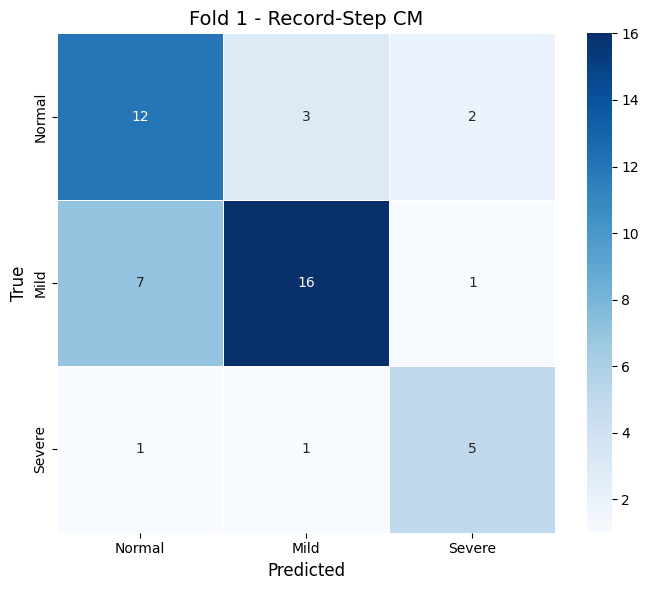


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4013 - loss: 1.3647  val_record_step_balanced_accuracy: 0.5059
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.4388 - loss: 1.3257 - val_accuracy: 0.5321 - val_loss: 1.0199 - val_record_step_balanced_accuracy: 0.5059 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4633 - loss: 1.2513  val_record_step_balanced_accuracy: 0.4583
78/78 ━

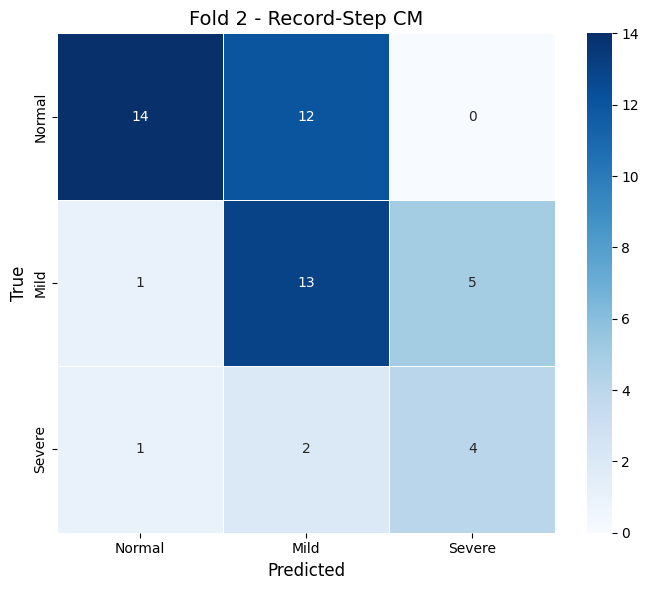


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3985 - loss: 1.4029  val_record_step_balanced_accuracy: 0.4724
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.4395 - loss: 1.3371 - val_accuracy: 0.4841 - val_loss: 1.0902 - val_record_step_balanced_accuracy: 0.4724 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4787 - loss: 1.3008  val_record_step_balanced_accuracy: 0.4532
80/80 ━━

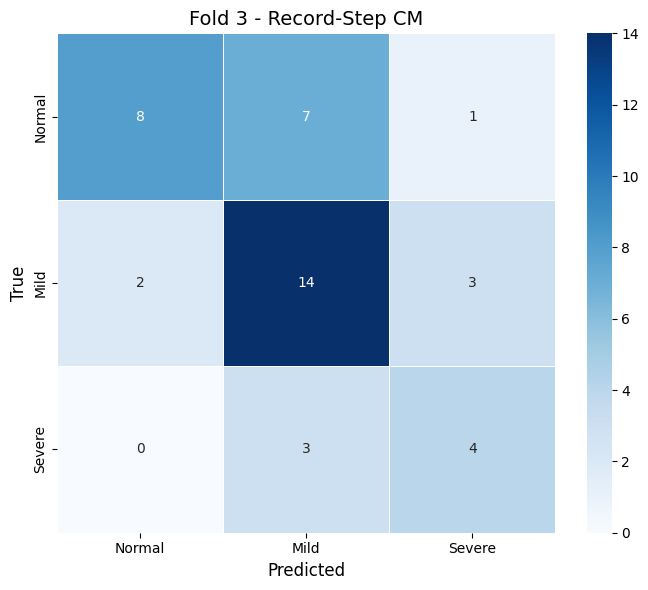


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4362 - loss: 1.3155  val_record_step_balanced_accuracy: 0.4449
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.4513 - loss: 1.3214 - val_accuracy: 0.3704 - val_loss: 1.0407 - val_record_step_balanced_accuracy: 0.4449 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4881 - loss: 1.2192  val_record_step_balanced_accuracy: 0.5790
79/79 ━

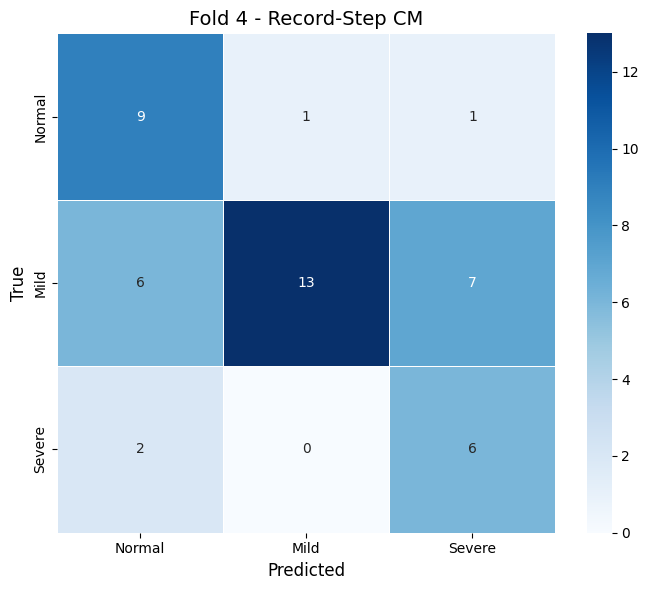


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3801 - loss: 1.4049  val_record_step_balanced_accuracy: 0.6077
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.4151 - loss: 1.3519 - val_accuracy: 0.4762 - val_loss: 1.0058 - val_record_step_balanced_accuracy: 0.6077 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4590 - loss: 1.3115  val_record_step_balanced_accuracy: 0.6236
80/80 ━━

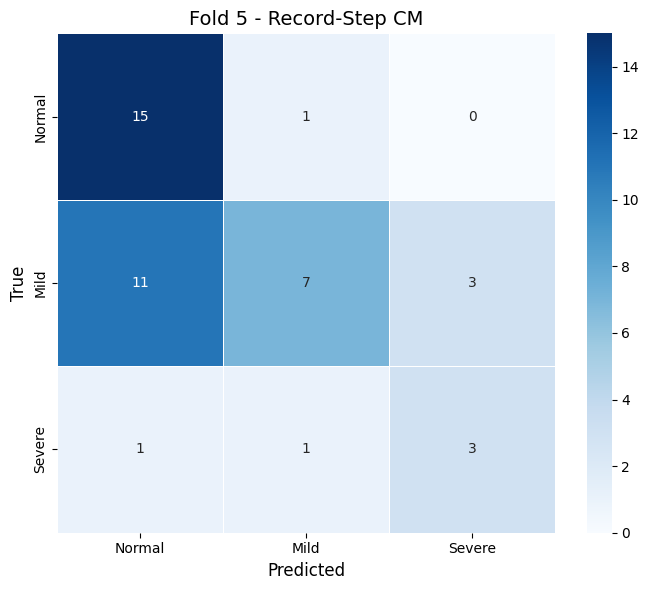


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3489 - loss: 1.4497  val_record_step_balanced_accuracy: 0.3361
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.3758 - loss: 1.3872 - val_accuracy: 0.3933 - val_loss: 1.0415 - val_record_step_balanced_accuracy: 0.3361 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4570 - loss: 1.2880  val_record_step_balanced_accuracy: 0.3556
78/78 ━

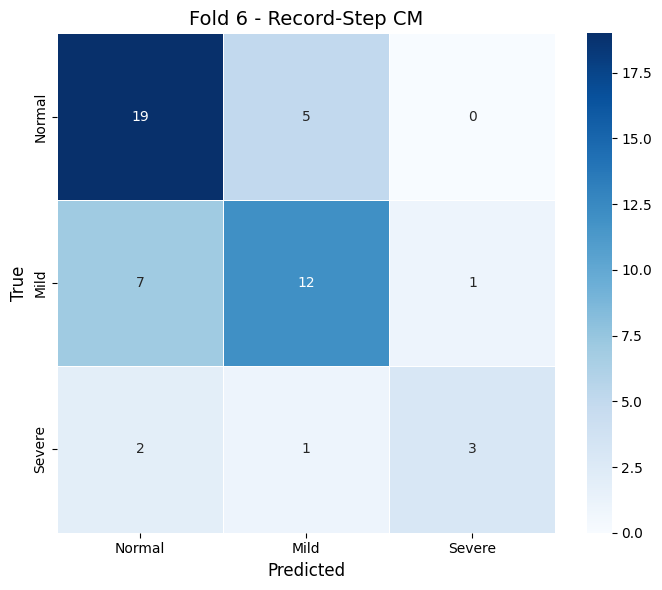


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4102 - loss: 1.3826  val_record_step_balanced_accuracy: 0.3094
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.4333 - loss: 1.3294 - val_accuracy: 0.3623 - val_loss: 1.1041 - val_record_step_balanced_accuracy: 0.3094 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4549 - loss: 1.2953  val_record_step_balanced_accuracy: 0.4043
79/79 ━━

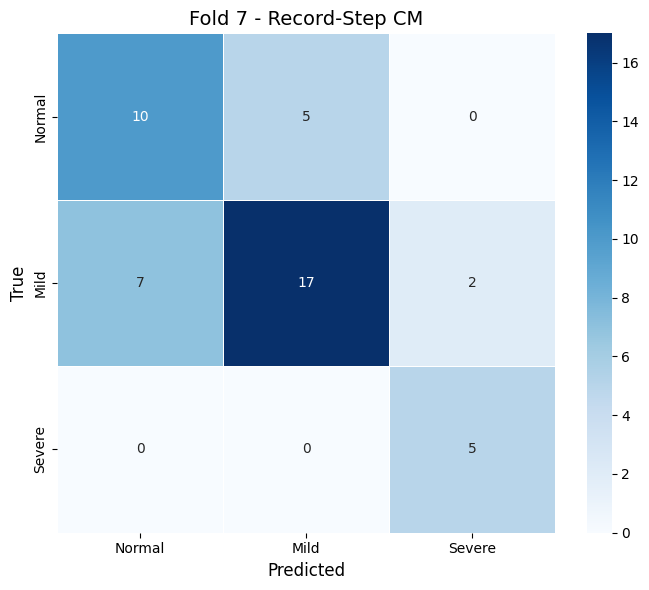


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4074 - loss: 1.3610  val_record_step_balanced_accuracy: 0.4918
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.4518 - loss: 1.3120 - val_accuracy: 0.5000 - val_loss: 1.0268 - val_record_step_balanced_accuracy: 0.4918 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4907 - loss: 1.2372  val_record_step_balanced_accuracy: 0.4362
80/80 ━━

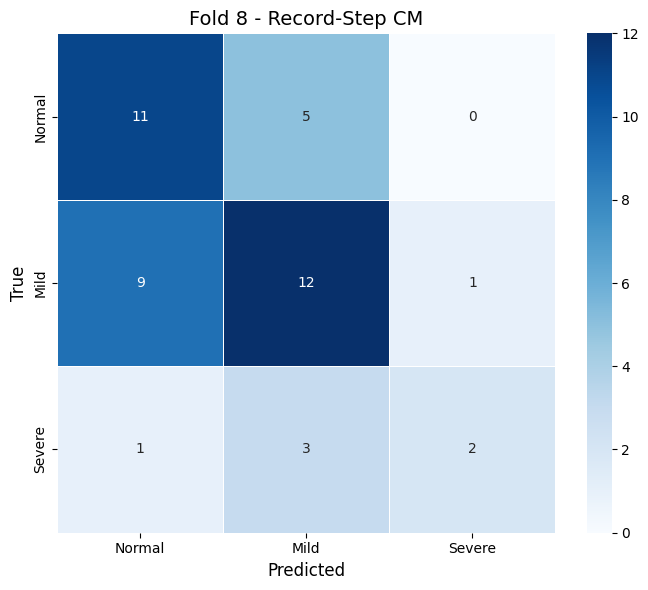


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3674 - loss: 1.4112  val_record_step_balanced_accuracy: 0.4216
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.4104 - loss: 1.3748 - val_accuracy: 0.3595 - val_loss: 1.0845 - val_record_step_balanced_accuracy: 0.4216 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4586 - loss: 1.2734  val_record_step_balanced_accuracy: 0.4317
78/78

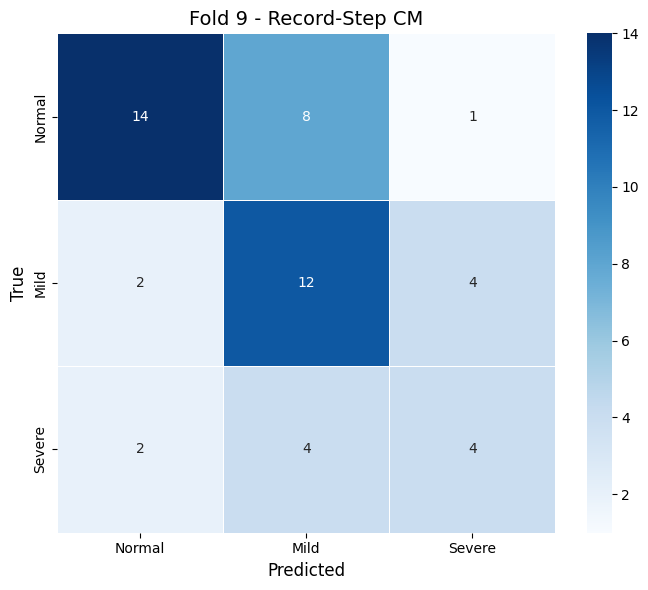


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3664 - loss: 1.4657  val_record_step_balanced_accuracy: 0.4322
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.4063 - loss: 1.4026 - val_accuracy: 0.5580 - val_loss: 0.9958 - val_record_step_balanced_accuracy: 0.4322 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4627 - loss: 1.2828  val_record_step_balanced_accuracy: 0.5324
79/79 ━

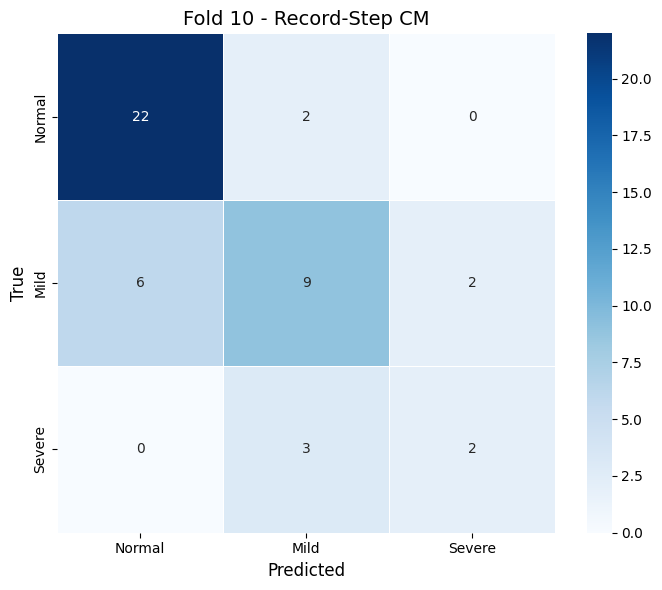


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6370 +/- 0.0504
  balanced_accuracy     : 0.6309 +/- 0.0687
  macro_f1              : 0.6136 +/- 0.0551
  --------------------------------------------------
  precision_Normal  : 0.6714 +/- 0.1224
  recall_Normal  : 0.7171 +/- 0.1409
  f1_Normal  : 0.6751 +/- 0.0688
  precision_Mild    : 0.6753 +/- 0.1354
  recall_Mild    : 0.5916 +/- 0.1122
  f1_Mild    : 0.6124 +/- 0.0732
  precision_Severe  : 0.5573 +/- 0.1141
  recall_Severe  : 0.5840 +/- 0.1886
  f1_Severe  : 0.5534 +/- 0.1175

Overall Confusion Matrix (all folds combined):
[[134  49   5]
 [ 58 125  29]
 [ 10  18  38]]

  All folds are reliable - no filtering needed.


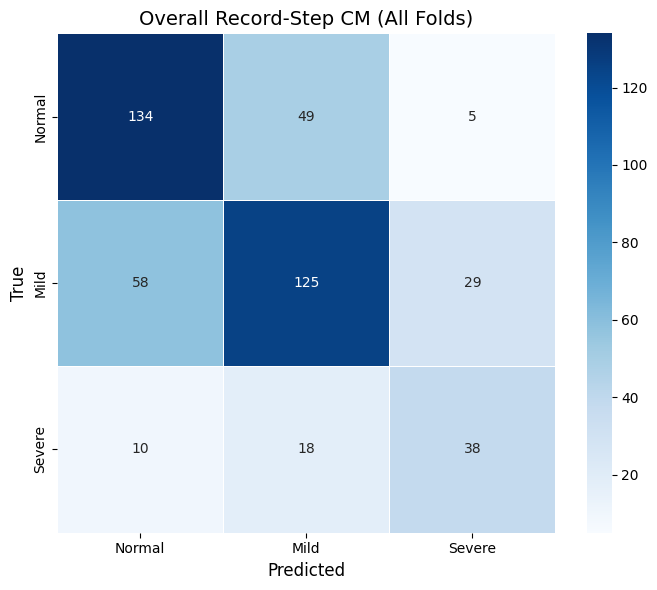

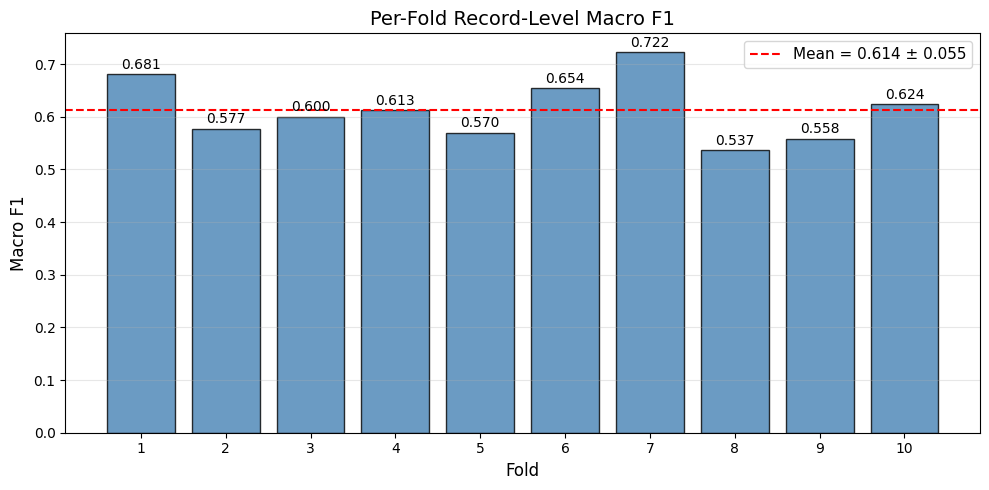


>> Manual (0.9, 1.1, 2.3) — Macro F1: 0.6136 ± 0.0551, Bal Acc: 0.6309


In [ ]:
res_m1, sum_m1 = run_experiment(
    "Manual (0.9, 1.1, 2.3)",
    manual_weights={0: 0.9, 1: 1.1, 2: 2.3},
)

### Experiment 2: Manual Weights (0.9, 1.2, 2.3)
Slightly increased Mild weight to improve Mild recall while keeping Severe emphasis fixed.


EXPERIMENT: Manual (0.9, 1.2, 2.3)
Manual class weights: {0: 0.9, 1: 1.2, 2: 2.3}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

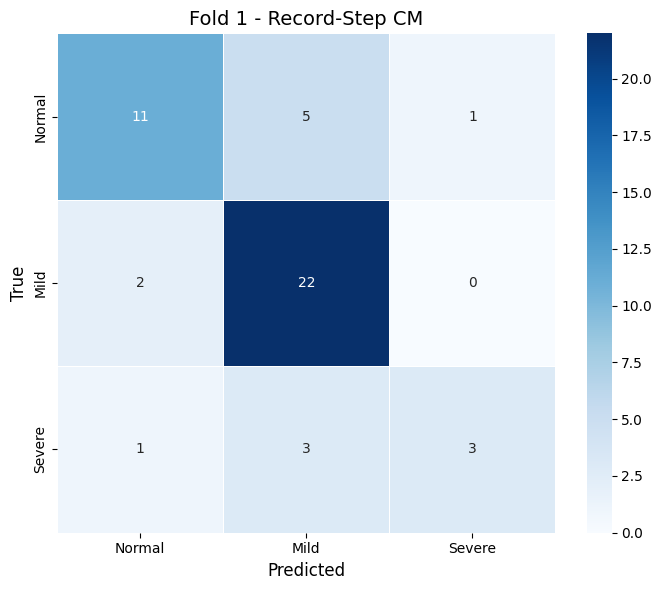


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3706 - loss: 1.4530  val_record_step_balanced_accuracy: 0.3675
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.4187 - loss: 1.4140 - val_accuracy: 0.4295 - val_loss: 1.0736 - val_record_step_balanced_accuracy: 0.3675 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4575 - loss: 1.3349  val_record_step_balanced_accuracy: 0.4313
78/78 ━━

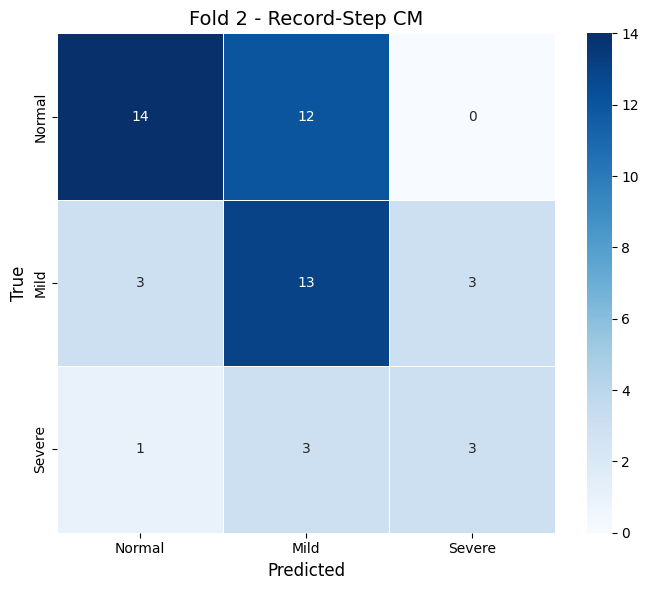


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3963 - loss: 1.5190  val_record_step_balanced_accuracy: 0.3799
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.4450 - loss: 1.4113 - val_accuracy: 0.4603 - val_loss: 1.0613 - val_record_step_balanced_accuracy: 0.3799 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4932 - loss: 1.3572  val_record_step_balanced_accuracy: 0.3980
80/80 ━━

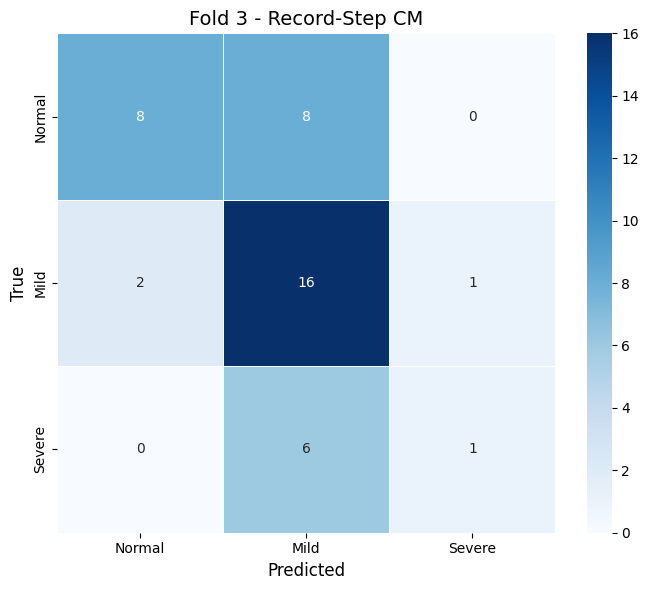


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3652 - loss: 1.4478  val_record_step_balanced_accuracy: 0.4703
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.4070 - loss: 1.4260 - val_accuracy: 0.4519 - val_loss: 1.0292 - val_record_step_balanced_accuracy: 0.4703 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5036 - loss: 1.2931  val_record_step_balanced_accuracy: 0.5886
79/79 ━

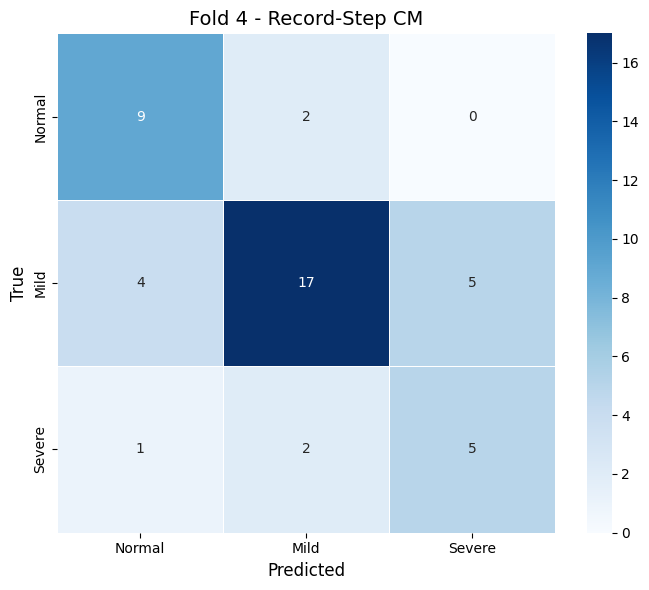


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3532 - loss: 1.4567  val_record_step_balanced_accuracy: 0.4764
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.4049 - loss: 1.3759 - val_accuracy: 0.5159 - val_loss: 1.0028 - val_record_step_balanced_accuracy: 0.4764 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4665 - loss: 1.3336  val_record_step_balanced_accuracy: 0.3621
80/80 ━

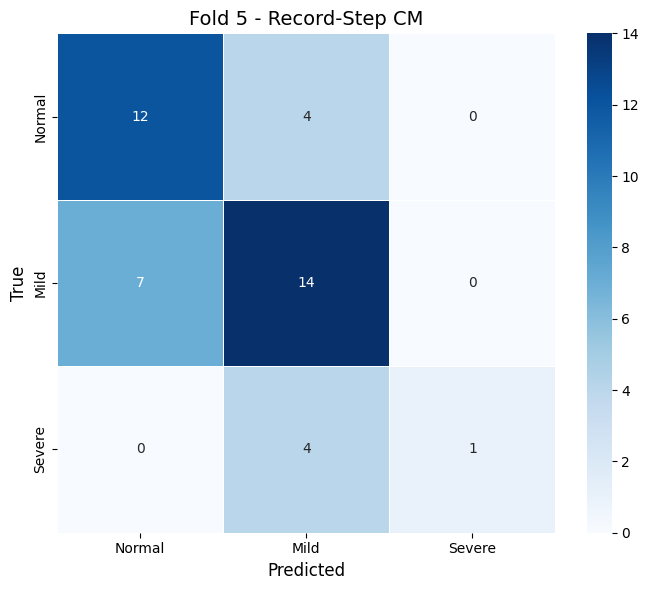


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4662 - loss: 1.3657  val_record_step_balanced_accuracy: 0.3667
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.4599 - loss: 1.3474 - val_accuracy: 0.4933 - val_loss: 1.0314 - val_record_step_balanced_accuracy: 0.3667 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5025 - loss: 1.2834  val_record_step_balanced_accuracy: 0.3917
78/78 ━━

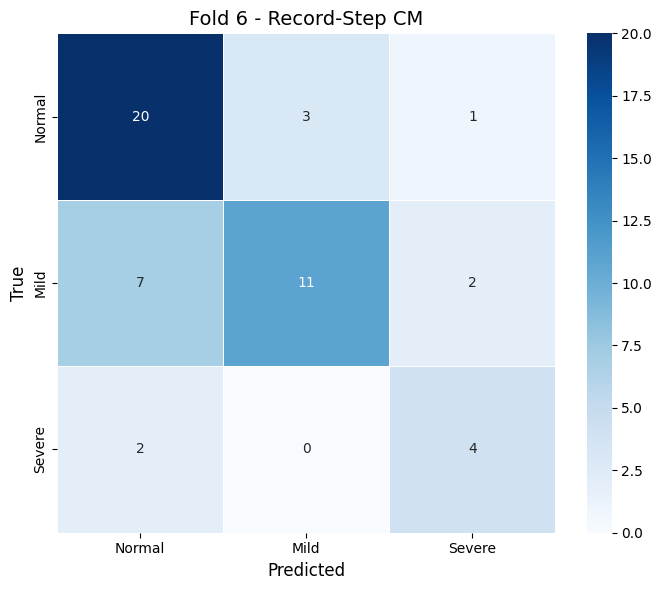


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4476 - loss: 1.4344  val_record_step_balanced_accuracy: 0.4145
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.4619 - loss: 1.3916 - val_accuracy: 0.4710 - val_loss: 1.0432 - val_record_step_balanced_accuracy: 0.4145 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4904 - loss: 1.3207  val_record_step_balanced_accuracy: 0.5350
79/79 ━

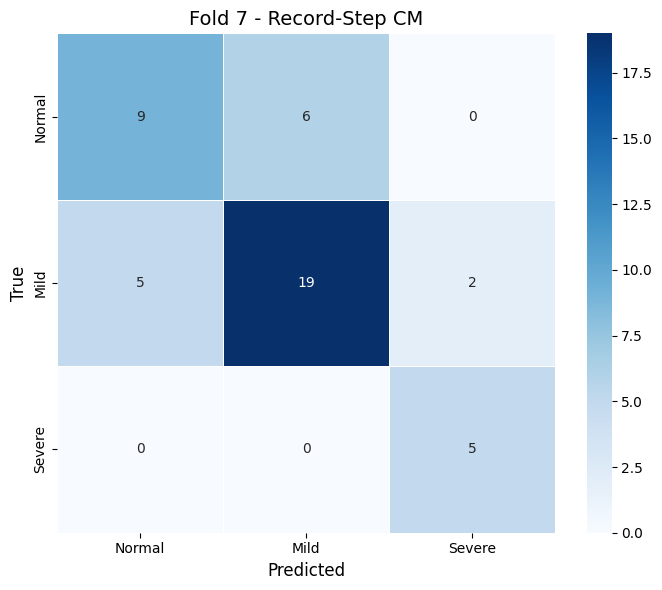


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3699 - loss: 1.4704  val_record_step_balanced_accuracy: 0.4646
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.4352 - loss: 1.3903 - val_accuracy: 0.5076 - val_loss: 1.0360 - val_record_step_balanced_accuracy: 0.4646 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4975 - loss: 1.3313  val_record_step_balanced_accuracy: 0.4590
80/80 ━━

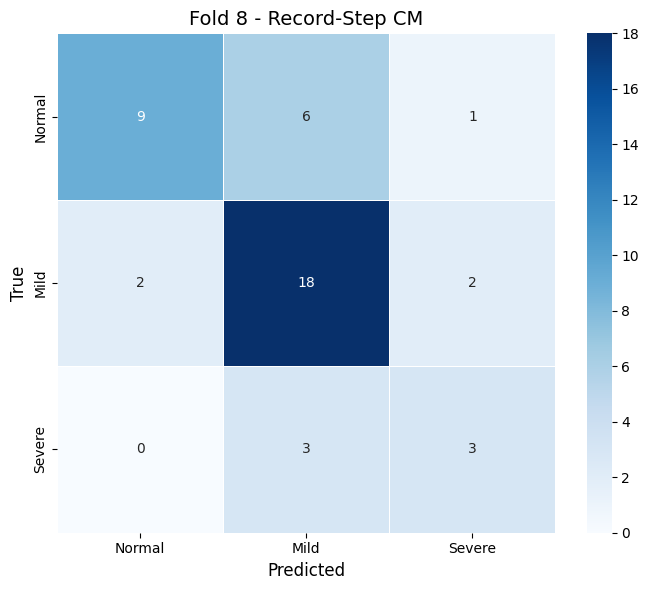


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4513 - loss: 1.3628  val_record_step_balanced_accuracy: 0.3419
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.4683 - loss: 1.3605 - val_accuracy: 0.3137 - val_loss: 1.0915 - val_record_step_balanced_accuracy: 0.3419 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4821 - loss: 1.2849  val_record_step_balanced_accuracy: 0.4180
78/78

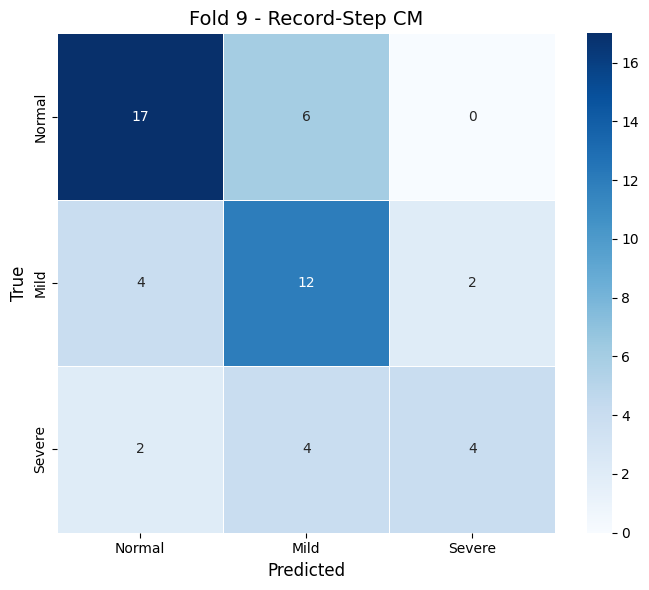


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4347 - loss: 1.4631  val_record_step_balanced_accuracy: 0.5459
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.4421 - loss: 1.4017 - val_accuracy: 0.5725 - val_loss: 0.9811 - val_record_step_balanced_accuracy: 0.5459 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4821 - loss: 1.3423  val_record_step_balanced_accuracy: 0.5851
79/79 ━

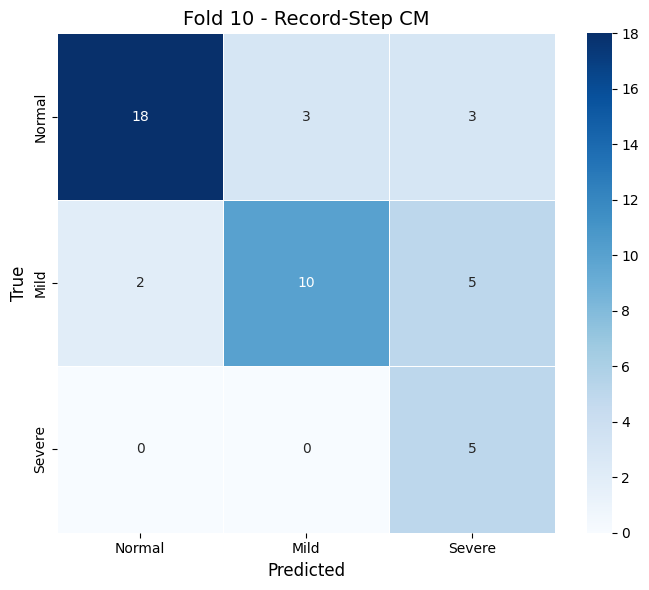


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6718 +/- 0.0527
  balanced_accuracy     : 0.6416 +/- 0.0922
  macro_f1              : 0.6293 +/- 0.0704
  --------------------------------------------------
  precision_Normal  : 0.7428 +/- 0.0848
  recall_Normal  : 0.6739 +/- 0.1137
  f1_Normal  : 0.6967 +/- 0.0614
  precision_Mild    : 0.6704 +/- 0.1151
  recall_Mild    : 0.7117 +/- 0.1097
  f1_Mild    : 0.6789 +/- 0.0725
  precision_Severe  : 0.6087 +/- 0.1693
  recall_Severe  : 0.5392 +/- 0.2767
  f1_Severe  : 0.5122 +/- 0.1541

Overall Confusion Matrix (all folds combined):
[[127  55   6]
 [ 38 152  22]
 [  7  25  34]]

  All folds are reliable - no filtering needed.


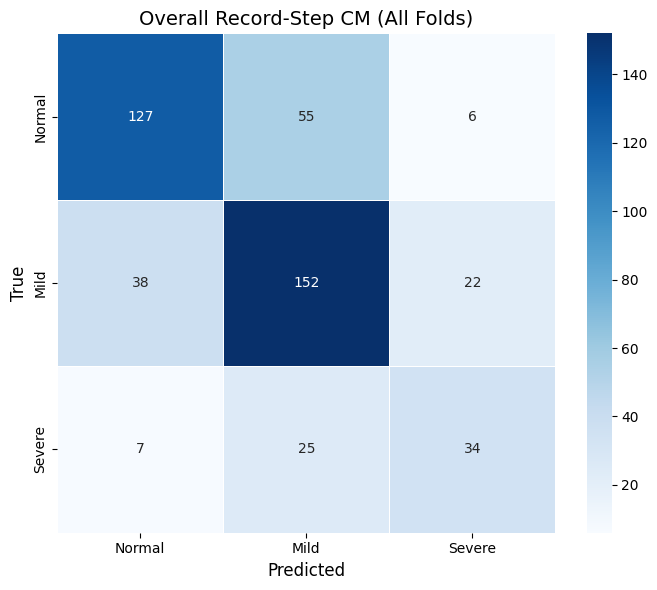

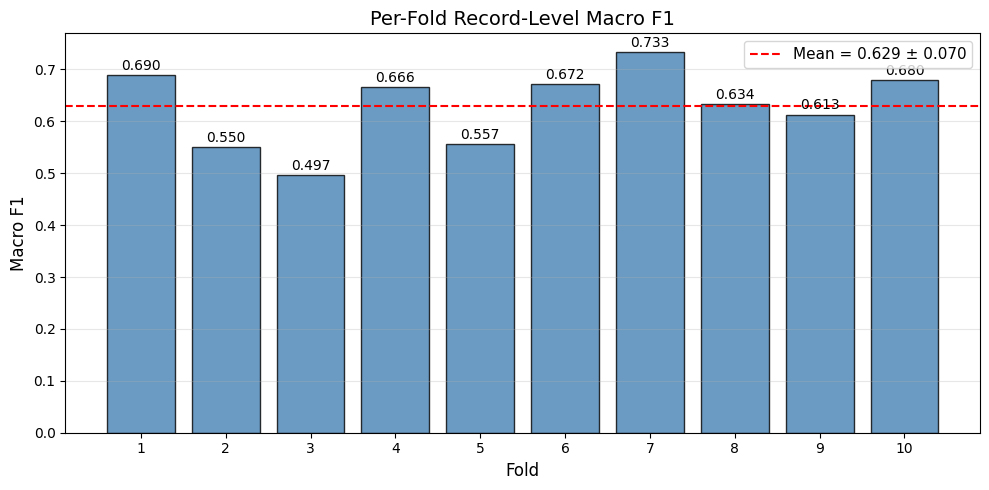


>> Manual (0.9, 1.2, 2.3) — Macro F1: 0.6293 ± 0.0704, Bal Acc: 0.6416


In [ ]:
res_m2, sum_m2 = run_experiment(
    "Manual (0.9, 1.2, 2.3)",
    manual_weights={0: 0.9, 1: 1.2, 2: 2.3},
)

### Experiment 3: Manual Weights (0.9, 1.3, 2.3)
Higher Mild emphasis to test whether further Mild up-weighting hurts Normal precision.


EXPERIMENT: Manual (0.9, 1.3, 2.3)
Manual class weights: {0: 0.9, 1: 1.3, 2: 2.3}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

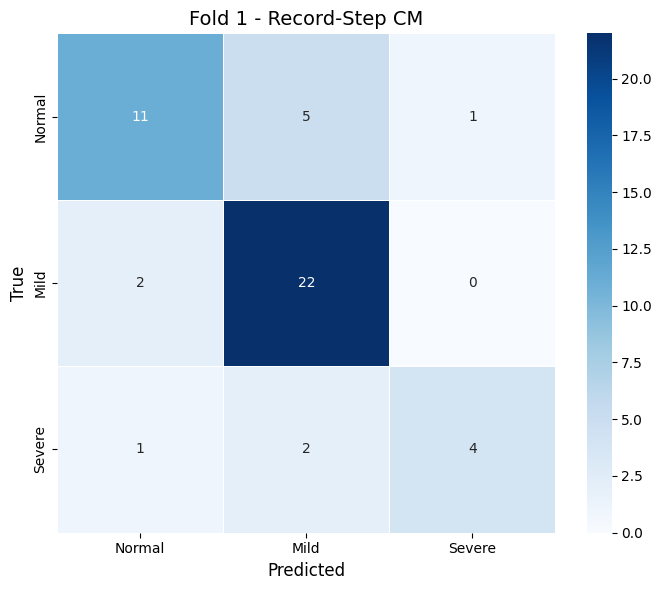


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3872 - loss: 1.4924  val_record_step_balanced_accuracy: 0.5663
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.4356 - loss: 1.4612 - val_accuracy: 0.5577 - val_loss: 1.0087 - val_record_step_balanced_accuracy: 0.5663 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4758 - loss: 1.3544  val_record_step_balanced_accuracy: 0.6190
78/78 ━━

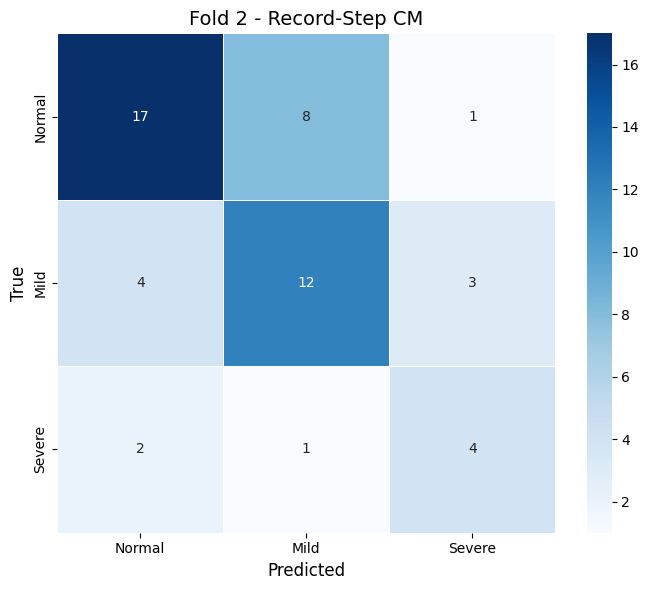


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3910 - loss: 1.4904  val_record_step_balanced_accuracy: 0.3180
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.4458 - loss: 1.4082 - val_accuracy: 0.4127 - val_loss: 1.0895 - val_record_step_balanced_accuracy: 0.3180 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4761 - loss: 1.3869  val_record_step_balanced_accuracy: 0.4090
80/80 ━━

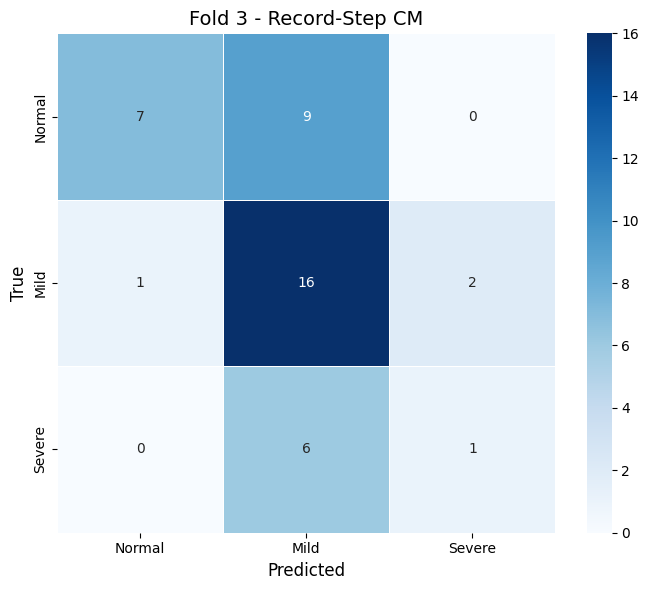


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3710 - loss: 1.4695  val_record_step_balanced_accuracy: 0.6081
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - accuracy: 0.4014 - loss: 1.4511 - val_accuracy: 0.5481 - val_loss: 1.0190 - val_record_step_balanced_accuracy: 0.6081 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4432 - loss: 1.3328  val_record_step_balanced_accuracy: 0.5408
79/79 ━

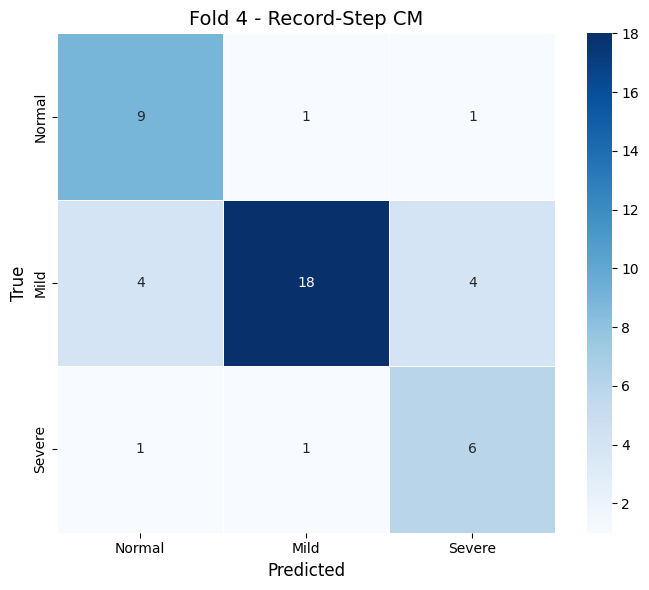


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4153 - loss: 1.4275  val_record_step_balanced_accuracy: 0.4637
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.4395 - loss: 1.3982 - val_accuracy: 0.5079 - val_loss: 1.0198 - val_record_step_balanced_accuracy: 0.4637 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4841 - loss: 1.4149  val_record_step_balanced_accuracy: 0.4845
80/80 ━━

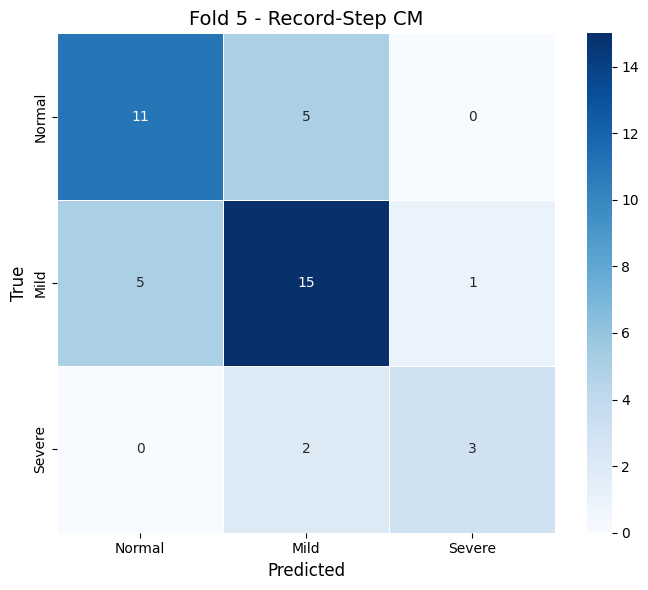


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3965 - loss: 1.5168  val_record_step_balanced_accuracy: 0.4861
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.4255 - loss: 1.4533 - val_accuracy: 0.5067 - val_loss: 1.0341 - val_record_step_balanced_accuracy: 0.4861 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5060 - loss: 1.3409  val_record_step_balanced_accuracy: 0.4472
78/78 ━

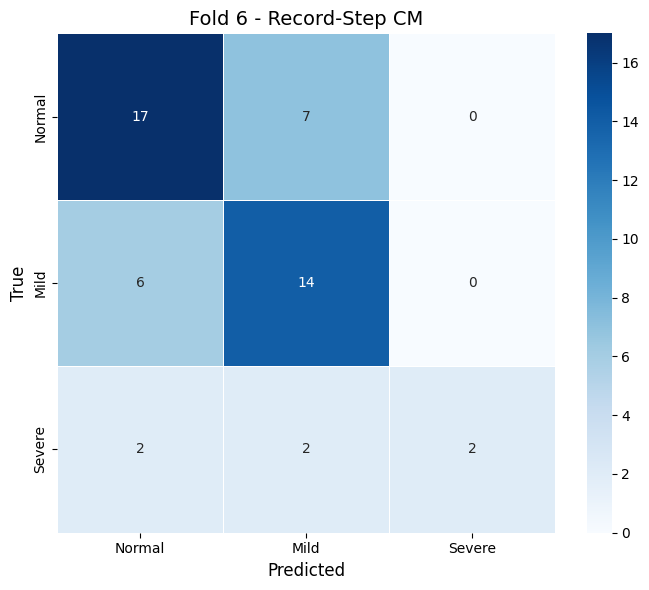


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3985 - loss: 1.5500  val_record_step_balanced_accuracy: 0.4778
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.4405 - loss: 1.4762 - val_accuracy: 0.5000 - val_loss: 1.0509 - val_record_step_balanced_accuracy: 0.4778 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4715 - loss: 1.4093  val_record_step_balanced_accuracy: 0.4333
79/79 ━

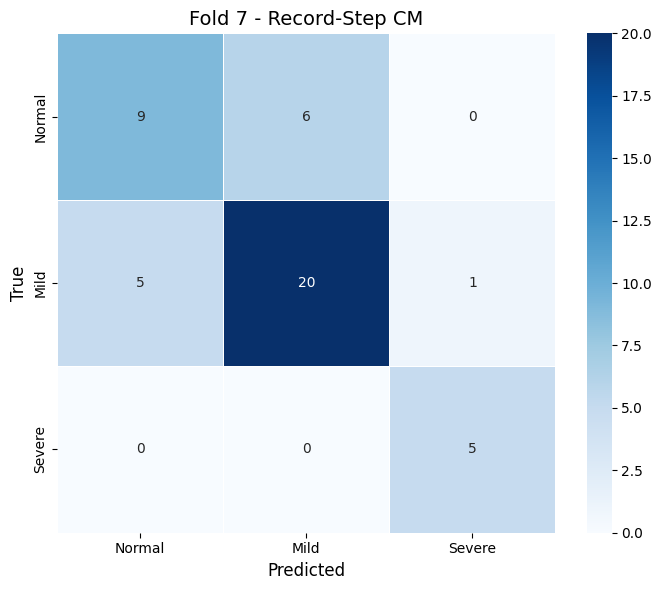


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4002 - loss: 1.3979  val_record_step_balanced_accuracy: 0.5095
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.4352 - loss: 1.3787 - val_accuracy: 0.5152 - val_loss: 1.0102 - val_record_step_balanced_accuracy: 0.5095 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5168 - loss: 1.3492  val_record_step_balanced_accuracy: 0.5455
80/80 ━━

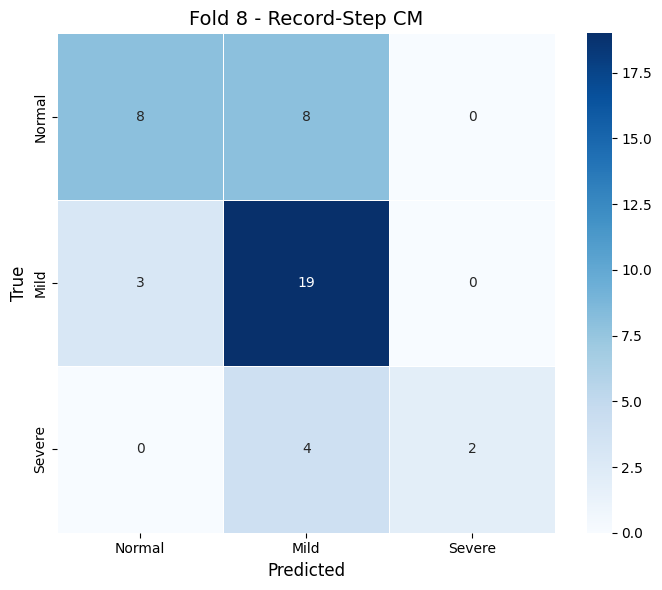


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4205 - loss: 1.4289  val_record_step_balanced_accuracy: 0.5072
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.4610 - loss: 1.3942 - val_accuracy: 0.4706 - val_loss: 1.0383 - val_record_step_balanced_accuracy: 0.5072 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4998 - loss: 1.3101  val_record_step_balanced_accuracy: 0.4147
78/78

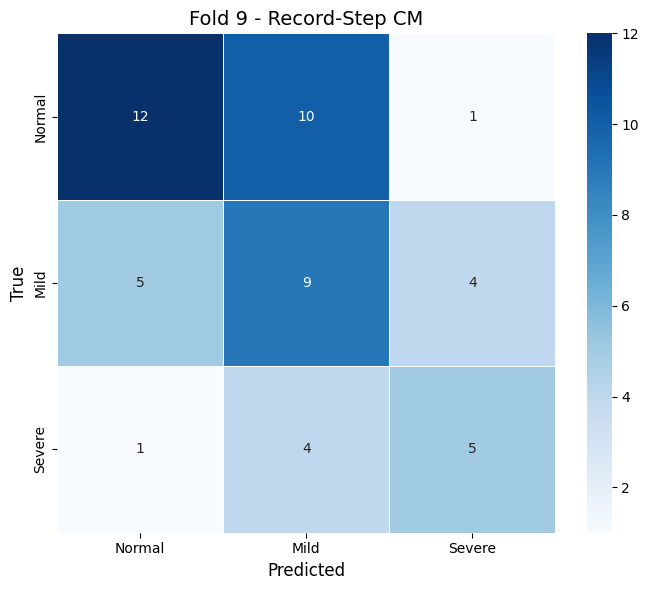


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3596 - loss: 1.5210  val_record_step_balanced_accuracy: 0.5966
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.4183 - loss: 1.4572 - val_accuracy: 0.5942 - val_loss: 0.9601 - val_record_step_balanced_accuracy: 0.5966 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4946 - loss: 1.3603  val_record_step_balanced_accuracy: 0.5851
79/79 ━

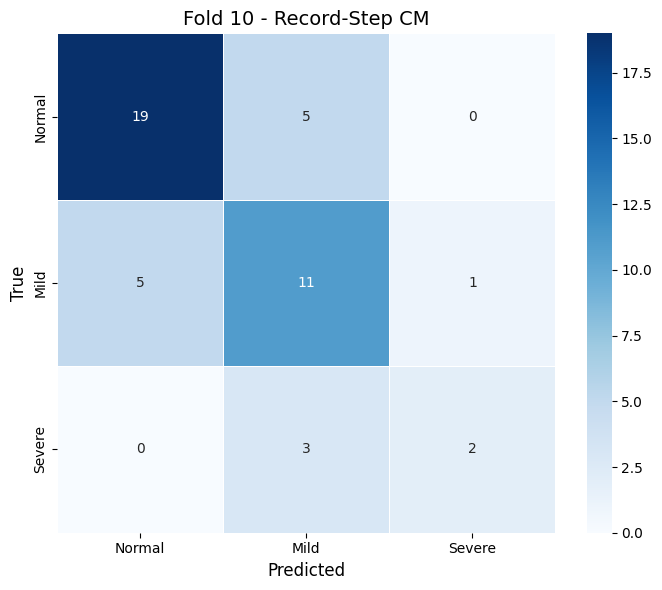


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6664 +/- 0.0753
  balanced_accuracy     : 0.6282 +/- 0.0975
  macro_f1              : 0.6341 +/- 0.0892
  --------------------------------------------------
  precision_Normal  : 0.7239 +/- 0.0715
  recall_Normal  : 0.6366 +/- 0.1175
  f1_Normal  : 0.6679 +/- 0.0659
  precision_Mild    : 0.6389 +/- 0.1369
  recall_Mild    : 0.7277 +/- 0.1178
  f1_Mild    : 0.6738 +/- 0.1068
  precision_Severe  : 0.6929 +/- 0.2119
  recall_Severe  : 0.5202 +/- 0.2284
  f1_Severe  : 0.5607 +/- 0.1716

Overall Confusion Matrix (all folds combined):
[[120  64   4]
 [ 40 156  16]
 [  7  25  34]]

  All folds are reliable - no filtering needed.


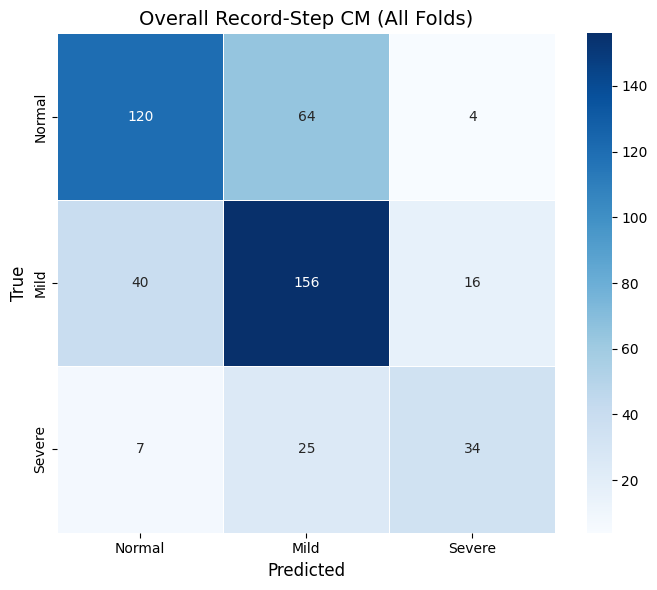

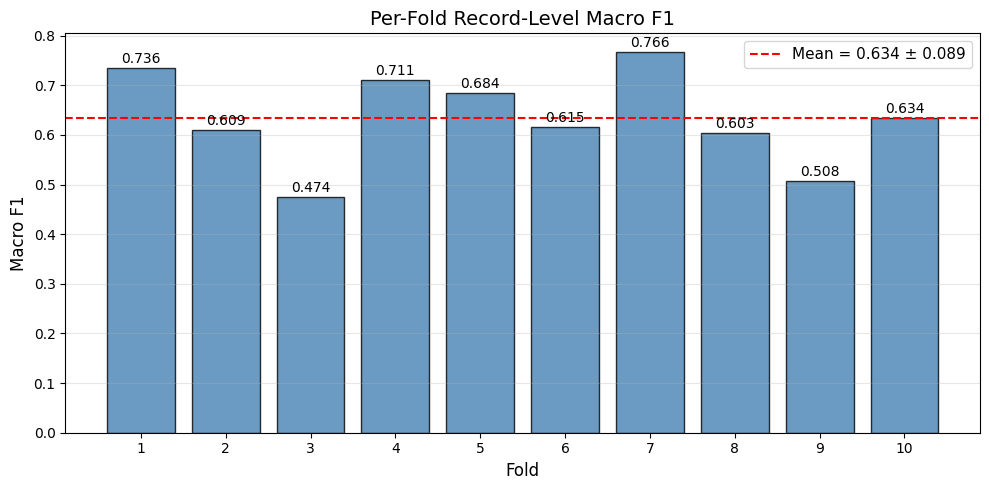


>> Manual (0.9, 1.3, 2.3) — Macro F1: 0.6341 ± 0.0892, Bal Acc: 0.6282


In [ ]:
res_m3, sum_m3 = run_experiment(
    "Manual (0.9, 1.3, 2.3)",
    manual_weights={0: 0.9, 1: 1.3, 2: 2.3},
)

##Manual Weights (0.9, 1.2, 2.5)


EXPERIMENT: Manual (0.9, 1.2, 2.5)
Manual class weights: {0: 0.9, 1: 1.2, 2: 2.5}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

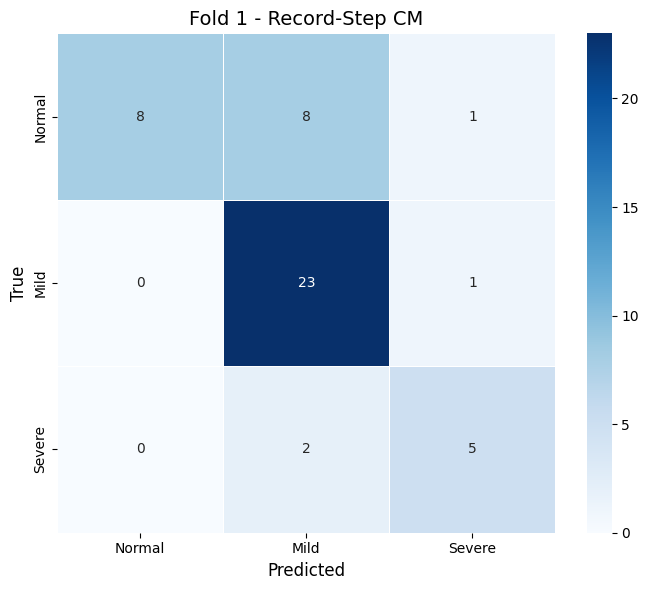


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4092 - loss: 1.4078  val_record_step_balanced_accuracy: 0.4897
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.4420 - loss: 1.4075 - val_accuracy: 0.4936 - val_loss: 1.0380 - val_record_step_balanced_accuracy: 0.4897 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4989 - loss: 1.2948  val_record_step_balanced_accuracy: 0.4850
78/78 ━

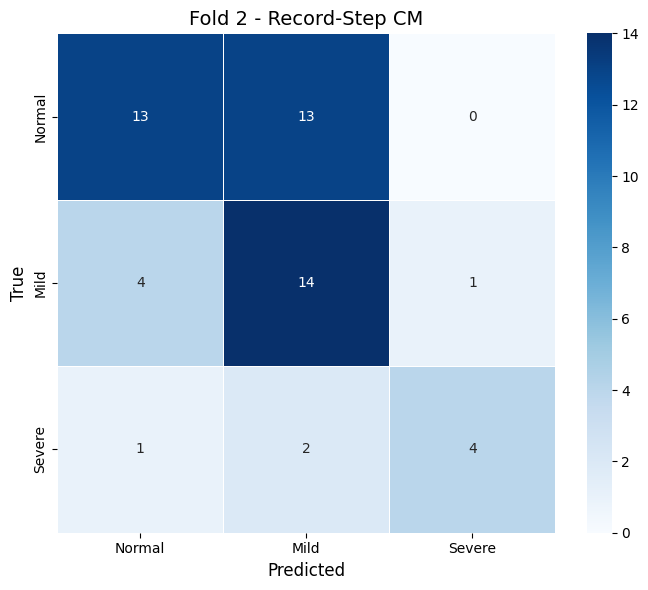


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3934 - loss: 1.5613  val_record_step_balanced_accuracy: 0.3004
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.4057 - loss: 1.4569 - val_accuracy: 0.4048 - val_loss: 1.0942 - val_record_step_balanced_accuracy: 0.3004 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4805 - loss: 1.4010  val_record_step_balanced_accuracy: 0.4516
80/80 ━

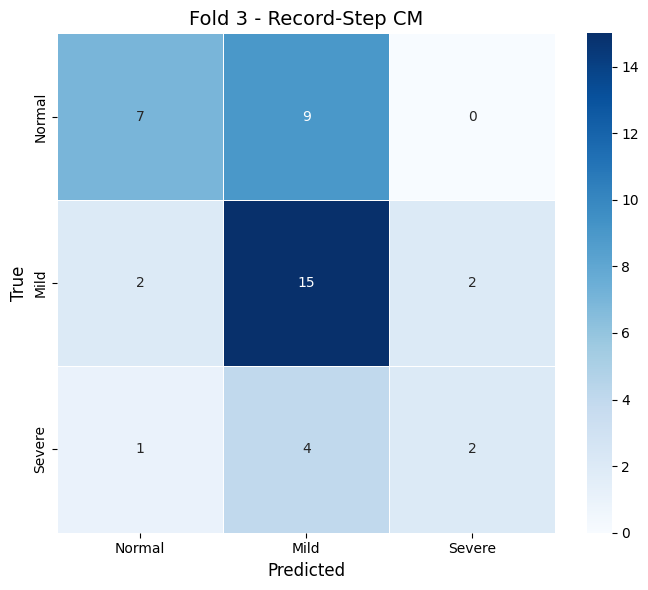


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3913 - loss: 1.4731  val_record_step_balanced_accuracy: 0.4802
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.4093 - loss: 1.4416 - val_accuracy: 0.4667 - val_loss: 1.0428 - val_record_step_balanced_accuracy: 0.4802 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4606 - loss: 1.3155  val_record_step_balanced_accuracy: 0.5105
79/79 ━

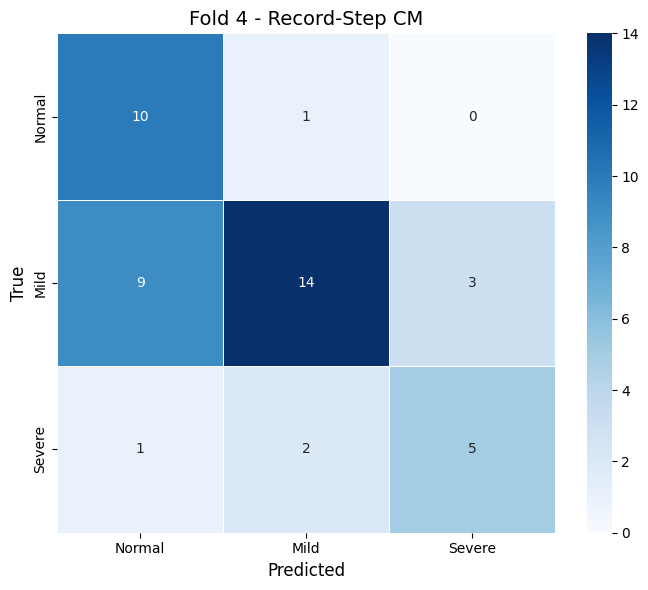


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3586 - loss: 1.5725  val_record_step_balanced_accuracy: 0.4923
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - accuracy: 0.4159 - loss: 1.4543 - val_accuracy: 0.5714 - val_loss: 0.9948 - val_record_step_balanced_accuracy: 0.4923 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4528 - loss: 1.3685  val_record_step_balanced_accuracy: 0.5339
80/80 ━

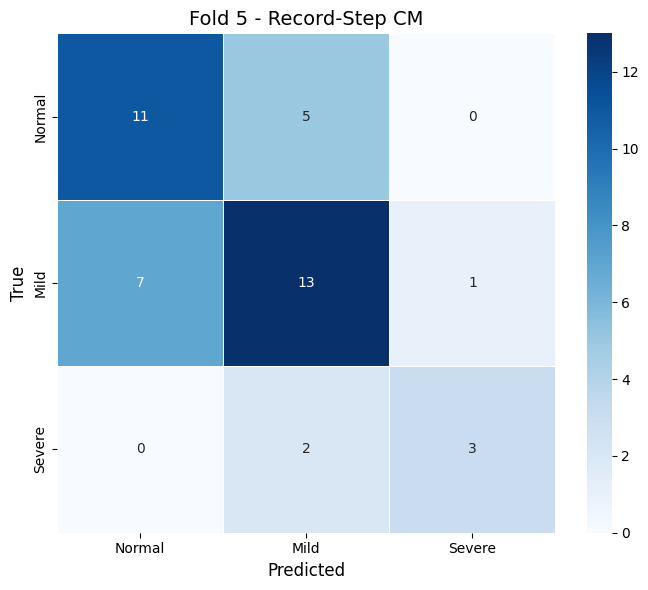


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4203 - loss: 1.4640  val_record_step_balanced_accuracy: 0.4333
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.4503 - loss: 1.4123 - val_accuracy: 0.5133 - val_loss: 1.0142 - val_record_step_balanced_accuracy: 0.4333 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4842 - loss: 1.3397  val_record_step_balanced_accuracy: 0.4861
78/78 ━

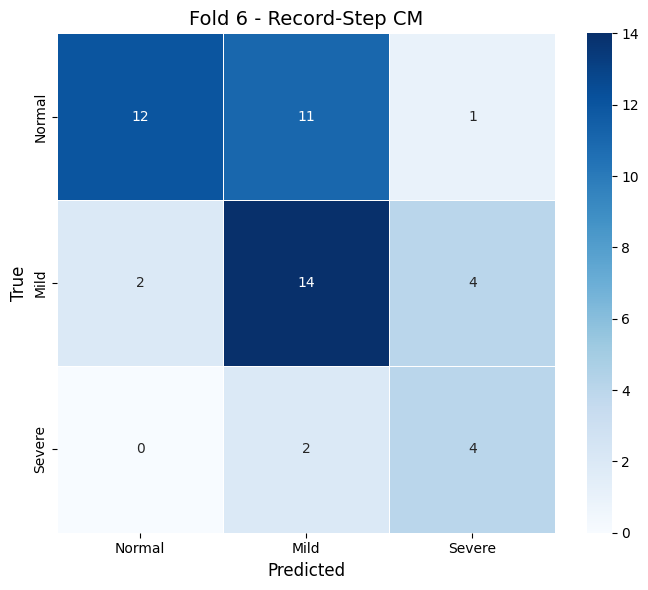


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3745 - loss: 1.4471  val_record_step_balanced_accuracy: 0.3692
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.4079 - loss: 1.4241 - val_accuracy: 0.3986 - val_loss: 1.0555 - val_record_step_balanced_accuracy: 0.3692 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4524 - loss: 1.3706  val_record_step_balanced_accuracy: 0.5607
79/79 ━

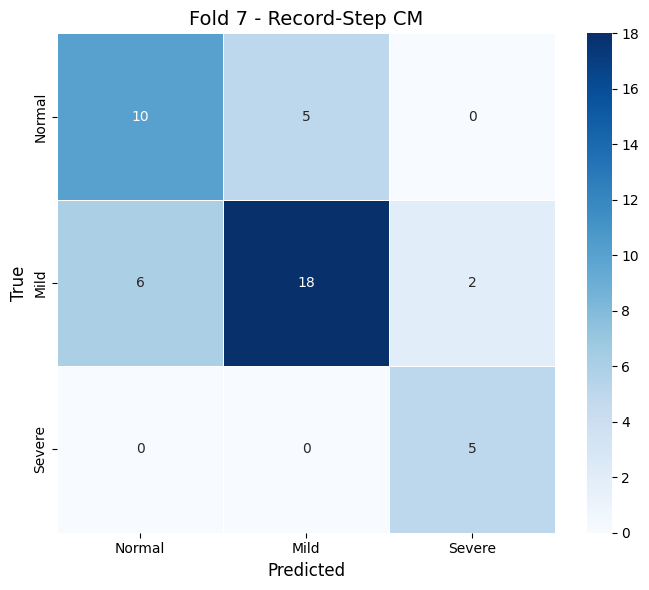


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3899 - loss: 1.5034  val_record_step_balanced_accuracy: 0.5284
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.4218 - loss: 1.4167 - val_accuracy: 0.5303 - val_loss: 1.0003 - val_record_step_balanced_accuracy: 0.5284 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4926 - loss: 1.3245  val_record_step_balanced_accuracy: 0.5758
80/80 ━

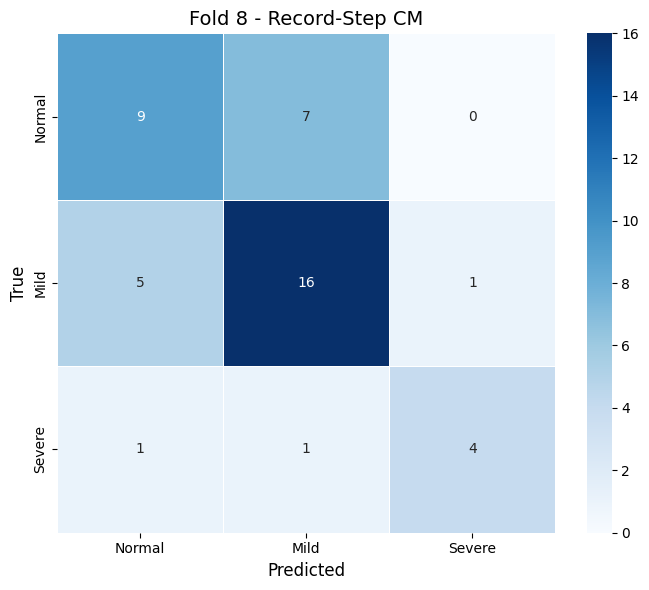


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4310 - loss: 1.3980  val_record_step_balanced_accuracy: 0.4436
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.4506 - loss: 1.3870 - val_accuracy: 0.4967 - val_loss: 1.0501 - val_record_step_balanced_accuracy: 0.4436 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4843 - loss: 1.3247  val_record_step_balanced_accuracy: 0.5325
78/78

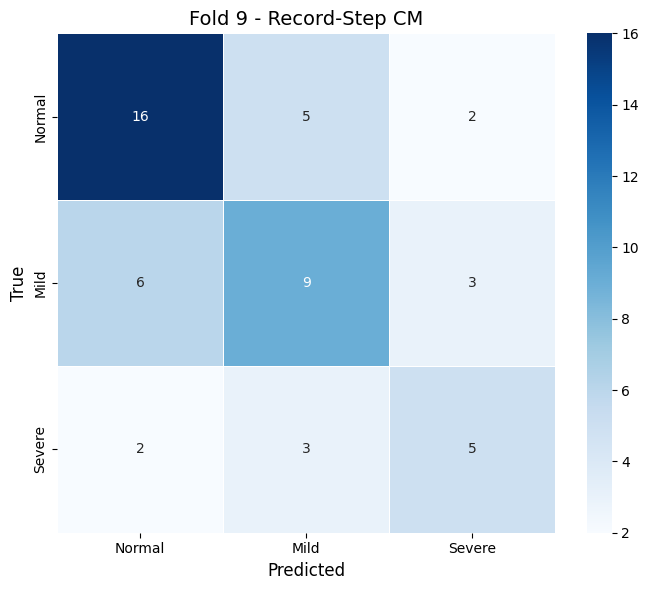


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3489 - loss: 1.6004  val_record_step_balanced_accuracy: 0.4900
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.3873 - loss: 1.4856 - val_accuracy: 0.4783 - val_loss: 1.0305 - val_record_step_balanced_accuracy: 0.4900 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4810 - loss: 1.3867  val_record_step_balanced_accuracy: 0.4961
79/79 

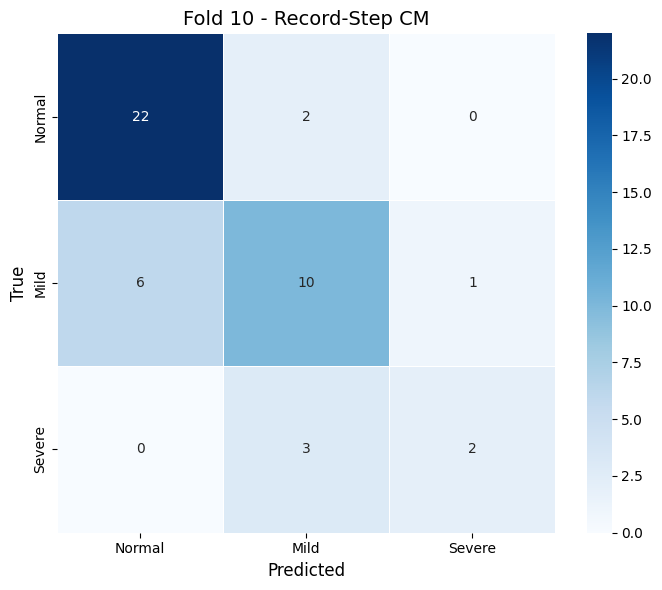


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6509 +/- 0.0617
  balanced_accuracy     : 0.6409 +/- 0.0745
  macro_f1              : 0.6352 +/- 0.0649
  --------------------------------------------------
  precision_Normal  : 0.7068 +/- 0.1366
  recall_Normal  : 0.6346 +/- 0.1642
  f1_Normal  : 0.6446 +/- 0.0777
  precision_Mild    : 0.6353 +/- 0.1101
  recall_Mild    : 0.6850 +/- 0.1264
  f1_Mild    : 0.6479 +/- 0.0779
  precision_Severe  : 0.6515 +/- 0.1230
  recall_Severe  : 0.6030 +/- 0.1822
  f1_Severe  : 0.6130 +/- 0.1311

Overall Confusion Matrix (all folds combined):
[[118  66   4]
 [ 47 146  19]
 [  6  21  39]]

  All folds are reliable - no filtering needed.


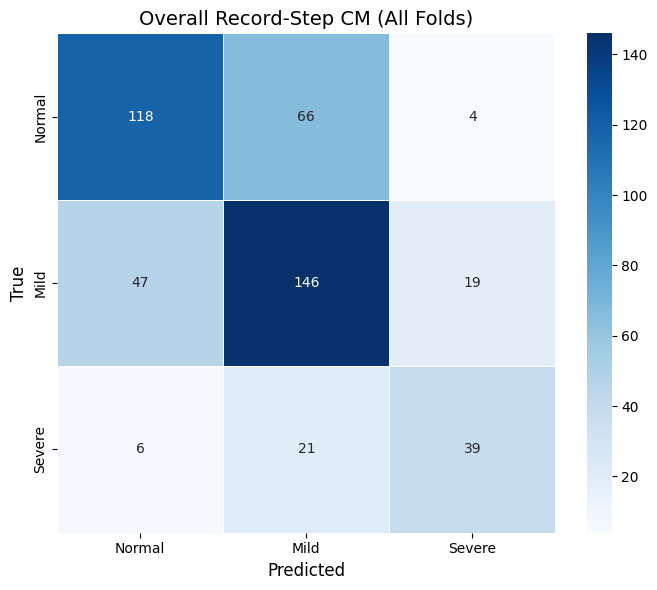

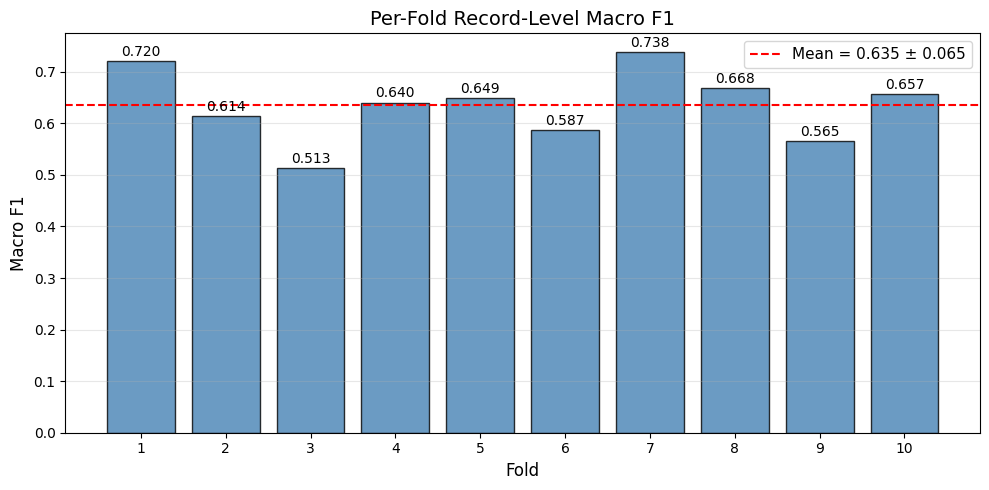


>> Manual (0.9, 1.2, 2.5) — Macro F1: 0.6352 ± 0.0649, Bal Acc: 0.6409


In [ ]:
res_m11, sum_m11 = run_experiment(
    "Manual (0.9, 1.2, 2.5)",
    manual_weights={0: 0.9, 1: 1.2, 2: 2.5},
)

### Experiment 4: Manual Weights (0.9, 1.3, 2.5)
Same Mild emphasis as Exp 3 but stronger Severe penalty to push Severe recall higher.


EXPERIMENT: Manual (0.9, 1.3, 2.5)
Manual class weights: {0: 0.9, 1: 1.3, 2: 2.5}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

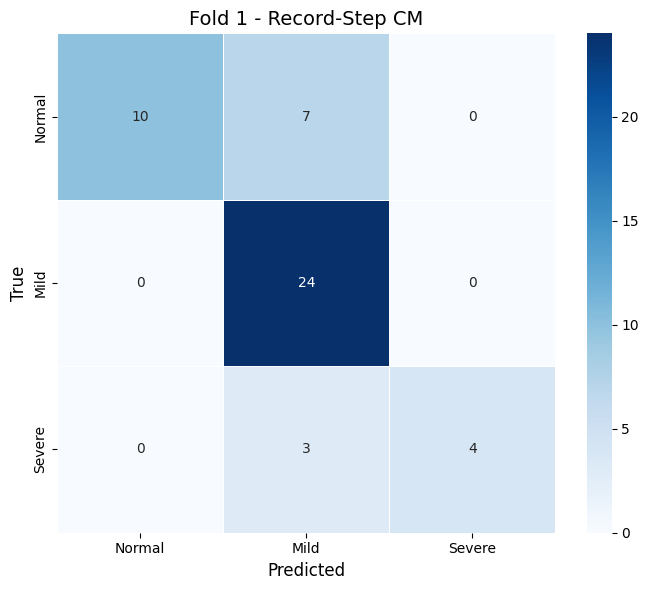


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4094 - loss: 1.4958  val_record_step_balanced_accuracy: 0.5438
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.4267 - loss: 1.5157 - val_accuracy: 0.4808 - val_loss: 1.0425 - val_record_step_balanced_accuracy: 0.5438 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4742 - loss: 1.3503  val_record_step_balanced_accuracy: 0.5789
78/78 ━

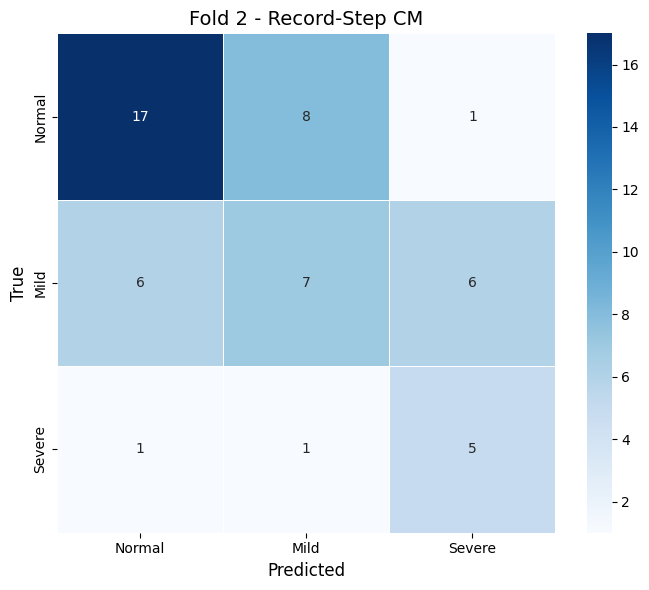


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3820 - loss: 1.5121  val_record_step_balanced_accuracy: 0.3951
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.3970 - loss: 1.4349 - val_accuracy: 0.3413 - val_loss: 1.0702 - val_record_step_balanced_accuracy: 0.3951 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4311 - loss: 1.4190  val_record_step_balanced_accuracy: 0.4685
80/80 ━━

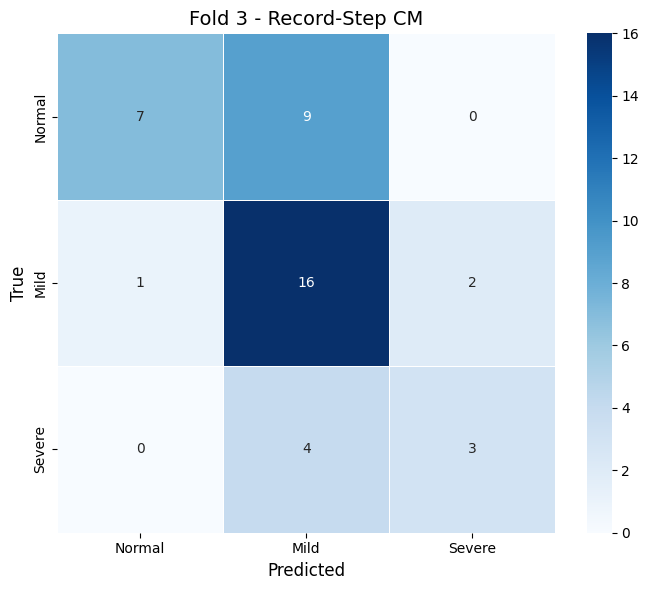


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3941 - loss: 1.5195  val_record_step_balanced_accuracy: 0.5280
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.4165 - loss: 1.4981 - val_accuracy: 0.4815 - val_loss: 1.0353 - val_record_step_balanced_accuracy: 0.5280 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4934 - loss: 1.3490  val_record_step_balanced_accuracy: 0.5536
79/79 ━

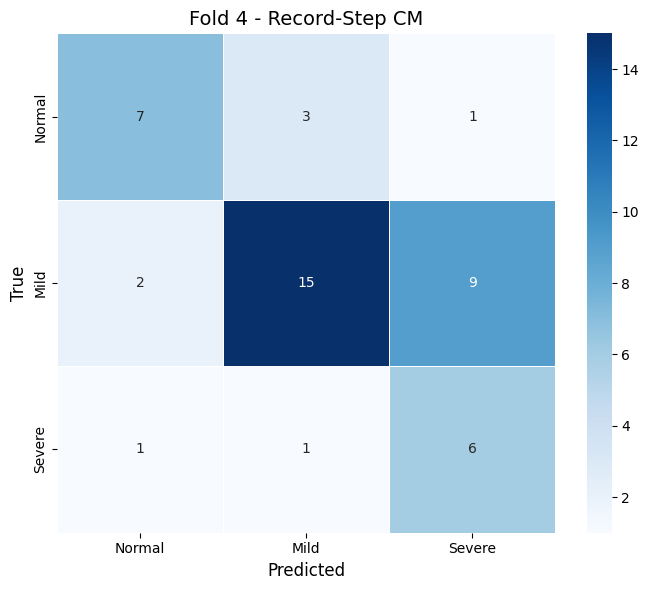


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4228 - loss: 1.4989  val_record_step_balanced_accuracy: 0.5331
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.4536 - loss: 1.4349 - val_accuracy: 0.5238 - val_loss: 1.0213 - val_record_step_balanced_accuracy: 0.5331 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4981 - loss: 1.4090  val_record_step_balanced_accuracy: 0.4923
80/80 ━

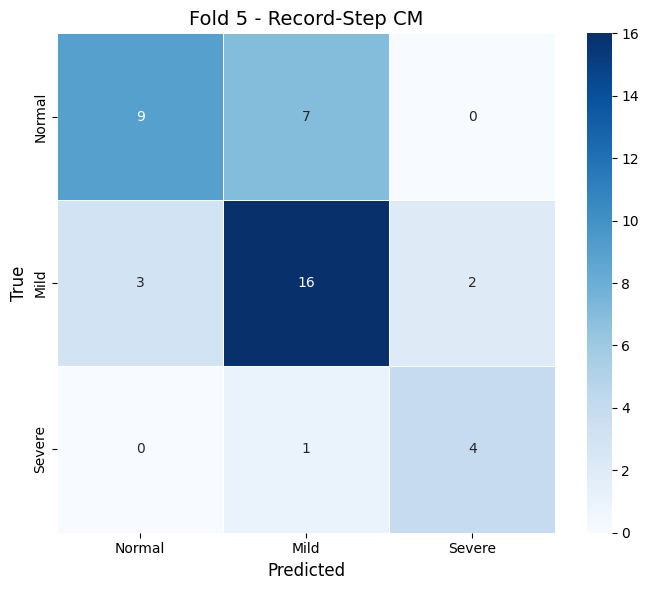


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3670 - loss: 1.5835  val_record_step_balanced_accuracy: 0.5056
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.4143 - loss: 1.5067 - val_accuracy: 0.5333 - val_loss: 1.0185 - val_record_step_balanced_accuracy: 0.5056 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4906 - loss: 1.4129  val_record_step_balanced_accuracy: 0.4806
78/78 ━━

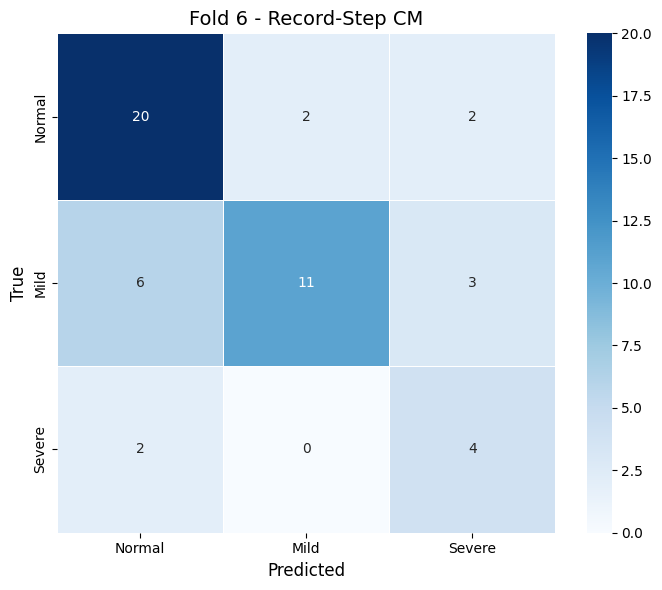


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3399 - loss: 1.6631  val_record_step_balanced_accuracy: 0.3632
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.3984 - loss: 1.5305 - val_accuracy: 0.3841 - val_loss: 1.0673 - val_record_step_balanced_accuracy: 0.3632 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4909 - loss: 1.3917  val_record_step_balanced_accuracy: 0.4966
79/79 ━

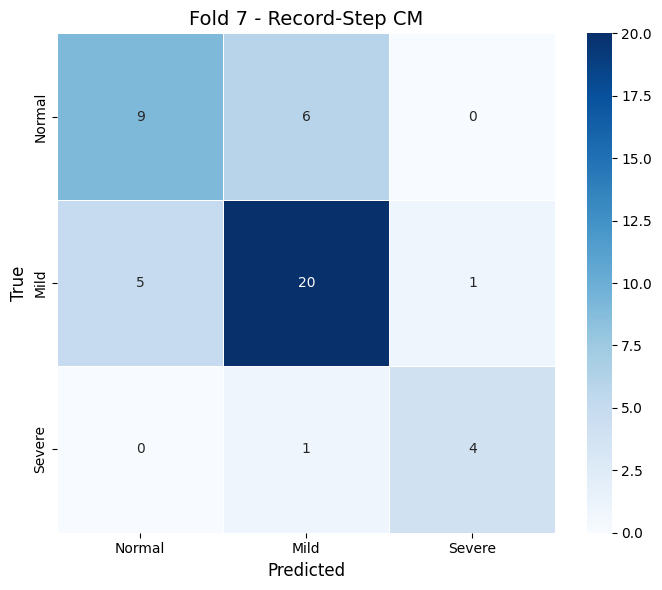


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3655 - loss: 1.6154  val_record_step_balanced_accuracy: 0.4482
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.4013 - loss: 1.5396 - val_accuracy: 0.3409 - val_loss: 1.1054 - val_record_step_balanced_accuracy: 0.4482 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4462 - loss: 1.4381  val_record_step_balanced_accuracy: 0.4539
80/80 ━━

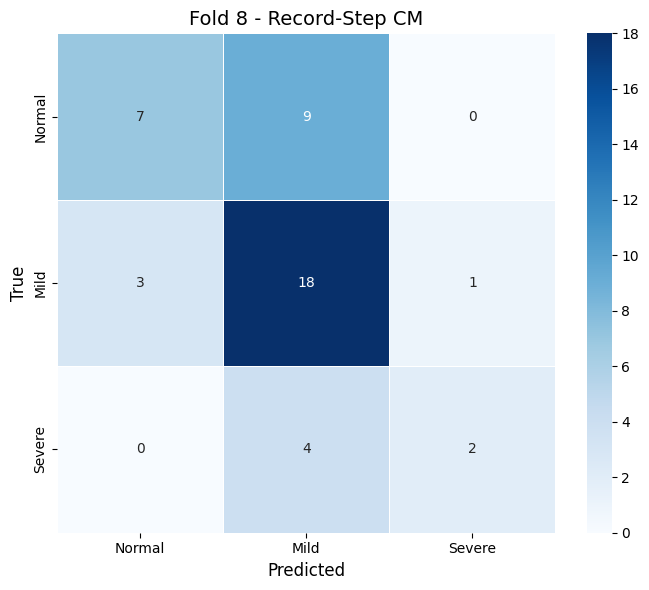


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3969 - loss: 1.5281  val_record_step_balanced_accuracy: 0.3903
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.4361 - loss: 1.4762 - val_accuracy: 0.4444 - val_loss: 1.0616 - val_record_step_balanced_accuracy: 0.3903 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4771 - loss: 1.3821  val_record_step_balanced_accuracy: 0.4110
78/78

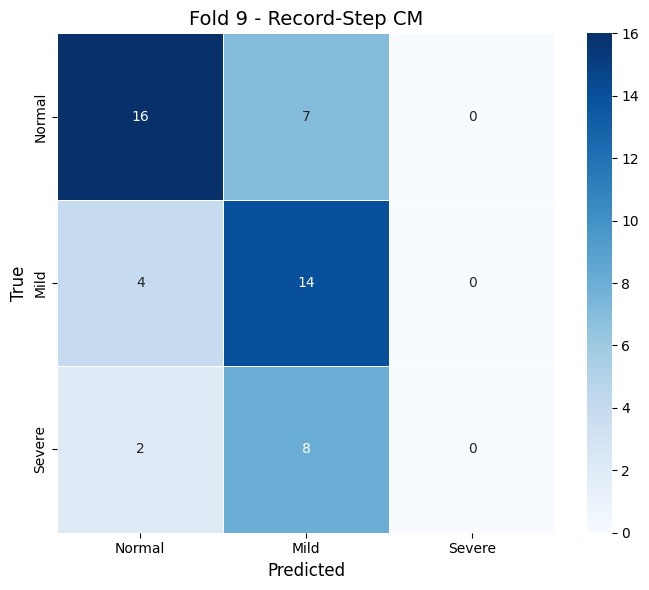


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3937 - loss: 1.5786  val_record_step_balanced_accuracy: 0.5185
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.4357 - loss: 1.4779 - val_accuracy: 0.6159 - val_loss: 0.9614 - val_record_step_balanced_accuracy: 0.5185 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4752 - loss: 1.3766  val_record_step_balanced_accuracy: 0.5046
79/79 ━

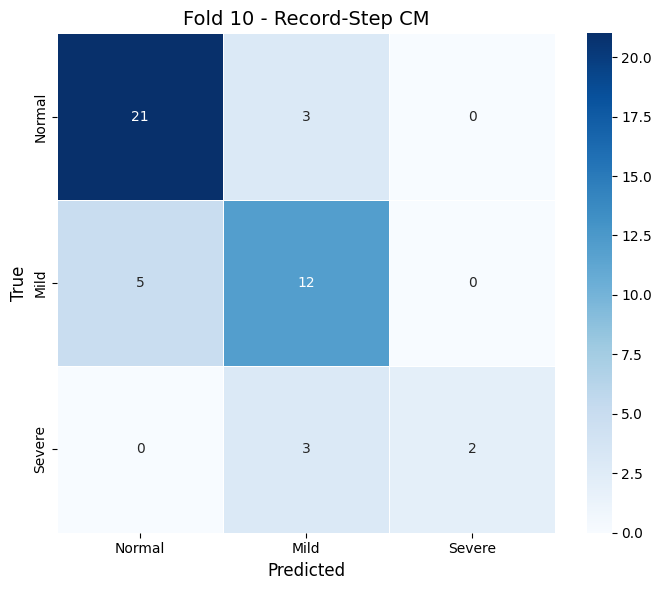


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6661 +/- 0.0734
  balanced_accuracy     : 0.6318 +/- 0.0793
  macro_f1              : 0.6259 +/- 0.0958
  --------------------------------------------------
  precision_Normal  : 0.7625 +/- 0.0999
  recall_Normal  : 0.6320 +/- 0.1370
  f1_Normal  : 0.6793 +/- 0.0852
  precision_Mild    : 0.6468 +/- 0.1254
  recall_Mild    : 0.7170 +/- 0.1684
  f1_Mild    : 0.6654 +/- 0.1060
  precision_Severe  : 0.5969 +/- 0.2893
  recall_Severe  : 0.5464 +/- 0.2434
  f1_Severe  : 0.5330 +/- 0.2103

Overall Confusion Matrix (all folds combined):
[[123  61   4]
 [ 35 153  24]
 [  6  26  34]]

  All folds are reliable - no filtering needed.


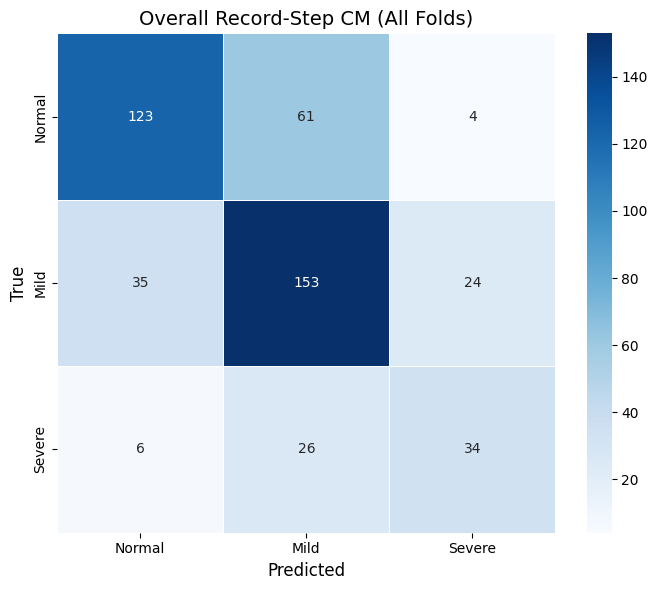

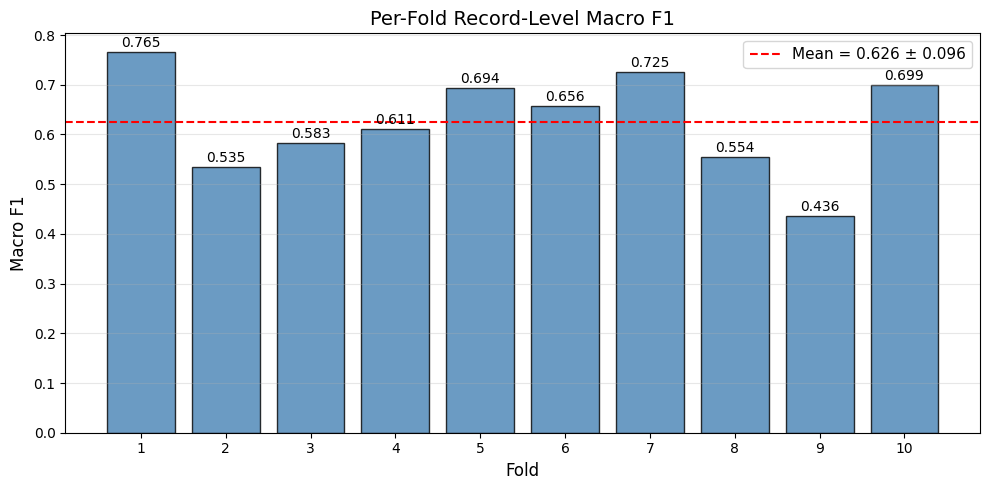


>> Manual (0.9, 1.3, 2.5) — Macro F1: 0.6259 ± 0.0958, Bal Acc: 0.6318


In [ ]:
res_m4, sum_m4 = run_experiment(
    "Manual (0.9, 1.3, 2.5)",
    manual_weights={0: 0.9, 1: 1.3, 2: 2.5},
)

### Experiment 5: Manual Weights (1.0, 1.2, 2.3)
Neutral Normal weight with moderate Mild and strong Severe emphasis.


EXPERIMENT: Manual (1.0, 1.2, 2.3)
Manual class weights: {0: 1.0, 1: 1.2, 2: 2.3}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

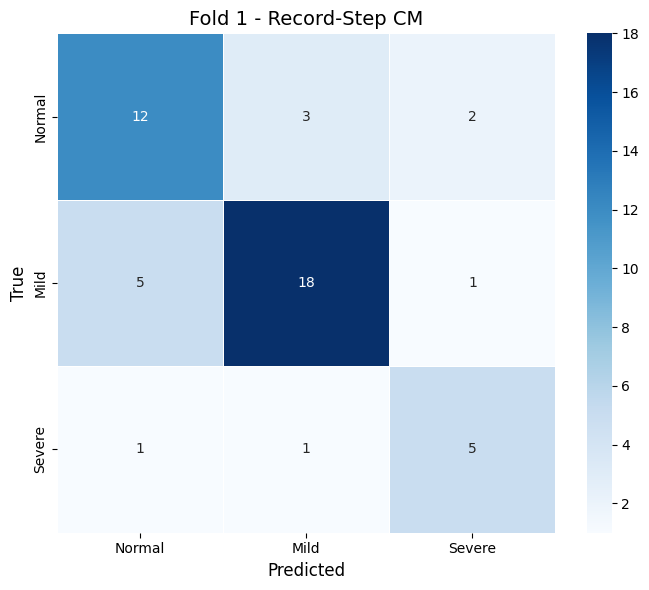


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4664 - loss: 1.4150  val_record_step_balanced_accuracy: 0.6011
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.4541 - loss: 1.4356 - val_accuracy: 0.5449 - val_loss: 0.9966 - val_record_step_balanced_accuracy: 0.6011 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4980 - loss: 1.3278  val_record_step_balanced_accuracy: 0.5886
78/78 ━

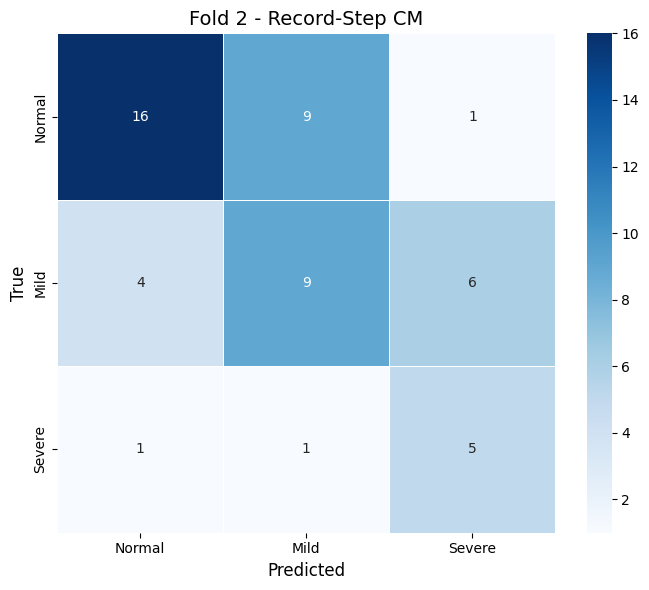


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4083 - loss: 1.4415  val_record_step_balanced_accuracy: 0.4209
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.4410 - loss: 1.3907 - val_accuracy: 0.4762 - val_loss: 1.0326 - val_record_step_balanced_accuracy: 0.4209 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4518 - loss: 1.4074  val_record_step_balanced_accuracy: 0.4834
80/80 ━━

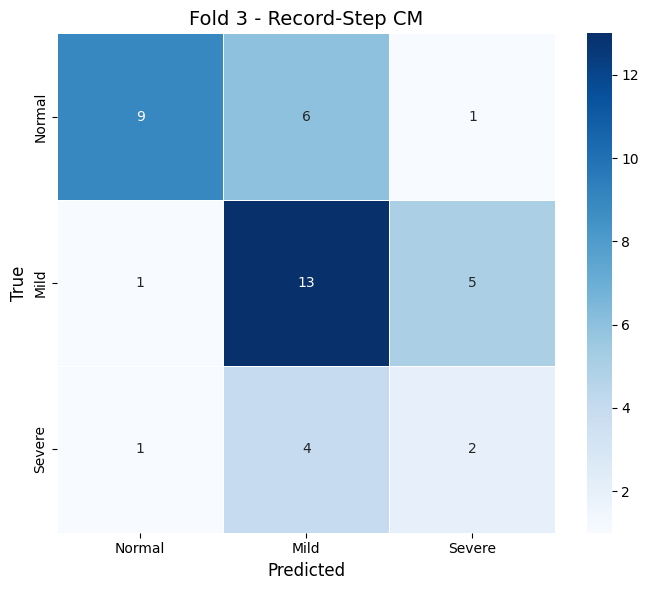


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4641 - loss: 1.4126  val_record_step_balanced_accuracy: 0.5309
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.4584 - loss: 1.4415 - val_accuracy: 0.5111 - val_loss: 1.0338 - val_record_step_balanced_accuracy: 0.5309 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4683 - loss: 1.3322  val_record_step_balanced_accuracy: 0.4636
79/79 ━━

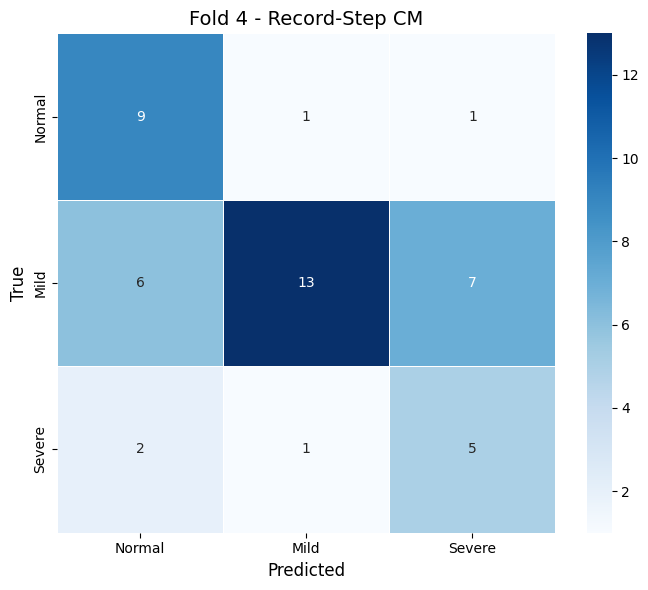


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3558 - loss: 1.6496  val_record_step_balanced_accuracy: 0.3304
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.3954 - loss: 1.5470 - val_accuracy: 0.5159 - val_loss: 0.9944 - val_record_step_balanced_accuracy: 0.3304 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4683 - loss: 1.4337  val_record_step_balanced_accuracy: 0.4546
80/80 ━

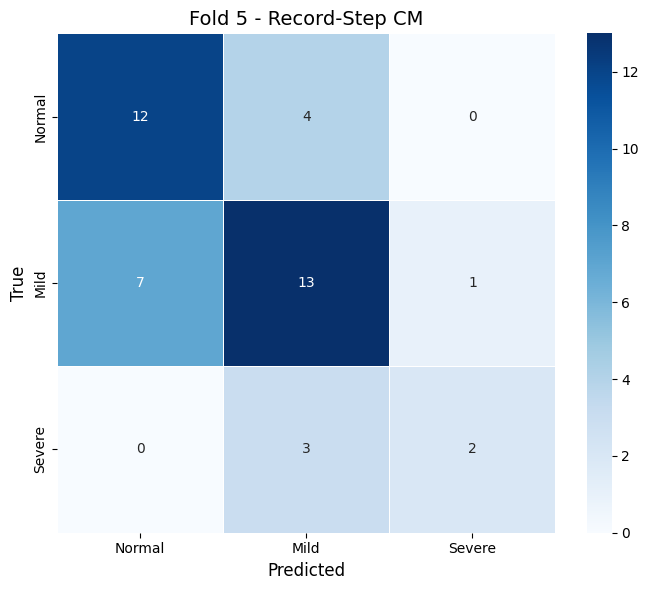


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4020 - loss: 1.5273  val_record_step_balanced_accuracy: 0.4778
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.4311 - loss: 1.4351 - val_accuracy: 0.5333 - val_loss: 0.9945 - val_record_step_balanced_accuracy: 0.4778 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4707 - loss: 1.3675  val_record_step_balanced_accuracy: 0.4750
78/78 ━━

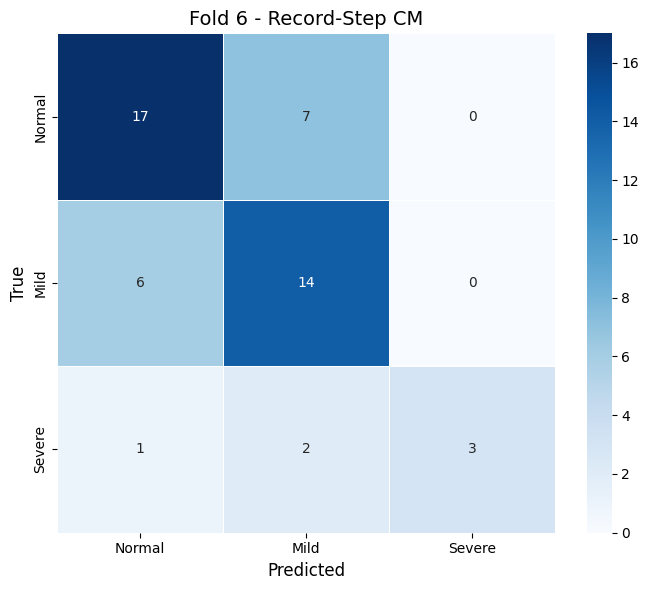


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3690 - loss: 1.5129  val_record_step_balanced_accuracy: 0.4368
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.4230 - loss: 1.4502 - val_accuracy: 0.4710 - val_loss: 1.0180 - val_record_step_balanced_accuracy: 0.4368 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5135 - loss: 1.3570  val_record_step_balanced_accuracy: 0.4111
79/79 ━

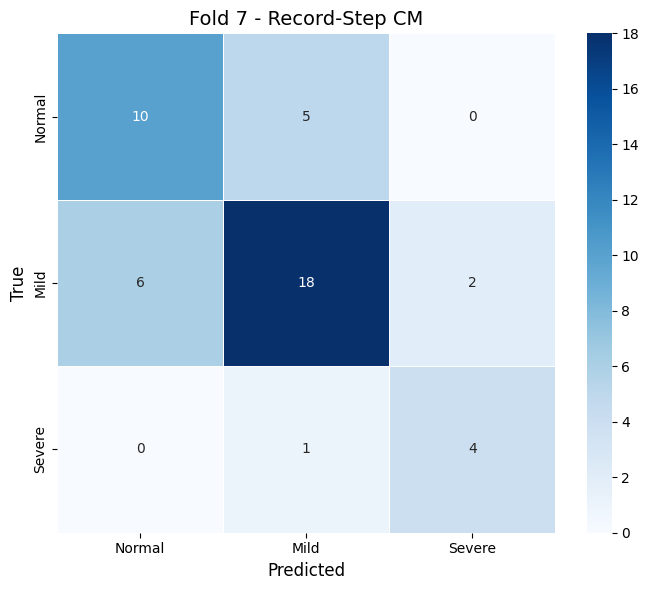


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3750 - loss: 1.4609  val_record_step_balanced_accuracy: 0.3087
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.4123 - loss: 1.4155 - val_accuracy: 0.4621 - val_loss: 1.0667 - val_record_step_balanced_accuracy: 0.3087 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4880 - loss: 1.3754  val_record_step_balanced_accuracy: 0.3504
80/80 ━━

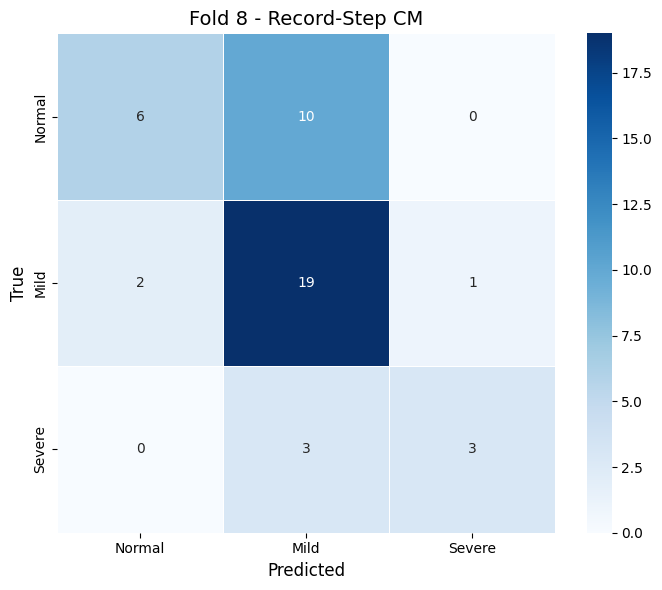


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4202 - loss: 1.4297  val_record_step_balanced_accuracy: 0.4531
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.4618 - loss: 1.3838 - val_accuracy: 0.5033 - val_loss: 1.0176 - val_record_step_balanced_accuracy: 0.4531 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5184 - loss: 1.3026  val_record_step_balanced_accuracy: 0.4639
78/78

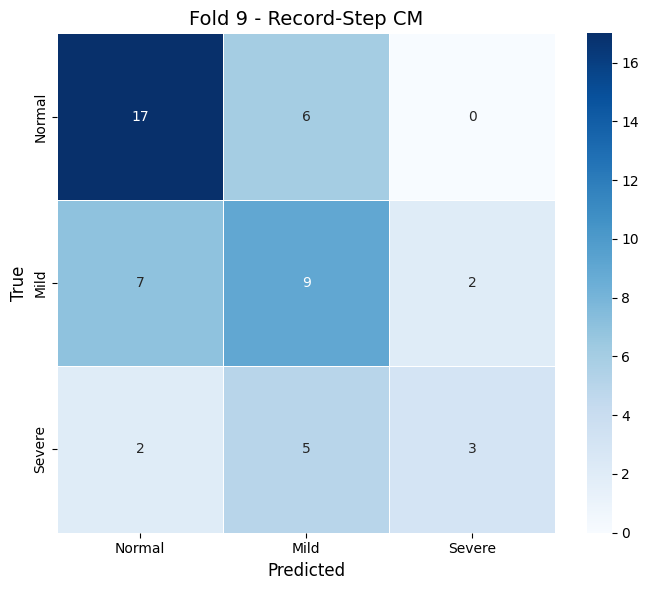


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4009 - loss: 1.4907  val_record_step_balanced_accuracy: 0.4757
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.4365 - loss: 1.4644 - val_accuracy: 0.5362 - val_loss: 0.9903 - val_record_step_balanced_accuracy: 0.4757 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4517 - loss: 1.3766  val_record_step_balanced_accuracy: 0.5619
79/79 

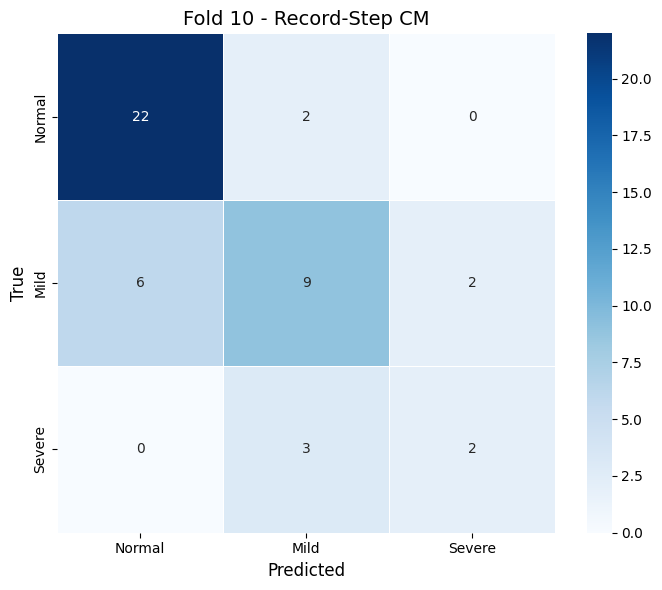


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6418 +/- 0.0583
  balanced_accuracy     : 0.6136 +/- 0.0690
  macro_f1              : 0.6101 +/- 0.0647
  --------------------------------------------------
  precision_Normal  : 0.6931 +/- 0.0836
  recall_Normal  : 0.6858 +/- 0.1399
  f1_Normal  : 0.6755 +/- 0.0798
  precision_Mild    : 0.6419 +/- 0.1295
  recall_Mild    : 0.6312 +/- 0.1221
  f1_Mild    : 0.6273 +/- 0.0942
  precision_Severe  : 0.5860 +/- 0.2006
  recall_Severe  : 0.5239 +/- 0.1725
  f1_Severe  : 0.5274 +/- 0.1336

Overall Confusion Matrix (all folds combined):
[[130  53   5]
 [ 50 135  27]
 [  8  24  34]]

  All folds are reliable - no filtering needed.


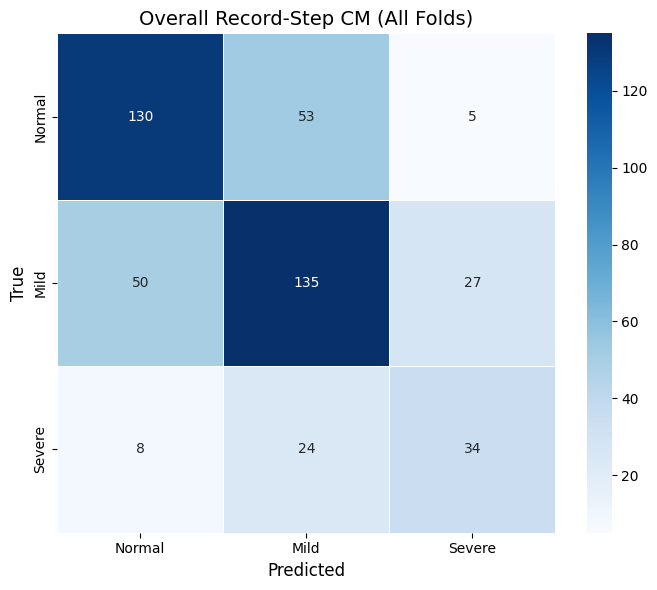

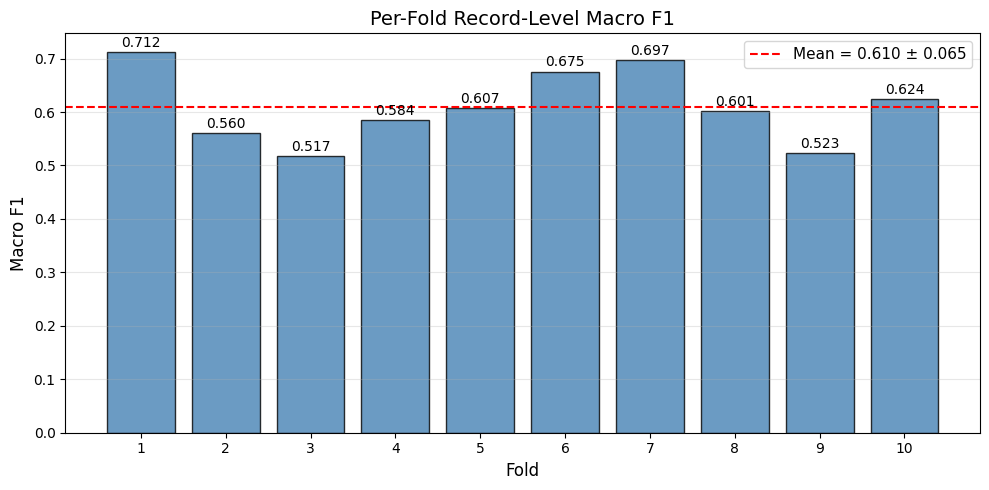


>> Manual (1.0, 1.2, 2.3) — Macro F1: 0.6101 ± 0.0647, Bal Acc: 0.6136


In [ ]:
res_m5, sum_m5 = run_experiment(
    "Manual (1.0, 1.2, 2.3)",
    manual_weights={0: 1.0, 1: 1.2, 2: 2.3},
)

### Experiment 6: Manual Weights (1.0, 1.2, 2.5)
Neutral Normal weight with the highest Severe emphasis tested.


EXPERIMENT: Manual (1.0, 1.2, 2.5)
Manual class weights: {0: 1.0, 1: 1.2, 2: 2.5}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING

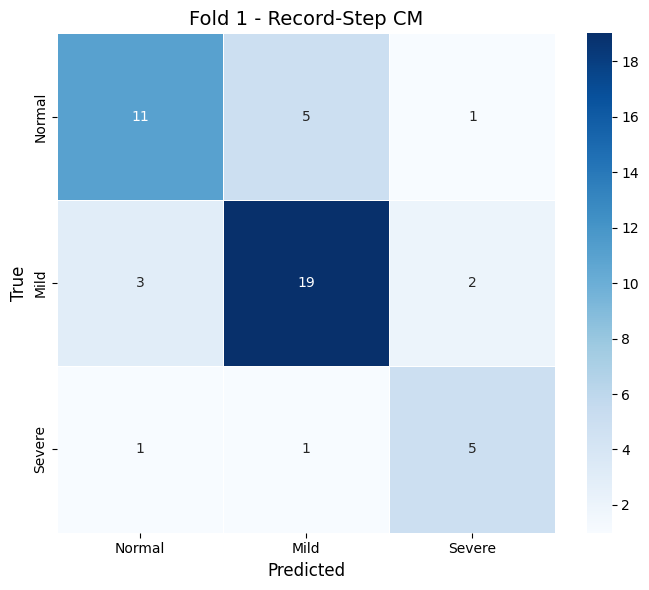


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3958 - loss: 1.4690  val_record_step_balanced_accuracy: 0.5265
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.4380 - loss: 1.4564 - val_accuracy: 0.5513 - val_loss: 1.0228 - val_record_step_balanced_accuracy: 0.5265 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5004 - loss: 1.3563  val_record_step_balanced_accuracy: 0.4914
78/78 ━━

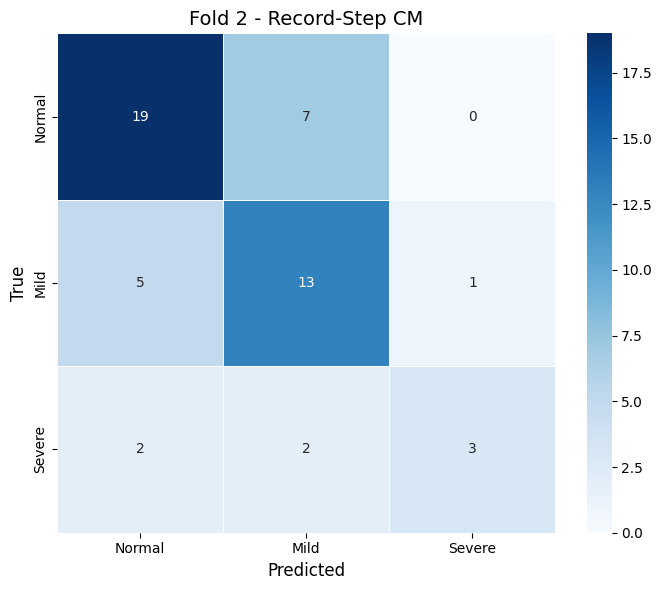


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4058 - loss: 1.4896  val_record_step_balanced_accuracy: 0.3629
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.4434 - loss: 1.4332 - val_accuracy: 0.4286 - val_loss: 1.0731 - val_record_step_balanced_accuracy: 0.3629 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4588 - loss: 1.4304  val_record_step_balanced_accuracy: 0.3805
80/80 ━

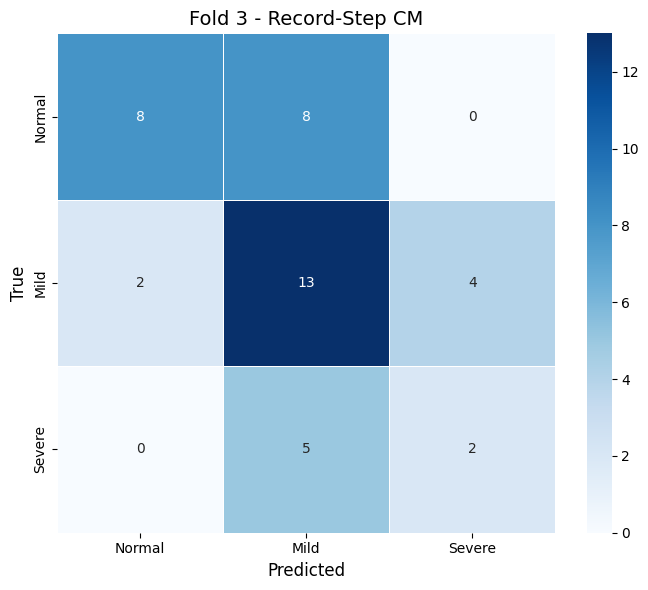


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4127 - loss: 1.4797  val_record_step_balanced_accuracy: 0.5291
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.4442 - loss: 1.4806 - val_accuracy: 0.4444 - val_loss: 1.0768 - val_record_step_balanced_accuracy: 0.5291 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4982 - loss: 1.3562  val_record_step_balanced_accuracy: 0.5964
79/79 ━━

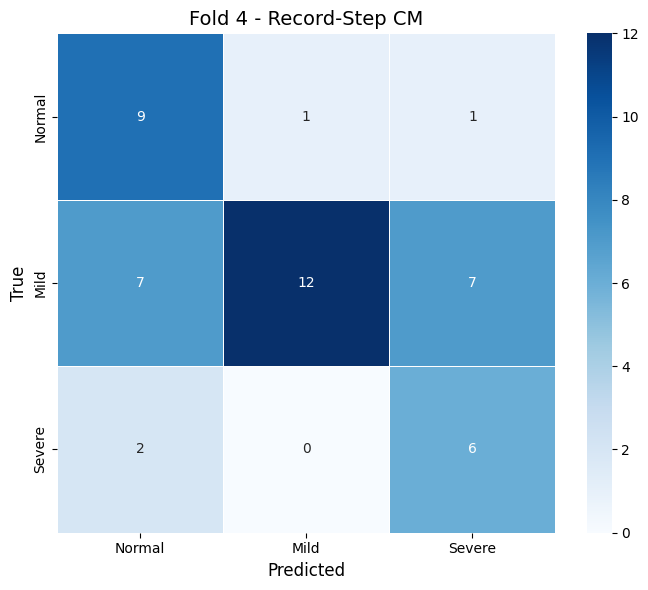


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4053 - loss: 1.5145  val_record_step_balanced_accuracy: 0.5244
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.4403 - loss: 1.4459 - val_accuracy: 0.4683 - val_loss: 1.0128 - val_record_step_balanced_accuracy: 0.5244 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4772 - loss: 1.4300  val_record_step_balanced_accuracy: 0.5819
80/80 ━

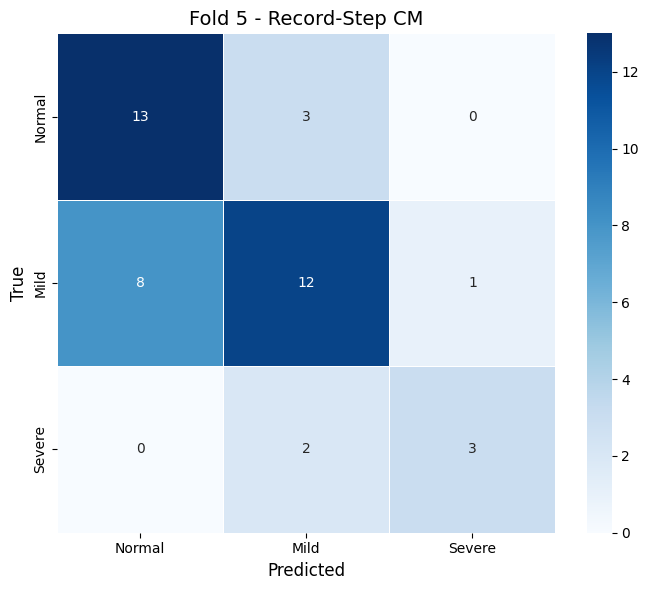


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3820 - loss: 1.5418  val_record_step_balanced_accuracy: 0.3611
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.4167 - loss: 1.4773 - val_accuracy: 0.4800 - val_loss: 1.0387 - val_record_step_balanced_accuracy: 0.3611 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4716 - loss: 1.4104  val_record_step_balanced_accuracy: 0.3917
78/78 ━━

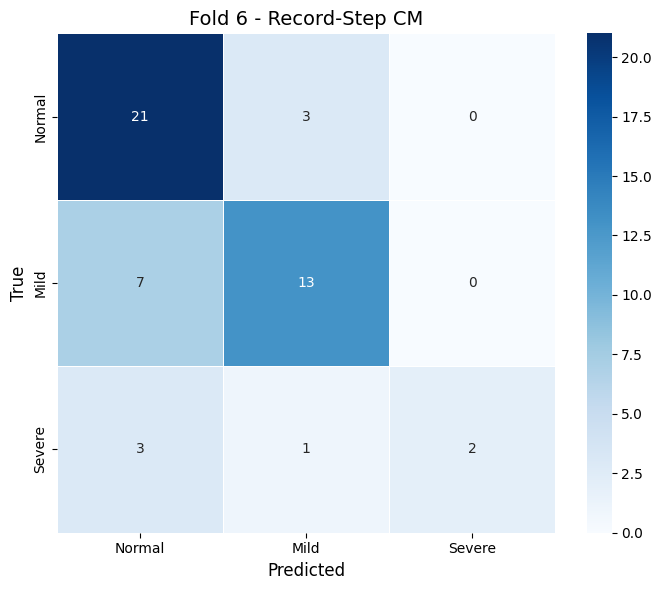


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3431 - loss: 1.6483  val_record_step_balanced_accuracy: 0.4179
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.4016 - loss: 1.5368 - val_accuracy: 0.4638 - val_loss: 1.0327 - val_record_step_balanced_accuracy: 0.4179 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5138 - loss: 1.4013  val_record_step_balanced_accuracy: 0.4402
79/79 ━

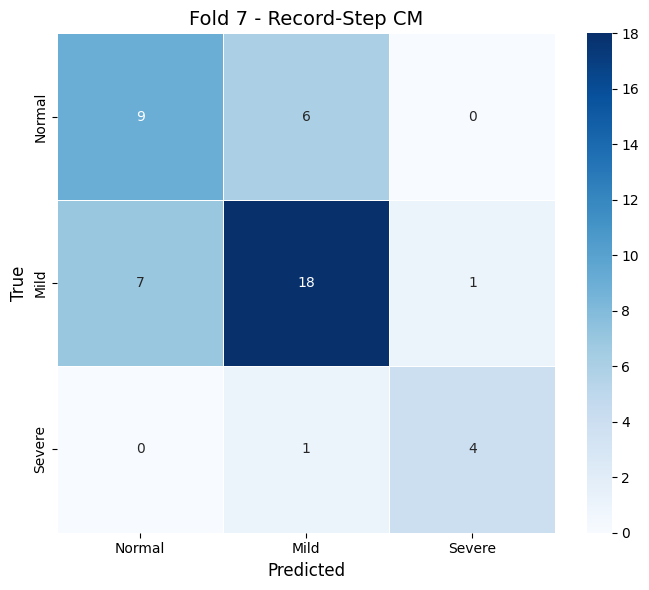


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3600 - loss: 1.5660  val_record_step_balanced_accuracy: 0.4899
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.3791 - loss: 1.4995 - val_accuracy: 0.5227 - val_loss: 1.0291 - val_record_step_balanced_accuracy: 0.4899 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4949 - loss: 1.3488  val_record_step_balanced_accuracy: 0.5057
80/80 ━

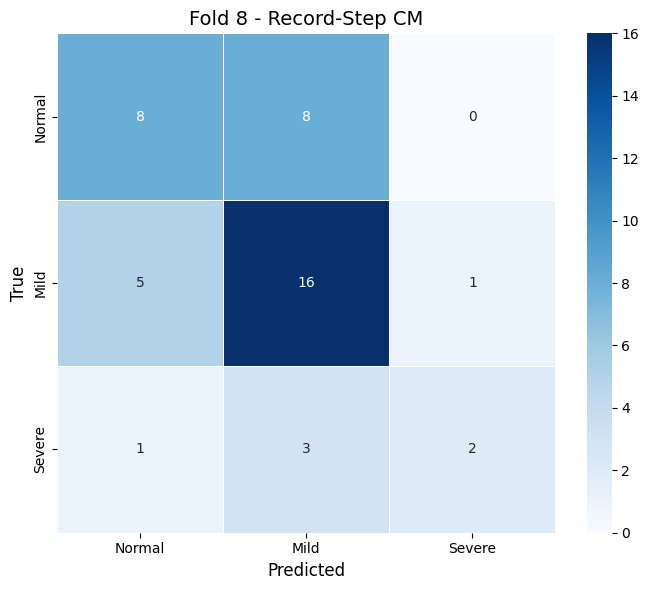


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3757 - loss: 1.5579  val_record_step_balanced_accuracy: 0.3807
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.4145 - loss: 1.5032 - val_accuracy: 0.4183 - val_loss: 1.0963 - val_record_step_balanced_accuracy: 0.3807 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4605 - loss: 1.3989  val_record_step_balanced_accuracy: 0.4757
78/78

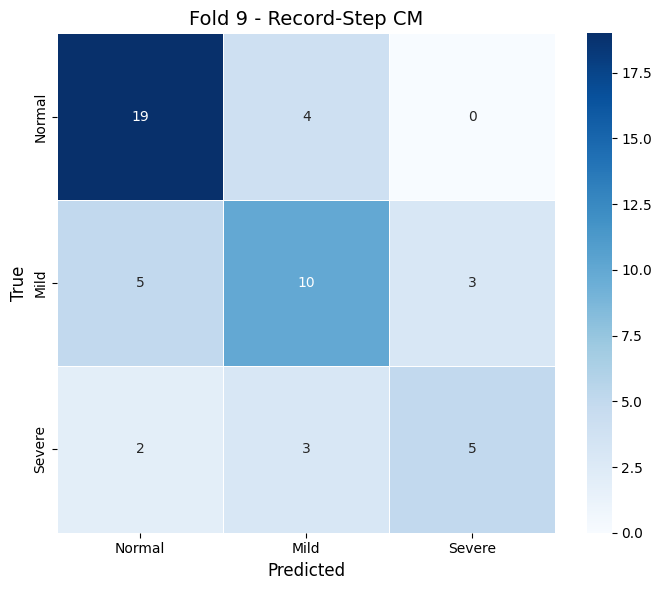


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 1.0, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3707 - loss: 1.5349  val_record_step_balanced_accuracy: 0.4188
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.4183 - loss: 1.4606 - val_accuracy: 0.4348 - val_loss: 0.9967 - val_record_step_balanced_accuracy: 0.4188 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4965 - loss: 1.3773  val_record_step_balanced_accuracy: 0.4989
79/79 

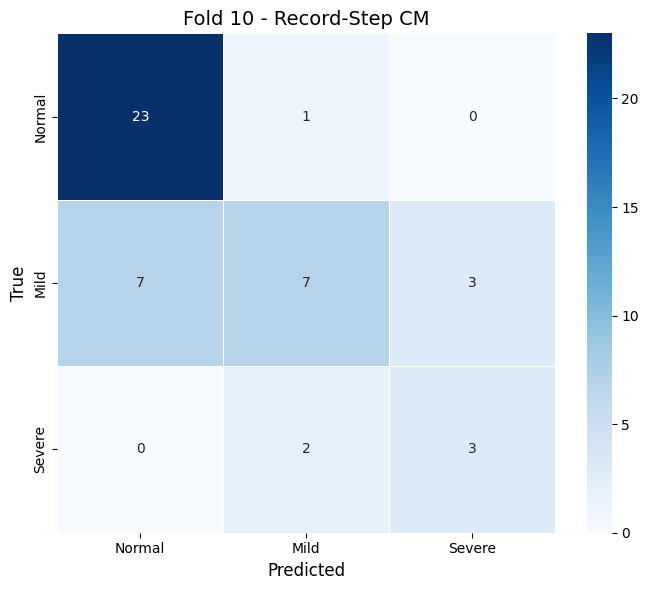


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6585 +/- 0.0575
  balanced_accuracy     : 0.6281 +/- 0.0693
  macro_f1              : 0.6275 +/- 0.0619
  --------------------------------------------------
  precision_Normal  : 0.6692 +/- 0.0951
  recall_Normal  : 0.7268 +/- 0.1505
  f1_Normal  : 0.6862 +/- 0.0935
  precision_Mild    : 0.6845 +/- 0.1147
  recall_Mild    : 0.6230 +/- 0.1141
  f1_Mild    : 0.6386 +/- 0.0713
  precision_Severe  : 0.6479 +/- 0.1839
  recall_Severe  : 0.5345 +/- 0.1769
  f1_Severe  : 0.5577 +/- 0.1271

Overall Confusion Matrix (all folds combined):
[[140  46   2]
 [ 56 133  23]
 [ 11  20  35]]

  All folds are reliable - no filtering needed.


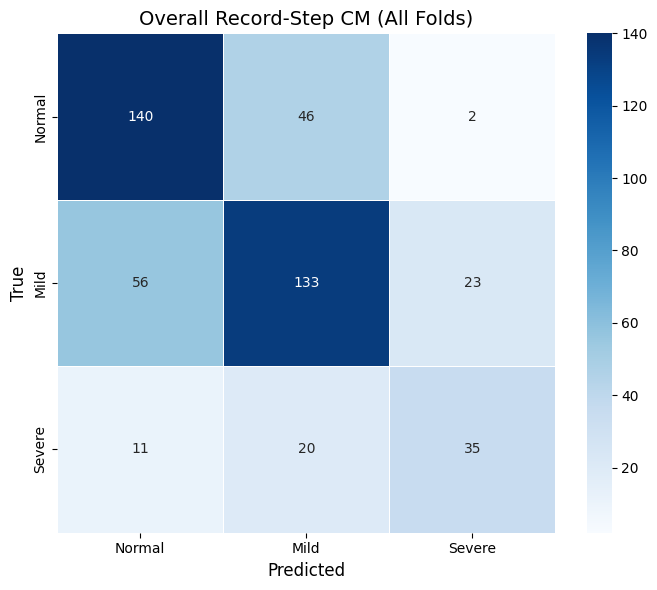

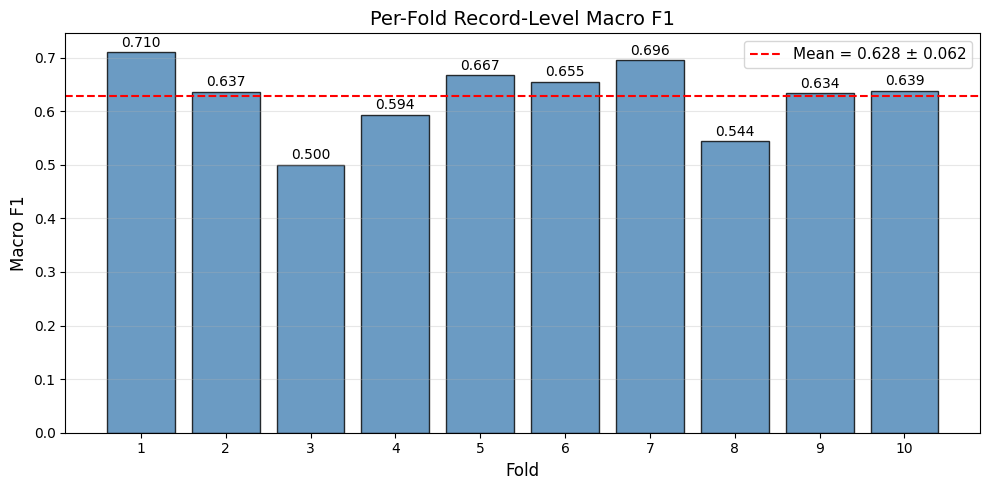


>> Manual (1.0, 1.2, 2.5) — Macro F1: 0.6275 ± 0.0619, Bal Acc: 0.6281


In [ ]:
res_m6, sum_m6 = run_experiment(
    "Manual (1.0, 1.2, 2.5)",
    manual_weights={0: 1.0, 1: 1.2, 2: 2.5},
)

### Experiment 7: Sklearn Balanced Class Weights
Uses `sklearn.utils.class_weight.compute_class_weight('balanced')` to automatically set weights inversely proportional to class frequency in each training fold.


EXPERIMENT: Sklearn Balanced
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 

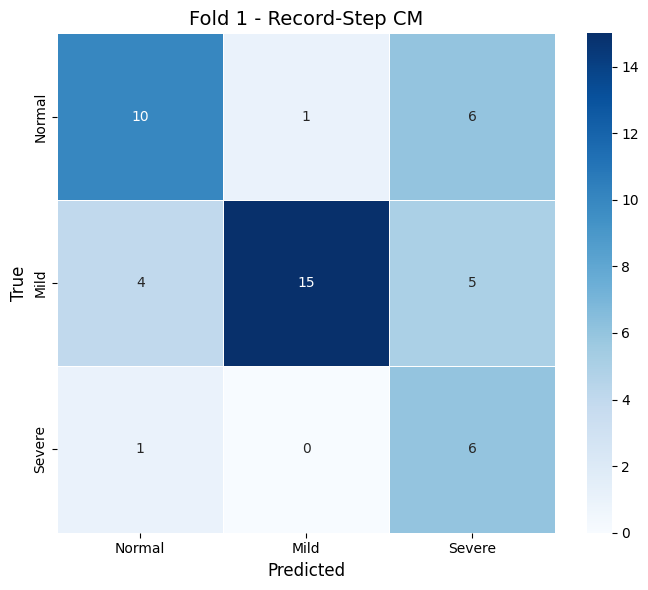


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8518518518518519, 1: 0.7150259067357513, 2: 2.3389830508474576}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3283 - loss: 1.2070  val_record_step_balanced_accuracy: 0.6487
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.3776 - loss: 1.1835 - val_accuracy: 0.5321 - val_loss: 1.0514 - val_record_step_balanced_accuracy: 0.6487 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4467 - loss: 1.0574  val_r

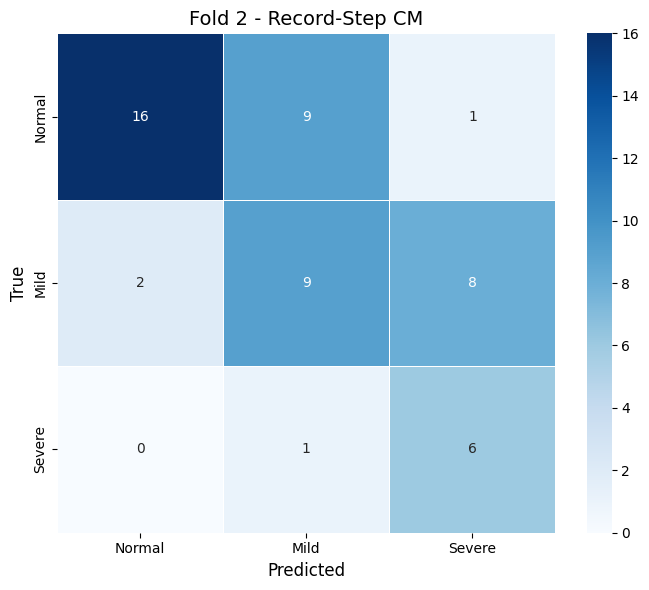


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8217054263565892, 1: 0.7322970639032815, 2: 2.3954802259887007}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3286 - loss: 1.1819  val_record_step_balanced_accuracy: 0.4264
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.3813 - loss: 1.1304 - val_accuracy: 0.3810 - val_loss: 1.0993 - val_record_step_balanced_accuracy: 0.4264 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4449 - loss: 1.0656  val_

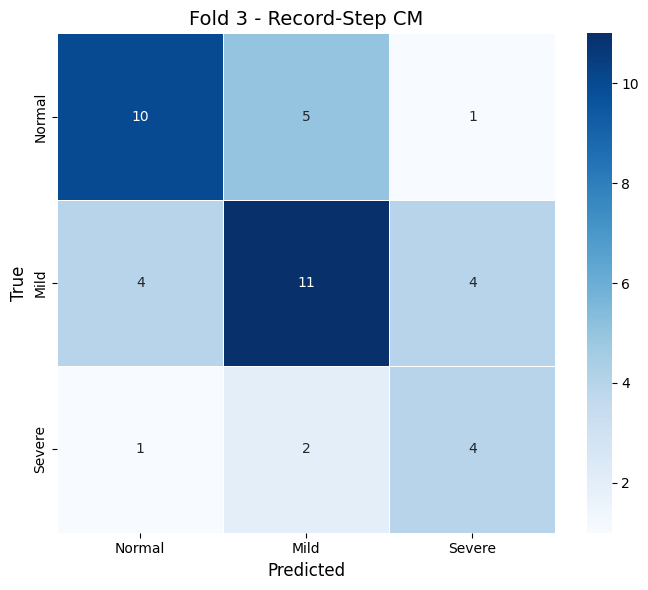


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.7928436911487758, 1: 0.7544802867383512, 2: 2.4195402298850577}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3301 - loss: 1.1100  val_record_step_balanced_accuracy: 0.5134
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.3666 - loss: 1.1125 - val_accuracy: 0.3852 - val_loss: 1.0654 - val_record_step_balanced_accuracy: 0.5134 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4372 - loss: 1.0372  val_

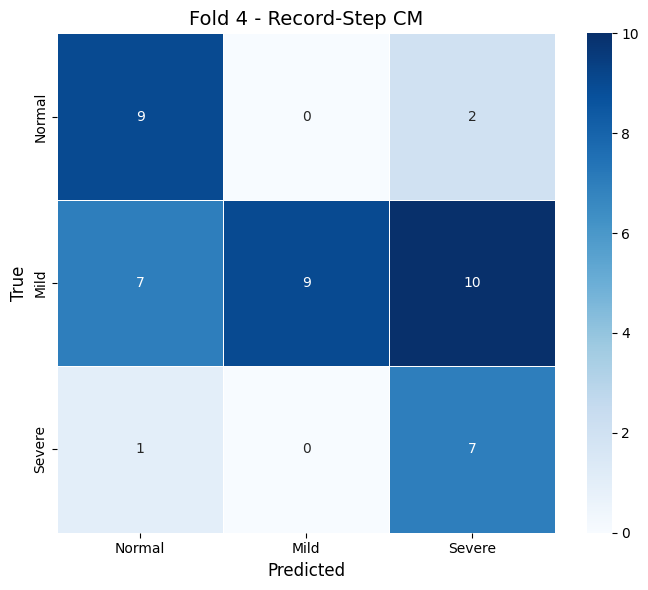


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8217054263565892, 1: 0.7399650959860384, 2: 2.3169398907103824}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3673 - loss: 1.1607  val_record_step_balanced_accuracy: 0.5085
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.3868 - loss: 1.1142 - val_accuracy: 0.4524 - val_loss: 1.0366 - val_record_step_balanced_accuracy: 0.5085 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4198 - loss: 1.0959  val_

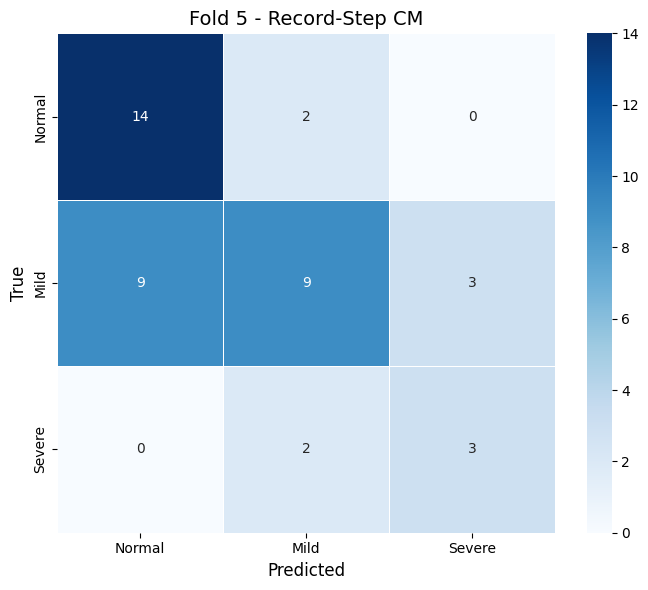


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8455284552845529, 1: 0.7222222222222222, 2: 2.311111111111111}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4058 - loss: 1.1380  val_record_step_balanced_accuracy: 0.5222
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.4439 - loss: 1.1119 - val_accuracy: 0.4333 - val_loss: 1.0610 - val_record_step_balanced_accuracy: 0.5222 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4486 - loss: 1.0718  val_re

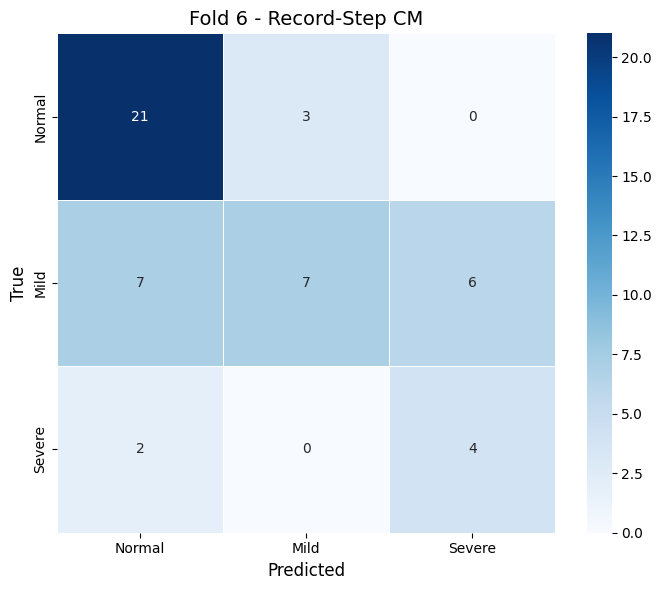


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8092485549132948, 1: 0.7526881720430108, 2: 2.2950819672131146}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3658 - loss: 1.2873  val_record_step_balanced_accuracy: 0.3060
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.3905 - loss: 1.2136 - val_accuracy: 0.3696 - val_loss: 1.1298 - val_record_step_balanced_accuracy: 0.3060 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4340 - loss: 1.1378  val_

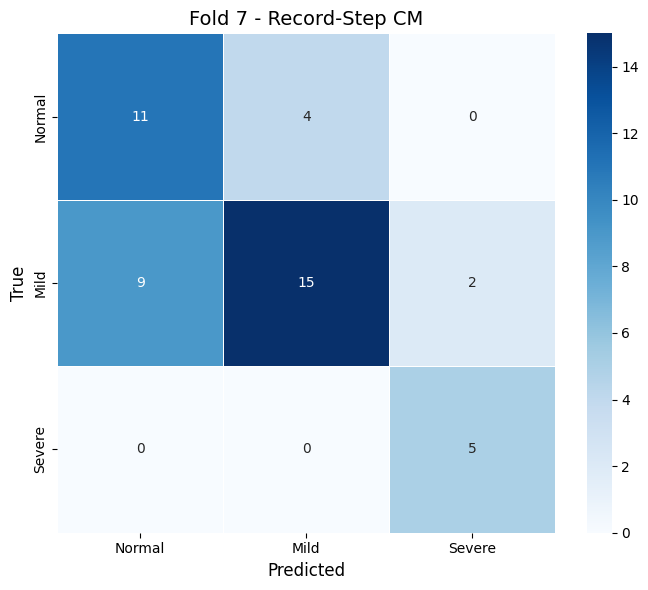


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8178294573643411, 1: 0.7403508771929824, 2: 2.3444444444444446}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4368 - loss: 1.1770  val_record_step_balanced_accuracy: 0.5189
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - accuracy: 0.4321 - loss: 1.1377 - val_accuracy: 0.5000 - val_loss: 1.0640 - val_record_step_balanced_accuracy: 0.5189 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4227 - loss: 1.0847  val_

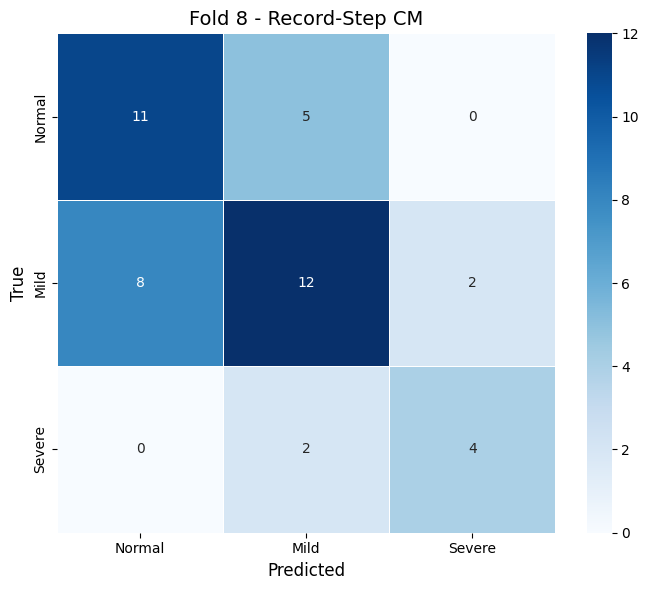


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8383838383838383, 1: 0.7130584192439863, 2: 2.4702380952380953}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3656 - loss: 1.1672  val_record_step_balanced_accuracy: 0.4995
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.4064 - loss: 1.1401 - val_accuracy: 0.4706 - val_loss: 1.0669 - val_record_step_balanced_accuracy: 0.4995 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4144 - loss: 1.1024  val

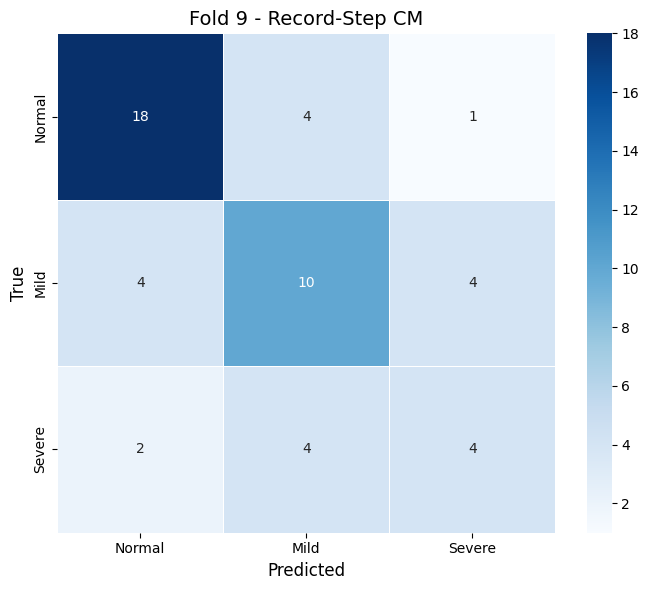


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (from train fold): {0: 0.8536585365853658, 1: 0.717948717948718, 2: 2.2950819672131146}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3584 - loss: 1.2504  val_record_step_balanced_accuracy: 0.5366
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.3833 - loss: 1.1864 - val_accuracy: 0.5797 - val_loss: 1.0007 - val_record_step_balanced_accuracy: 0.5366 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4295 - loss: 1.1089  val_

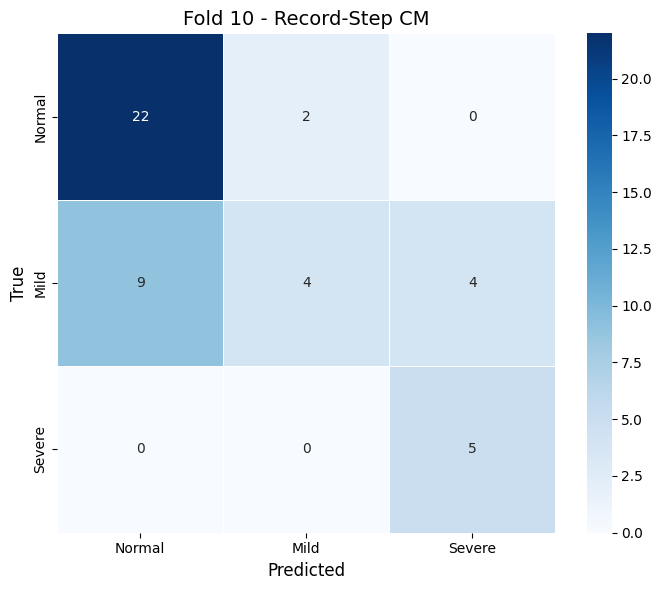


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6241 +/- 0.0349
  balanced_accuracy     : 0.6576 +/- 0.0549
  macro_f1              : 0.6063 +/- 0.0407
  --------------------------------------------------
  precision_Normal  : 0.6649 +/- 0.1014
  recall_Normal  : 0.7517 +/- 0.1135
  f1_Normal  : 0.6959 +/- 0.0659
  precision_Mild    : 0.7058 +/- 0.1549
  recall_Mild    : 0.4716 +/- 0.1212
  f1_Mild    : 0.5484 +/- 0.1059
  precision_Severe  : 0.4847 +/- 0.1181
  recall_Severe  : 0.7494 +/- 0.1882
  f1_Severe  : 0.5745 +/- 0.1183

Overall Confusion Matrix (all folds combined):
[[142  35  11]
 [ 63 101  48]
 [  7  11  48]]

  All folds are reliable - no filtering needed.


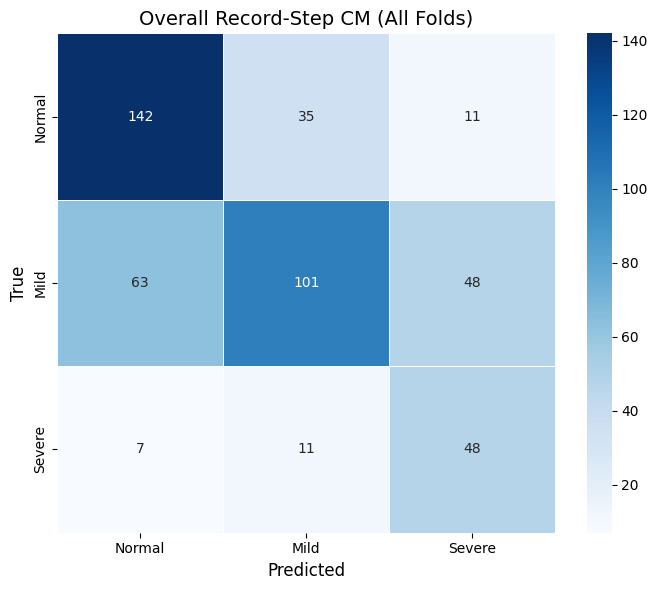

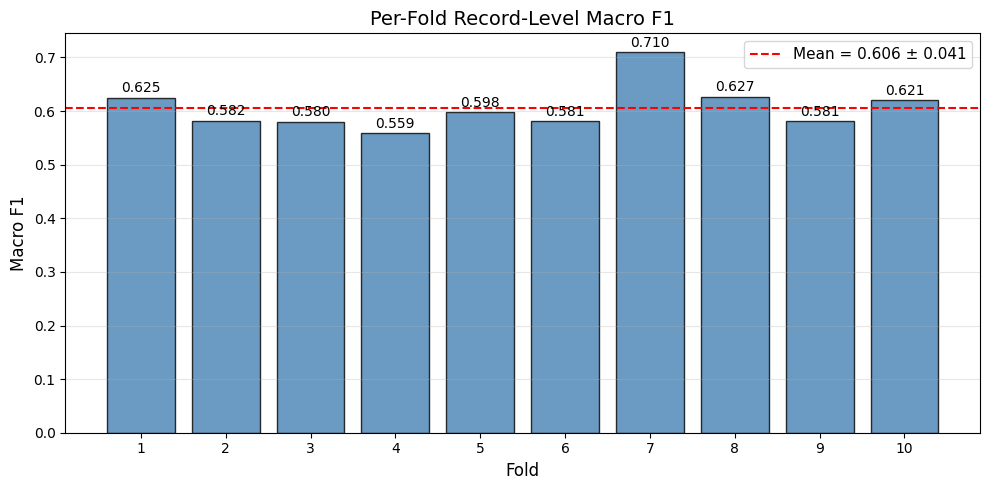


>> Sklearn Balanced — Macro F1: 0.6063 ± 0.0407, Bal Acc: 0.6576


In [ ]:
# Sklearn balanced = pass None so compute_class_weights_from_y uses the original sklearn function
res_sk, sum_sk = run_experiment(
    "Sklearn Balanced",
    manual_weights=None,  # uses original compute_class_weight('balanced')
)

### Experiment 8: SMOTE (Synthetic Minority Oversampling)
Applies SMOTE to generate synthetic training samples for minority classes. Operates on flattened signal windows in the training fold only, keeping validation untouched.

Computing 10 time-domain engineered features
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]

FOLD 1 / 10
  SMOTE: 1254 -> 1692 training windows (k=5)

TRAINING FROM SCRATCH
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4215 - loss: 1.1083  val_record_step_balanced_accuracy: 0.5962
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.4450 - loss: 1.0771 - val_accuracy: 0.4583 - val_loss: 1.0270 - val_record_step_balanced_accuracy: 0.5962 - learning_rate: 0.0010
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5119 - loss: 1.0087  val_record_step_balanced_accuracy: 0.4761
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5041 - loss: 1.0022 - val_accuracy: 0.3611 - val_loss: 1.0920 - val_record_step_balanced_accuracy

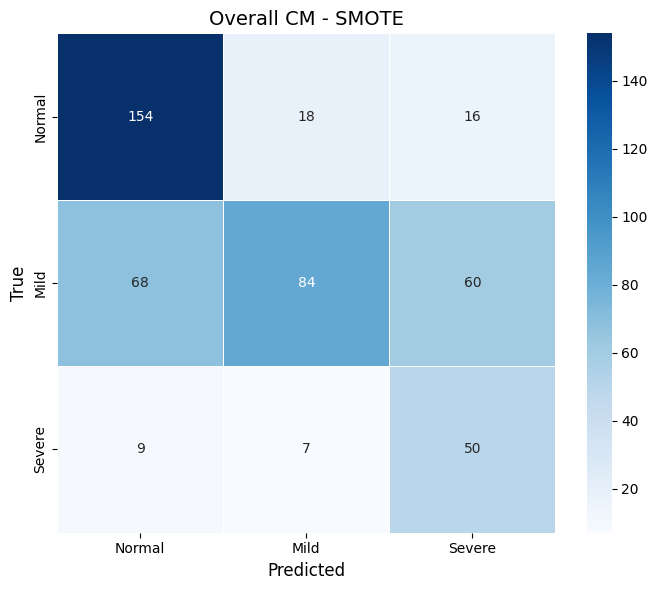

In [ ]:
from imblearn.over_sampling import SMOTE

def run_smote_cv(experiment_name):
    """Run grouped CV with SMOTE applied to training windows per fold."""
    global compute_class_weights_from_y

    cfg_local = dict(CFG)
    cfg_local['use_class_weights'] = False  # SMOTE handles imbalance, no class weights needed

    metadata = _ensure_step_keys(meta_all.reset_index(drop=True))
    use_clinical = cfg_local.get('use_clinical_features', True)

    if use_clinical:
        print("Computing 10 time-domain engineered features")
        clin_all = compute_all_engineered_features(
            X_all, fs=SAMPLING_RATE,
            missing_frac_prefill=_feat_missing,
        )
    else:
        clin_all = None

    folds, effective_min_severe = stratified_record_kfold_with_constraint(
        metadata, n_splits=cfg_local['n_splits'],
        min_severe_records=cfg_local.get('min_severe_records', 10),
        max_attempts=cfg_local.get('max_cv_attempts', 100),
        cv_seed=cfg_local['cv_seed'],
    )

    fold_results = []
    all_step_y_true, all_step_y_pred = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}\nFOLD {fold_idx + 1} / {cfg_local['n_splits']}\n{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata, val_idx, min_severe_records=effective_min_severe,
        )

        X_train, X_val = X_all[train_idx], X_all[val_idx]
        y_train, y_val = y_all[train_idx], y_all[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        # Apply SMOTE on flattened signal windows
        n_samples, seq_len, n_ch = X_train.shape
        X_flat = X_train.reshape(n_samples, -1)

        # Determine k_neighbors safely: must be < smallest class count
        min_class_count = min(np.bincount(y_train.astype(int)))
        k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1

        smote = SMOTE(random_state=GLOBAL_SEED, k_neighbors=k_neighbors)
        X_resampled, y_resampled = smote.fit_resample(X_flat, y_train)
        X_train = X_resampled.reshape(-1, seq_len, n_ch)
        y_train = y_resampled

        # If clinical features exist, resample them with the same SMOTE mapping
        if clin_train is not None:
            clin_resampled, _ = smote.fit_resample(clin_train, y_all[train_idx])
            clin_train = clin_resampled

        print(f"  SMOTE: {n_samples} -> {len(X_train)} training windows (k={k_neighbors})")

        # Normalize using original train stats
        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n, clin_val_n = None, None

        tf.keras.backend.clear_session()
        n_clinical = clin_all.shape[1] if clin_all is not None else 0
        model = build_model(
            input_length=cfg_local['segment_length'], num_classes=NUM_CLASSES,
            temporal_filters=cfg_local['temporal_filters'],
            temporal_kernel=cfg_local['temporal_kernel'],
            separable_filters=cfg_local['separable_filters'],
            separable_kernels=cfg_local['separable_kernels'],
            projection_filters=cfg_local['projection_filters'],
            dropout_rate=cfg_local['dropout_rate'],
            n_clinical_features=n_clinical,
        )

        # Temporarily disable class weights for SMOTE
        compute_class_weights_from_y = lambda y: {i: 1.0 for i in range(NUM_CLASSES)}

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_smote_best.weights.h5")
        _ = train_from_scratch(
            model, X_train_n, y_train, X_val_n, y_val, meta_val, cfg_local,
            save_path=save_path, clin_train=clin_train_n, clin_val=clin_val_n,
        )
        compute_class_weights_from_y = _original_compute_class_weights_from_y

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['is_reliable'] = is_reliable
        fold_results.append(metrics)
        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")

    compute_class_weights_from_y = _original_compute_class_weights_from_y

    summary = {
        'experiment': experiment_name,
        'manual_class_weights': 'SMOTE (no class weights)',
        'mean_macro_f1': float(np.mean([r['macro_f1'] for r in fold_results])),
        'std_macro_f1': float(np.std([r['macro_f1'] for r in fold_results])),
        'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in fold_results])),
        'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in fold_results])),
        'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in fold_results])),
        'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in fold_results])),
        'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in fold_results])),
    }
    all_experiment_results[experiment_name] = summary

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\n>> {experiment_name} — Macro F1: {summary['mean_macro_f1']:.4f} ± {summary['std_macro_f1']:.4f}")
    plot_confusion_matrix(overall_cm, title=f"Overall CM - {experiment_name}",
                          save_path=str(OUTPUT_DIR / "overall_cm_smote.png"))
    return fold_results, summary

res_smote, sum_smote = run_smote_cv("SMOTE")

### Experiment 10: Focal Loss (γ=2.0)
Focal Loss down-weights easy examples and focuses training on hard-to-classify minority samples, providing an alternative to explicit class weighting.

  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]

FOLD 1 / 10
Epoch 1/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4383 - loss: 0.5893  val_record_step_balanced_accuracy: 0.4882
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.4434 - loss: 0.5506 - val_accuracy: 0.5417 - val_loss: 0.4022 - val_record_step_balanced_accuracy: 0.4882 - learning_rate: 0.0010
Epoch 2/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5211 - loss: 0.4497  val_record_step_balanced_accuracy: 0.4686
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.5040 - loss: 0.4648 - val_accuracy: 0.5278 - val_loss: 0.3838 - val_record_step_balanced_accuracy: 0.4686 - learning_rate: 0.0010
Epoch 3/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5228 - loss: 0.4226  val_record_step_balanced_accuracy: 0.5274
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - 

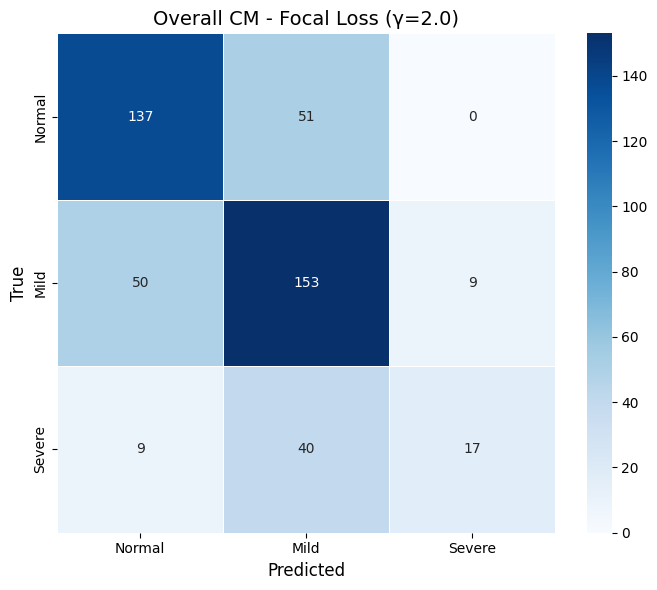

In [ ]:
def focal_loss(gamma=2.0, alpha=None):
    """Focal loss for multi-class classification. Reduces loss for well-classified examples."""
    def _focal_loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = y_true * tf.pow(1.0 - y_pred, gamma)
        focal = weight * cross_entropy
        if alpha is not None:
            focal = focal * alpha
        return tf.reduce_sum(focal, axis=-1)
    return _focal_loss_fn


def run_focal_loss_cv(experiment_name, gamma=2.0):
    """Run grouped CV with Focal Loss instead of CrossEntropy."""
    global compute_class_weights_from_y

    cfg_local = dict(CFG)
    cfg_local['use_class_weights'] = False  # Focal loss handles imbalance

    metadata = _ensure_step_keys(meta_all.reset_index(drop=True))
    use_clinical = cfg_local.get('use_clinical_features', True)

    if use_clinical:
        clin_all = compute_all_engineered_features(
            X_all, fs=SAMPLING_RATE,
            missing_frac_prefill=_feat_missing,
        )
    else:
        clin_all = None

    folds, effective_min_severe = stratified_record_kfold_with_constraint(
        metadata, n_splits=cfg_local['n_splits'],
        min_severe_records=cfg_local.get('min_severe_records', 10),
        max_attempts=cfg_local.get('max_cv_attempts', 100),
        cv_seed=cfg_local['cv_seed'],
    )

    fold_results = []
    all_step_y_true, all_step_y_pred = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}\nFOLD {fold_idx + 1} / {cfg_local['n_splits']}\n{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata, val_idx, min_severe_records=effective_min_severe,
        )

        X_train, X_val = X_all[train_idx], X_all[val_idx]
        y_train, y_val = y_all[train_idx], y_all[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n, clin_val_n = None, None

        tf.keras.backend.clear_session()
        n_clinical = clin_all.shape[1] if clin_all is not None else 0
        model = build_model(
            input_length=cfg_local['segment_length'], num_classes=NUM_CLASSES,
            temporal_filters=cfg_local['temporal_filters'],
            temporal_kernel=cfg_local['temporal_kernel'],
            separable_filters=cfg_local['separable_filters'],
            separable_kernels=cfg_local['separable_kernels'],
            projection_filters=cfg_local['projection_filters'],
            dropout_rate=cfg_local['dropout_rate'],
            n_clinical_features=n_clinical,
        )

        # Compile with Focal Loss instead of CrossEntropy
        model.compile(
            optimizer=Adam(learning_rate=cfg_local['scratch_lr']),
            loss=focal_loss(gamma=gamma),
            metrics=['accuracy'],
        )

        y_train_cat = to_categorical(y_train, NUM_CLASSES)
        y_val_cat = to_categorical(y_val, NUM_CLASSES)

        X_train_use = X_train_n.copy()
        if cfg_local.get('augment_train', False):
            X_train_use = augment_signal(X_train_use, cfg_local)

        monitor_callback = RecordStepBalancedAccuracy(
            X_val=X_val_n, val_metadata=meta_val,
            clin_val=clin_val_n, batch_size=32,
        )

        history = model.fit(
            _make_model_input(X_train_use, clin_train_n), y_train_cat,
            validation_data=(_make_model_input(X_val_n, clin_val_n), y_val_cat),
            epochs=cfg_local['scratch_epochs'],
            batch_size=cfg_local['scratch_batch'],
            callbacks=get_callbacks(
                patience=cfg_local['scratch_patience'],
                monitor='val_record_step_balanced_accuracy',
                monitor_mode='max',
                save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_focal_best.weights.h5"),
                prefix_callbacks=[monitor_callback],
                save_weights_only=True,
            ),
            verbose=1,
        )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['is_reliable'] = is_reliable
        fold_results.append(metrics)
        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")

    summary = {
        'experiment': experiment_name,
        'manual_class_weights': f'Focal Loss (gamma={gamma})',
        'mean_macro_f1': float(np.mean([r['macro_f1'] for r in fold_results])),
        'std_macro_f1': float(np.std([r['macro_f1'] for r in fold_results])),
        'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in fold_results])),
        'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in fold_results])),
        'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in fold_results])),
        'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in fold_results])),
        'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in fold_results])),
    }
    all_experiment_results[experiment_name] = summary

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\n>> {experiment_name} — Macro F1: {summary['mean_macro_f1']:.4f} ± {summary['std_macro_f1']:.4f}")
    plot_confusion_matrix(overall_cm, title=f"Overall CM - {experiment_name}",
                          save_path=str(OUTPUT_DIR / "overall_cm_focal.png"))
    return fold_results, summary

res_focal, sum_focal = run_focal_loss_cv("Focal Loss (γ=2.0)", gamma=2.0)

## 13. Comparison of All Class-Imbalance Strategies
Side-by-side comparison table and bar chart of all experiments.

CLASS IMBALANCE STRATEGY COMPARISON
              Strategy        Macro F1    Balanced Acc Recall Normal Recall Mild Recall Severe
Manual (0.9, 1.2, 2.5) 0.6352 ± 0.0649 0.6409 ± 0.0745        0.6346      0.6850        0.6030
Manual (0.9, 1.3, 2.3) 0.6341 ± 0.0892 0.6282 ± 0.0975        0.6366      0.7277        0.5202
Manual (0.9, 1.2, 2.3) 0.6293 ± 0.0704 0.6416 ± 0.0922        0.6739      0.7117        0.5392
Manual (1.0, 1.2, 2.5) 0.6275 ± 0.0619 0.6281 ± 0.0693        0.7268      0.6230        0.5345
Manual (0.9, 1.3, 2.5) 0.6259 ± 0.0958 0.6318 ± 0.0793        0.6320      0.7170        0.5464
Manual (0.9, 1.1, 2.3) 0.6136 ± 0.0551 0.6309 ± 0.0687        0.7171      0.5916        0.5840
Manual (1.0, 1.2, 2.3) 0.6101 ± 0.0647 0.6136 ± 0.0690        0.6858      0.6312        0.5239
      Sklearn Balanced 0.6063 ± 0.0407 0.6576 ± 0.0549        0.7517      0.4716        0.7494
                 SMOTE 0.5862 ± 0.0682 0.6630 ± 0.0756        0.8090      0.3902        0.7899
    Focal Loss

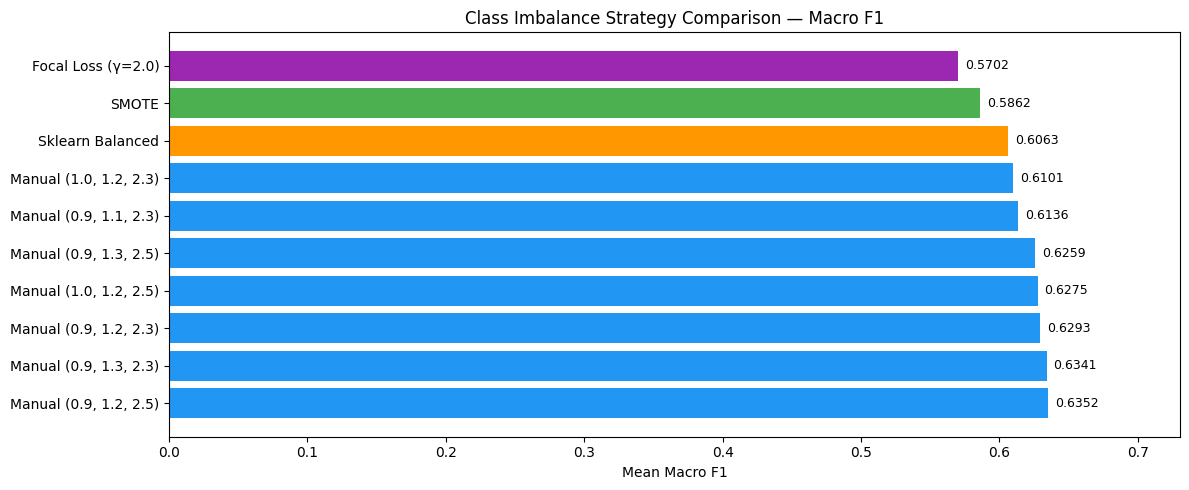

Done.


In [ ]:
# Build comparison DataFrame from all experiments
comparison_rows = []
for name, s in all_experiment_results.items():
    comparison_rows.append({
        'Strategy': name,
        'Macro F1': f"{s['mean_macro_f1']:.4f} ± {s['std_macro_f1']:.4f}",
        'Balanced Acc': f"{s['mean_balanced_acc']:.4f} ± {s['std_balanced_acc']:.4f}",
        'Recall Normal': f"{s['mean_recall_Normal']:.4f}",
        'Recall Mild': f"{s['mean_recall_Mild']:.4f}",
        'Recall Severe': f"{s['mean_recall_Severe']:.4f}",
        '_macro_f1': s['mean_macro_f1'],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('_macro_f1', ascending=False)
comparison_df_display = comparison_df.drop(columns=['_macro_f1'])
print("=" * 90)
print("CLASS IMBALANCE STRATEGY COMPARISON")
print("=" * 90)
print(comparison_df_display.to_string(index=False))

# Save to CSV
comparison_df_display.to_csv(OUTPUT_DIR / "class_imbalance_comparison.csv", index=False)
print(f"\nComparison saved to {OUTPUT_DIR / 'class_imbalance_comparison.csv'}")

# Bar chart of Macro F1
fig, ax = plt.subplots(figsize=(12, 5))
strategies = comparison_df['Strategy'].tolist()
f1_values = comparison_df['_macro_f1'].tolist()
colors = ['#2196F3' if 'Manual' in s else '#FF9800' if s == 'Sklearn Balanced' else
          '#4CAF50' if 'SMOTE' in s else '#9C27B0' for s in strategies]
bars = ax.barh(strategies, f1_values, color=colors)
ax.set_xlabel('Mean Macro F1')
ax.set_title('Class Imbalance Strategy Comparison — Macro F1')
ax.set_xlim(0, max(f1_values) * 1.15 if f1_values else 1.0)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_imbalance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done.")

In [ ]:
# Save full results JSON
with open(OUTPUT_DIR / "all_class_imbalance_results.json", 'w') as f:
    json.dump(all_experiment_results, f, indent=2, default=str)
print(f"Full results saved to {OUTPUT_DIR / 'all_class_imbalance_results.json'}")

# Identify best strategy
best = max(all_experiment_results.items(), key=lambda x: x[1]['mean_macro_f1'])
print(f"\nBest strategy: {best[0]}")
print(f"  Macro F1: {best[1]['mean_macro_f1']:.4f} ± {best[1]['std_macro_f1']:.4f}")
print(f"  Balanced Acc: {best[1]['mean_balanced_acc']:.4f} ± {best[1]['std_balanced_acc']:.4f}")
print(f"  Recall: Normal: {best[1]['mean_recall_Normal']:.4f}, "
      f"Mild: {best[1]['mean_recall_Mild']:.4f}, "
      f"Severe: {best[1]['mean_recall_Severe']:.4f}")

Full results saved to outputs/step23_softmax_short_plan/all_class_imbalance_results.json

Best strategy: Manual (0.9, 1.2, 2.5)
  Macro F1: 0.6352 ± 0.0649
  Balanced Acc: 0.6409 ± 0.0745
  Recall: Normal: 0.6346, Mild: 0.6850, Severe: 0.6030
